In [ ]:
# =========================
# STEP 1 — Environment & Path Verification
# =========================
import os
import sys
import zipfile
from pathlib import Path
from datetime import datetime

# ---- Fixed paths (as you specified) ----
KAGGLE_ZIP = "/content/drive/MyDrive/project dataset/kaggle MRI.zip"
BRISC_ROOT = "/content/drive/MyDrive/project dataset/brisc_2025"
SAVE_ROOT  = "/content/drive/MyDrive/project dataset/outputs_fssr/"

print("=== Runtime Info ===")
print("Python:", sys.version.split()[0])
print("Now:", datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
print()

# ---- Mount drive (Colab-safe) ----
try:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    print("Drive mounted: /content/drive")
except Exception as e:
    print("NOTE: Not running in Colab or drive mount failed.")
    print("Error:", repr(e))
print()

def exists_info(p):
    p = Path(p)
    return {
        "path": str(p),
        "exists": p.exists(),
        "is_file": p.is_file(),
        "is_dir": p.is_dir(),
        "size_bytes": p.stat().st_size if p.exists() and p.is_file() else None,
    }

print("=== Path Checks ===")
for info in [exists_info(KAGGLE_ZIP), exists_info(BRISC_ROOT), exists_info(SAVE_ROOT)]:
    print(info)
print()

# ---- Ensure SAVE_ROOT exists ----
print("=== Create/Verify SAVE_ROOT ===")
os.makedirs(SAVE_ROOT, exist_ok=True)
print("SAVE_ROOT exists now:", Path(SAVE_ROOT).exists(), "| is_dir:", Path(SAVE_ROOT).is_dir())

# write test
test_file = Path(SAVE_ROOT) / "_write_test.txt"
with open(test_file, "w") as f:
    f.write("ok")
print("Writable check:", test_file.exists(), "| wrote:", test_file)
test_file.unlink(missing_ok=True)
print()

# ---- Quick peek into Kaggle zip ----
print("=== Kaggle ZIP Preview ===")
if Path(KAGGLE_ZIP).exists():
    try:
        with zipfile.ZipFile(KAGGLE_ZIP, "r") as z:
            names = z.namelist()
            print("ZIP entries:", len(names))
            print("First 20 entries:")
            for n in names[:20]:
                print("  -", n)
    except Exception as e:
        print("FAILED to read zip:", repr(e))
else:
    print("KAGGLE_ZIP does not exist at:", KAGGLE_ZIP)
print()

# ---- Quick peek into BRISC root ----
print("=== BRISC Root Preview ===")
br = Path(BRISC_ROOT)
if br.exists() and br.is_dir():
    top = sorted([p.name for p in br.iterdir()])[:40]
    print("Top-level items (up to 40):")
    for t in top:
        print("  -", t)
else:
    print("BRISC_ROOT does not exist or is not a directory:", BRISC_ROOT)
print()

print("STEP 1 DONE.")


=== Runtime Info ===
Python: 3.12.12
Now: 2026-03-21 23:08:02

Mounted at /content/drive
Drive mounted: /content/drive

=== Path Checks ===
{'path': '/content/drive/MyDrive/project dataset/kaggle MRI.zip', 'exists': True, 'is_file': True, 'is_dir': False, 'size_bytes': 155791278}
{'path': '/content/drive/MyDrive/project dataset/brisc_2025', 'exists': True, 'is_file': False, 'is_dir': True, 'size_bytes': None}
{'path': '/content/drive/MyDrive/project dataset/outputs_fssr', 'exists': True, 'is_file': False, 'is_dir': True, 'size_bytes': None}

=== Create/Verify SAVE_ROOT ===
SAVE_ROOT exists now: True | is_dir: True
Writable check: True | wrote: /content/drive/MyDrive/project dataset/outputs_fssr/_write_test.txt

=== Kaggle ZIP Preview ===
ZIP entries: 7023
First 20 entries:
  - Testing/glioma/Te-glTr_0000.jpg
  - Testing/glioma/Te-glTr_0001.jpg
  - Testing/glioma/Te-glTr_0002.jpg
  - Testing/glioma/Te-glTr_0003.jpg
  - Testing/glioma/Te-glTr_0004.jpg
  - Testing/glioma/Te-glTr_0005.jpg


In [ ]:
# =========================
# STEP 2 — Kaggle MRI Dataset Audit (ZIP ONLY)
# =========================
import zipfile
from collections import defaultdict, Counter
from pathlib import Path

KAGGLE_ZIP = "/content/drive/MyDrive/project dataset/kaggle MRI.zip"
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}

# Containers
top_level = Counter()
splits = defaultdict(set)
class_counts = defaultdict(Counter)
ext_counts = Counter()

with zipfile.ZipFile(KAGGLE_ZIP, "r") as z:
    names = [n for n in z.namelist() if not n.endswith("/")]

    for n in names:
        parts = Path(n).parts
        if len(parts) < 2:
            continue

        # Track top-level dirs
        top_level[parts[0]] += 1

        # Infer split / class if possible
        if len(parts) >= 3:
            split, cls = parts[0], parts[1]
            ext = Path(n).suffix.lower()

            if ext in IMAGE_EXTS:
                splits[split].add(cls)
                class_counts[split][cls] += 1
                ext_counts[ext] += 1

print("=== Top-level folders in ZIP ===")
for k, v in top_level.items():
    print(f"{k:15s} : {v} files")

print("\n=== Detected splits and classes ===")
for split, classes in splits.items():
    print(f"\n[{split}]")
    for c in sorted(classes):
        print(f"  - {c:15s} : {class_counts[split][c]} images")

print("\n=== File extension distribution ===")
for ext, cnt in ext_counts.items():
    print(f"{ext:6s} : {cnt}")

total_imgs = sum(ext_counts.values())
print("\nTotal detected images:", total_imgs)
print("\nSTEP 2 DONE.")


=== Top-level folders in ZIP ===
Testing         : 1311 files
Training        : 5712 files

=== Detected splits and classes ===

[Testing]
  - glioma          : 300 images
  - meningioma      : 306 images
  - notumor         : 405 images
  - pituitary       : 300 images

[Training]
  - glioma          : 1321 images
  - meningioma      : 1339 images
  - notumor         : 1595 images
  - pituitary       : 1457 images

=== File extension distribution ===
.jpg   : 7023

Total detected images: 7023

STEP 2 DONE.


In [ ]:
# =========================
# STEP 2B — Extract Kaggle MRI ZIP to Local Colab
# =========================
import zipfile
from pathlib import Path

# -------------------------
# PATHS (LOCKED)
# -------------------------
KAGGLE_ZIP = Path("/content/drive/MyDrive/project dataset/kaggle MRI.zip")
LOCAL_ROOT = Path("/content/kaggle_mri_local")

assert KAGGLE_ZIP.exists(), f"ZIP not found: {KAGGLE_ZIP}"

# -------------------------
# Create local root
# -------------------------
LOCAL_ROOT.mkdir(parents=True, exist_ok=True)

print("Extracting ZIP...")
print("From :", KAGGLE_ZIP)
print("To   :", LOCAL_ROOT)

# -------------------------
# Extract
# -------------------------
with zipfile.ZipFile(KAGGLE_ZIP, "r") as z:
    z.extractall(LOCAL_ROOT)

print("\nExtraction complete.")

# -------------------------
# Quick sanity check
# -------------------------
top_dirs = sorted([p.name for p in LOCAL_ROOT.iterdir() if p.is_dir()])

print("\n=== Local root contents ===")
for d in top_dirs:
    print(" -", d)

print("\n=== STEP 2B DONE ===")


Extracting ZIP...
From : /content/drive/MyDrive/project dataset/kaggle MRI.zip
To   : /content/kaggle_mri_local

Extraction complete.

=== Local root contents ===
 - Testing
 - Training

=== STEP 2B DONE ===


In [ ]:
# =========================
# BRISC-2025 CLASSIFICATION DATASET SCANNER (BULLETPROOF)
# =========================

from pathlib import Path
from collections import Counter, defaultdict

# ✅ CORRECT ROOT (verified by search)
BRISC_ROOT = Path(
    "/content/drive/MyDrive/project dataset/BRISC_2025_extracted/brisc2025/classification_task"
)

SPLIT = "test"   # change to "train" or "val" if needed

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}

split_dir = BRISC_ROOT / SPLIT
assert split_dir.exists(), f"❌ Split directory not found: {split_dir}"

print(f"\n=== BRISC SCAN STARTED | split = '{SPLIT}' ===")
print("Root:", BRISC_ROOT)

# -------------------------------------------------
# Step 1 — Discover class folders (GROUND TRUTH)
# -------------------------------------------------
class_dirs = sorted([d for d in split_dir.iterdir() if d.is_dir()])

print("\nDetected class folders:")
for d in class_dirs:
    print(" -", d.name)

# -------------------------------------------------
# Step 2 — Scan images recursively per class
# -------------------------------------------------
class_image_counts = Counter()
class_ext_counts = defaultdict(Counter)
class_examples = defaultdict(list)

TOTAL_IMAGES = 0

for cls_dir in class_dirs:
    cls_name = cls_dir.name

    for p in cls_dir.rglob("*"):
        if not p.is_file():
            continue

        ext = p.suffix.lower()
        if ext in IMAGE_EXTS:
            class_image_counts[cls_name] += 1
            class_ext_counts[cls_name][ext] += 1
            TOTAL_IMAGES += 1

            if len(class_examples[cls_name]) < 3:
                class_examples[cls_name].append(p)

# -------------------------------------------------
# Step 3 — Report results
# -------------------------------------------------
print("\n=== Image counts per class ===")
for cls in sorted(class_image_counts):
    print(f"{cls:12s}: {class_image_counts[cls]}")

print("\n=== Extension distribution per class ===")
for cls in sorted(class_ext_counts):
    print(f"\n[{cls}]")
    for ext, cnt in class_ext_counts[cls].items():
        print(f"  {ext:6s}: {cnt}")

print("\n=== Sample image paths (sanity check) ===")
for cls in class_examples:
    print(f"\n[{cls}]")
    for p in class_examples[cls]:
        print(" ", p)

# -------------------------------------------------
# Step 4 — Hard validation checks
# -------------------------------------------------
print("\n=== VALIDATION CHECKS ===")
for d in class_dirs:
    if class_image_counts[d.name] == 0:
        print(f"⚠️  WARNING: class '{d.name}' contains ZERO images!")

print("\nTOTAL images detected:", TOTAL_IMAGES)
print("=== BRISC SCAN COMPLETE ===")



=== BRISC SCAN STARTED | split = 'test' ===
Root: /content/drive/MyDrive/project dataset/BRISC_2025_extracted/brisc2025/classification_task

Detected class folders:
 - glioma
 - meningioma
 - no_tumor
 - pituitary

=== Image counts per class ===
glioma      : 254
meningioma  : 306
no_tumor    : 140
pituitary   : 300

=== Extension distribution per class ===

[glioma]
  .jpg  : 254

[meningioma]
  .jpg  : 306

[no_tumor]
  .jpg  : 140

[pituitary]
  .jpg  : 300

=== Sample image paths (sanity check) ===

[glioma]
  /content/drive/MyDrive/project dataset/BRISC_2025_extracted/brisc2025/classification_task/test/glioma/brisc2025_test_00001_gl_ax_t1.jpg
  /content/drive/MyDrive/project dataset/BRISC_2025_extracted/brisc2025/classification_task/test/glioma/brisc2025_test_00002_gl_ax_t1.jpg
  /content/drive/MyDrive/project dataset/BRISC_2025_extracted/brisc2025/classification_task/test/glioma/brisc2025_test_00003_gl_ax_t1.jpg

[meningioma]
  /content/drive/MyDrive/project dataset/BRISC_2025_e

In [ ]:
# =========================
# BRISC-2025 CLASSIFICATION DATASET SCANNER (DRIVE PATH)
# =========================

from pathlib import Path
from collections import Counter, defaultdict

# -------------------------
# DRIVE ROOT (LOCKED)
# -------------------------
BRISC_ROOT = Path(
    "/content/drive/MyDrive/project dataset/BRISC_2025_extracted/brisc2025/classification_task"
)

SPLIT = "test"   # change to "train" or "val"

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}

split_dir = BRISC_ROOT / SPLIT
assert split_dir.exists(), f"❌ Split directory not found: {split_dir}"

print(f"\n=== BRISC SCAN STARTED | split = '{SPLIT}' ===")
print("Root:", BRISC_ROOT)

# -------------------------------------------------
# Step 1 — Discover class folders
# -------------------------------------------------
class_dirs = sorted([d for d in split_dir.iterdir() if d.is_dir()])

print("\nDetected class folders:")
for d in class_dirs:
    print(" -", d.name)

# -------------------------------------------------
# Step 2 — Scan images recursively
# -------------------------------------------------
class_image_counts = Counter()
class_ext_counts = defaultdict(Counter)
class_examples = defaultdict(list)

TOTAL_IMAGES = 0

for cls_dir in class_dirs:
    cls_name = cls_dir.name

    for p in cls_dir.rglob("*"):
        if not p.is_file():
            continue

        ext = p.suffix.lower()
        if ext in IMAGE_EXTS:
            class_image_counts[cls_name] += 1
            class_ext_counts[cls_name][ext] += 1
            TOTAL_IMAGES += 1

            if len(class_examples[cls_name]) < 3:
                class_examples[cls_name].append(p)

# -------------------------------------------------
# Step 3 — Report
# -------------------------------------------------
print("\n=== Image counts per class ===")
for cls in sorted(class_image_counts):
    print(f"{cls:12s}: {class_image_counts[cls]}")

print("\n=== Extension distribution per class ===")
for cls in sorted(class_ext_counts):
    print(f"\n[{cls}]")
    for ext, cnt in class_ext_counts[cls].items():
        print(f"  {ext:6s}: {cnt}")

print("\n=== Sample image paths (sanity check) ===")
for cls in class_examples:
    print(f"\n[{cls}]")
    for p in class_examples[cls]:
        print(" ", p)

# -------------------------------------------------
# Step 4 — Hard validation checks
# -------------------------------------------------
print("\n=== VALIDATION CHECKS ===")
for d in class_dirs:
    if class_image_counts[d.name] == 0:
        print(f"⚠️  WARNING: class '{d.name}' contains ZERO images!")

print("\nTOTAL images detected:", TOTAL_IMAGES)
print("=== BRISC SCAN COMPLETE ===")



=== BRISC SCAN STARTED | split = 'test' ===
Root: /content/drive/MyDrive/project dataset/BRISC_2025_extracted/brisc2025/classification_task

Detected class folders:
 - glioma
 - meningioma
 - no_tumor
 - pituitary

=== Image counts per class ===
glioma      : 254
meningioma  : 306
no_tumor    : 140
pituitary   : 300

=== Extension distribution per class ===

[glioma]
  .jpg  : 254

[meningioma]
  .jpg  : 306

[no_tumor]
  .jpg  : 140

[pituitary]
  .jpg  : 300

=== Sample image paths (sanity check) ===

[glioma]
  /content/drive/MyDrive/project dataset/BRISC_2025_extracted/brisc2025/classification_task/test/glioma/brisc2025_test_00001_gl_ax_t1.jpg
  /content/drive/MyDrive/project dataset/BRISC_2025_extracted/brisc2025/classification_task/test/glioma/brisc2025_test_00002_gl_ax_t1.jpg
  /content/drive/MyDrive/project dataset/BRISC_2025_extracted/brisc2025/classification_task/test/glioma/brisc2025_test_00003_gl_ax_t1.jpg

[meningioma]
  /content/drive/MyDrive/project dataset/BRISC_2025_e

In [ ]:
# =========================
# STEP 5A — Kaggle MRI Label Source Discovery
# =========================
import zipfile
from pathlib import Path
from collections import Counter, defaultdict
import itertools

ZIP_PATH = "/content/drive/MyDrive/project dataset/kaggle MRI.zip"
IMAGE_EXTS = (".png",".jpg",".jpeg",".bmp",".tif",".tiff")

def is_image(p):
    return p.lower().endswith(IMAGE_EXTS)

print("=== STEP 5A START ===")
print("ZIP:", ZIP_PATH)
print()

with zipfile.ZipFile(ZIP_PATH, "r") as z:
    names = z.namelist()

# -------------------------
# 1) List top-level folders
# -------------------------
top_levels = sorted(set(Path(n).parts[0] for n in names if "/" in n))
print("Top-level entries:", top_levels)
print()

# -------------------------
# 2) Show TRAIN tree (depth ≤ 3)
# -------------------------
print("=== TRAIN directory tree (depth ≤ 3) ===")
train_paths = [n for n in names if n.startswith("train/")]

def depth(p):
    return len(Path(p).parts)

for p in sorted(train_paths):
    if is_image(p) or p.endswith("/"):
        if depth(p) <= 4:
            print(p)
print()

# -------------------------
# 3) Look for metadata files
# -------------------------
meta_files = [n for n in names if n.lower().endswith((".csv",".json",".txt",".xlsx"))]
print("=== Possible metadata files ===")
for m in meta_files:
    print(m)
print()

# -------------------------
# 4) Infer label candidates from TRAIN paths
# -------------------------
label_candidates = Counter()

for p in train_paths:
    if is_image(p):
        parts = [part.lower() for part in Path(p).parts]
        for c in ["glioma","meningioma","pituitary","no_tumor"]:
            if c in parts:
                label_candidates[c] += 1

print("=== Label tokens found in TRAIN paths ===")
print(dict(label_candidates))
print()

# -------------------------
# 5) Count images directly under train/ (no class folder)
# -------------------------
flat_images = [
    p for p in train_paths
    if is_image(p) and len(Path(p).parts) == 2
]
print("Images directly under train/ (no subfolder):", len(flat_images))
print("Example flat images:")
for p in flat_images[:10]:
    print(p)

print("\n=== STEP 5A DONE ===")


=== STEP 5A START ===
ZIP: /content/drive/MyDrive/project dataset/kaggle MRI.zip

Top-level entries: ['Testing', 'Training']

=== TRAIN directory tree (depth ≤ 3) ===

=== Possible metadata files ===

=== Label tokens found in TRAIN paths ===
{}

Images directly under train/ (no subfolder): 0
Example flat images:

=== STEP 5A DONE ===


In [ ]:
# =========================
# STEP 5B — Filename-Level Label Discovery (Kaggle MRI)
# =========================
import zipfile
from pathlib import Path
from collections import Counter, defaultdict
import re

ZIP_PATH = "/content/drive/MyDrive/project dataset/kaggle MRI.zip"
IMAGE_EXTS = (".png",".jpg",".jpeg",".bmp",".tif",".tiff")

def is_image(p):
    return p.lower().endswith(IMAGE_EXTS)

print("=== STEP 5B START ===")
print()

with zipfile.ZipFile(ZIP_PATH, "r") as z:
    train_files = [
        Path(n).name
        for n in z.namelist()
        if n.startswith("Training/") and is_image(n)
    ]

print("Total TRAIN images:", len(train_files))
print()

print("=== Sample TRAIN filenames ===")
for f in train_files[:30]:
    print(f)
print()

# Tokenize filenames
token_counter = Counter()

for f in train_files:
    tokens = re.split(r"[^\w]+", f.lower())
    for t in tokens:
        if len(t) >= 2:
            token_counter[t] += 1

print("=== Most common filename tokens ===")
for tok, cnt in token_counter.most_common(30):
    print(f"{tok:15s} : {cnt}")

print("\n=== STEP 5B DONE ===")


=== STEP 5B START ===

Total TRAIN images: 5712

=== Sample TRAIN filenames ===
Tr-glTr_0000.jpg
Tr-glTr_0001.jpg
Tr-glTr_0002.jpg
Tr-glTr_0003.jpg
Tr-glTr_0004.jpg
Tr-glTr_0005.jpg
Tr-glTr_0006.jpg
Tr-glTr_0007.jpg
Tr-glTr_0008.jpg
Tr-glTr_0009.jpg
Tr-gl_0010.jpg
Tr-gl_0011.jpg
Tr-gl_0012.jpg
Tr-gl_0013.jpg
Tr-gl_0014.jpg
Tr-gl_0015.jpg
Tr-gl_0016.jpg
Tr-gl_0017.jpg
Tr-gl_0018.jpg
Tr-gl_0019.jpg
Tr-gl_0020.jpg
Tr-gl_0021.jpg
Tr-gl_0022.jpg
Tr-gl_0023.jpg
Tr-gl_0024.jpg
Tr-gl_0025.jpg
Tr-gl_0026.jpg
Tr-gl_0027.jpg
Tr-gl_0028.jpg
Tr-gl_0029.jpg

=== Most common filename tokens ===
tr              : 5712
jpg             : 5712
gltr_0000       : 1
gltr_0001       : 1
gltr_0002       : 1
gltr_0003       : 1
gltr_0004       : 1
gltr_0005       : 1
gltr_0006       : 1
gltr_0007       : 1
gltr_0008       : 1
gltr_0009       : 1
gl_0010         : 1
gl_0011         : 1
gl_0012         : 1
gl_0013         : 1
gl_0014         : 1
gl_0015         : 1
gl_0016         : 1
gl_0017         : 1
gl_0018

=== STEP 5C START ===

Total images: 7023
Split counts: {'train': 5712, 'test': 1311}
Class counts (overall): {'no_tumor': 2000, 'pituitary': 1757, 'meningioma': 1645, 'glioma': 1621}

TRAIN size: 5712
TEST size : 1311

Saved manifests:
 - kaggle_train.csv
 - kaggle_val.csv
 - kaggle_test.csv

TRAIN: {'meningioma': 1071, 'no_tumor': 1276, 'glioma': 1057, 'pituitary': 1165}
VAL  : {'meningioma': 268, 'pituitary': 292, 'no_tumor': 319, 'glioma': 264}
TEST : {'glioma': 300, 'meningioma': 306, 'no_tumor': 405, 'pituitary': 300}



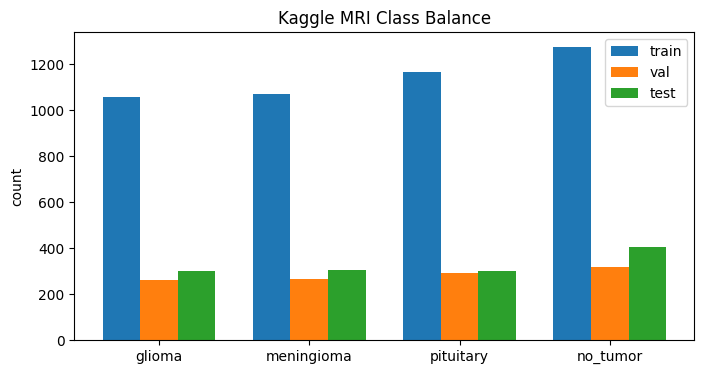

,fold,train_n,val_n,train_dist,val_dist
0,1,3046,1523,"{'meningioma': 714, 'pituitary': 777, 'no_tumo...","{'meningioma': 357, 'no_tumor': 426, 'glioma':..."
1,2,3046,1523,"{'meningioma': 714, 'no_tumor': 851, 'glioma':...","{'meningioma': 357, 'pituitary': 388, 'no_tumo..."
2,3,3046,1523,"{'meningioma': 714, 'no_tumor': 851, 'glioma':...","{'pituitary': 389, 'meningioma': 357, 'glioma'..."



=== STEP 5C DONE ===


In [ ]:
# =========================
# STEP 5C — Final Kaggle Split Construction (LOCKED)
# =========================
import zipfile, re, random
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold

# -------------------------
# Config
# -------------------------
SEED = 42
random.seed(SEED); np.random.seed(SEED)

ZIP_PATH = "/content/drive/MyDrive/project dataset/kaggle MRI.zip"
OUT_DIR = Path("/content/drive/MyDrive/project dataset/outputs_fssr/splits")
OUT_DIR.mkdir(parents=True, exist_ok=True)

IMAGE_EXTS = (".png",".jpg",".jpeg",".bmp",".tif",".tiff")

LABEL_MAP = {
    "gl": "glioma",
    "me": "meningioma",
    "pi": "pituitary",
    "no": "no_tumor"
}

def is_image(p):
    return p.lower().endswith(IMAGE_EXTS)

def extract_label(fname):
    # Tr-gl_0001.jpg / Te-me_123.png
    m = re.search(r"[Tt][re]-([a-z]{2})", fname)
    if m and m.group(1) in LABEL_MAP:
        return LABEL_MAP[m.group(1)]
    return None

print("=== STEP 5C START ===\n")

# -------------------------
# Read ZIP
# -------------------------
rows = []
with zipfile.ZipFile(ZIP_PATH, "r") as z:
    for n in z.namelist():
        if is_image(n):
            split = "train" if n.startswith("Training/") else "test" if n.startswith("Testing/") else None
            if split is None:
                continue
            fname = Path(n).name
            label = extract_label(fname)
            assert label is not None, f"Label parse failed for {fname}"
            rows.append({"zip_path": n, "split": split, "label": label})

df = pd.DataFrame(rows)

print("Total images:", len(df))
print("Split counts:", df["split"].value_counts().to_dict())
print("Class counts (overall):", df["label"].value_counts().to_dict())
print()

# -------------------------
# Separate official splits
# -------------------------
train_df = df[df["split"]=="train"].reset_index(drop=True)
test_df  = df[df["split"]=="test"].reset_index(drop=True)

print("TRAIN size:", len(train_df))
print("TEST size :", len(test_df))
print()

# -------------------------
# Stratified 80/20 (TRAIN only)
# -------------------------
tr_df, val_df = train_test_split(
    train_df,
    test_size=0.20,
    stratify=train_df["label"],
    random_state=SEED
)

tr_df = tr_df.copy(); tr_df["subset"] = "train"
val_df = val_df.copy(); val_df["subset"] = "val"
test_df = test_df.copy(); test_df["subset"] = "test"

# -------------------------
# Save manifests
# -------------------------
tr_df[["zip_path","subset","label"]].to_csv(OUT_DIR/"kaggle_train.csv", index=False)
val_df[["zip_path","subset","label"]].to_csv(OUT_DIR/"kaggle_val.csv", index=False)
test_df[["zip_path","subset","label"]].to_csv(OUT_DIR/"kaggle_test.csv", index=False)

print("Saved manifests:")
print(" - kaggle_train.csv")
print(" - kaggle_val.csv")
print(" - kaggle_test.csv\n")

# -------------------------
# Class balance verification
# -------------------------
def show_counts(name, df_):
    print(f"{name}:", dict(Counter(df_["label"])))

show_counts("TRAIN", tr_df)
show_counts("VAL  ", val_df)
show_counts("TEST ", test_df)
print()

# Plot
classes = list(LABEL_MAP.values())
x = np.arange(len(classes))
plt.figure(figsize=(8,4))
plt.bar(x-0.25, [sum(tr_df["label"]==c) for c in classes], 0.25, label="train")
plt.bar(x,       [sum(val_df["label"]==c) for c in classes], 0.25, label="val")
plt.bar(x+0.25, [sum(test_df["label"]==c) for c in classes], 0.25, label="test")
plt.xticks(x, classes)
plt.ylabel("count")
plt.title("Kaggle MRI Class Balance")
plt.legend()
plt.show()

# -------------------------
# StratifiedKFold (TRAIN only)
# -------------------------
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
fold_summary = []

for i,(a,b) in enumerate(skf.split(tr_df, tr_df["label"]),1):
    fold_summary.append({
        "fold": i,
        "train_n": len(a),
        "val_n": len(b),
        "train_dist": dict(Counter(tr_df.iloc[a]["label"])),
        "val_dist": dict(Counter(tr_df.iloc[b]["label"]))
    })

fold_df = pd.DataFrame(fold_summary)
display(fold_df)

print("\n=== STEP 5C DONE ===")


=== STEP 6 (FIXED) START ===
Kaggle TRAIN samples: 4569
Audit images: 300 | pixels sampled per image: 2000

=== Raw format summary ===
Dtypes: {'uint8': 300}
Channels: {'3ch': 171, '1(gray)': 129}
Example unique shapes (top 10): {'(512, 512)': 125, '(512, 512, 3)': 78, '(225, 225, 3)': 16, '(236, 236, 3)': 4, '(244, 206, 3)': 3, '(168, 300, 3)': 3, '(251, 201, 3)': 3, '(449, 359, 3)': 2, '(630, 630)': 2, '(222, 227, 3)': 2}

=== Per-image stats (sample) — first 12 rows ===


,file,label,raw_shape,gray_shape,dtype,min,p01,p50,p99,max
0,Tr-no_0184.jpg,no_tumor,"(398, 497, 3)","(398, 497)",uint8,0.0,14.0,74.0,202.0,252.0
1,Tr-gl_1081.jpg,glioma,"(512, 512)","(512, 512)",uint8,0.0,0.0,54.0,144.0,255.0
2,Tr-pi_0874.jpg,pituitary,"(512, 512)","(512, 512)",uint8,0.0,0.0,63.0,199.0,255.0
3,Tr-no_1435.jpg,no_tumor,"(449, 359, 3)","(449, 359)",uint8,0.0,1.0,45.0,191.0,253.0
4,Tr-pi_0253.jpg,pituitary,"(512, 512, 3)","(512, 512)",uint8,0.0,0.0,56.0,177.0,255.0
5,Tr-me_0541.jpg,meningioma,"(512, 512, 3)","(512, 512)",uint8,0.0,0.0,16.0,178.0,255.0
6,Tr-gl_0495.jpg,glioma,"(512, 512)","(512, 512)",uint8,0.0,0.0,2.0,127.0,255.0
7,Tr-pi_1060.jpg,pituitary,"(512, 512)","(512, 512)",uint8,0.0,0.0,41.0,169.0,255.0
8,Tr-gl_0675.jpg,glioma,"(512, 512)","(512, 512)",uint8,0.0,0.0,3.0,156.0,252.0
9,Tr-gl_0943.jpg,glioma,"(512, 512)","(512, 512)",uint8,0.0,0.0,23.0,158.0,255.0


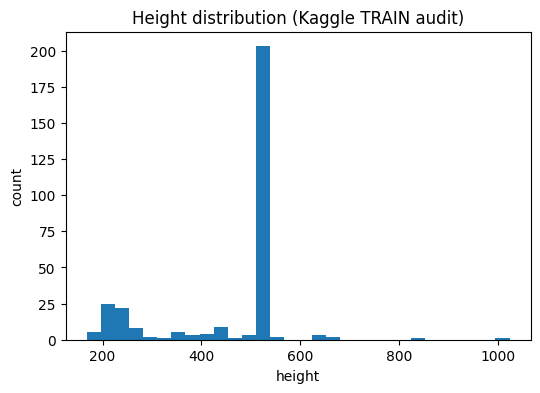

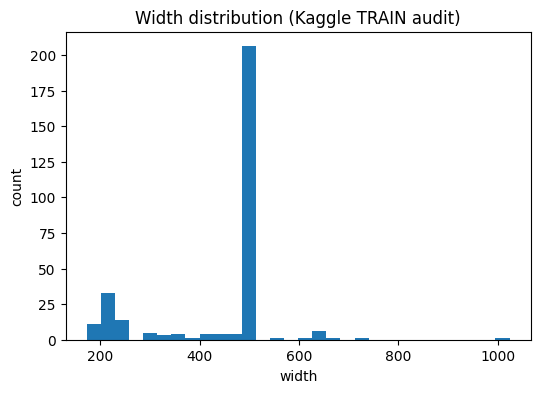

=== Resolution summary ===
Height: min/median/max = 168 512 1024
Width : min/median/max = 173 512 1024



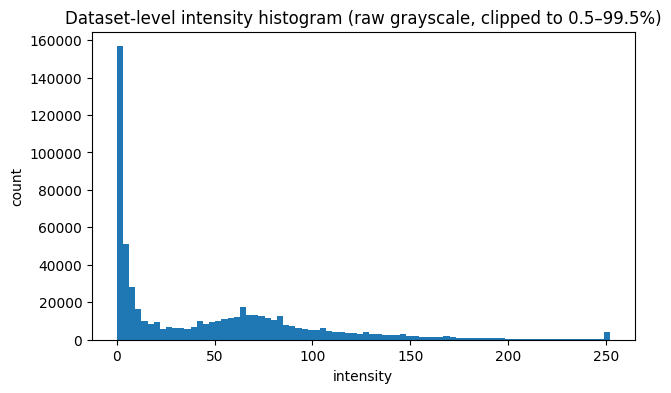

=== Dataset-level intensity stats (sampled pixels) ===
dtype(float32) | min: 0.0 max: 255.0
percentiles [0.5, 1, 50, 99, 99.5]: [0.0, 0.0, 32.0, 232.0, 252.0]



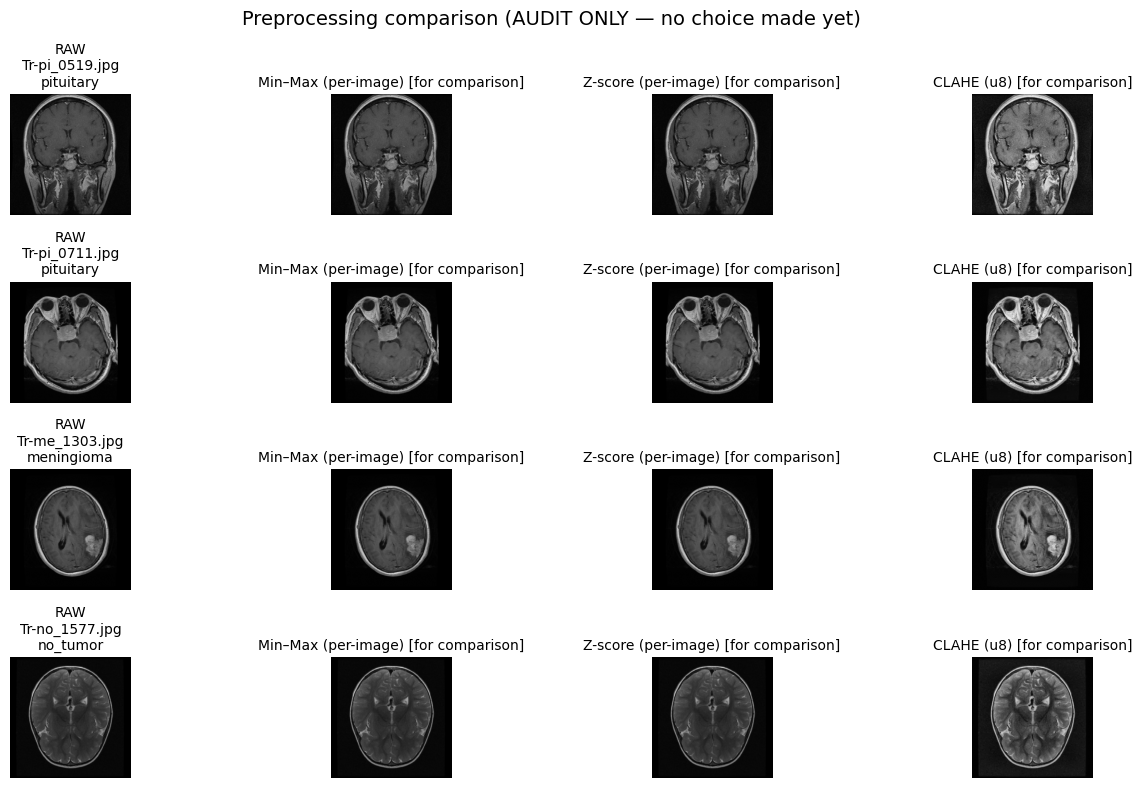

=== STEP 6 (FIXED) DONE ===


In [ ]:
# =========================
# STEP 6 (FIXED) — Kaggle MRI Preprocessing Audit (NO decisions yet)
# - No resizing
# - No committed normalization
# - Collect dataset-level intensity + resolution stats
# =========================
import zipfile, random
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED); np.random.seed(SEED)

ZIP_PATH = "/content/drive/MyDrive/project dataset/kaggle MRI.zip"
SPLIT_DIR = Path("/content/drive/MyDrive/project dataset/outputs_fssr/splits")
train_manifest = pd.read_csv(SPLIT_DIR / "kaggle_train.csv")

N_IMG_AUDIT = 300          # how many images to audit for resolution/dtype stats
PIXELS_PER_IMAGE = 2000    # sampled pixels per image for dataset histogram (keeps memory low)

def read_image_from_zip(z, zip_path):
    b = z.read(zip_path)
    arr = np.frombuffer(b, np.uint8)
    img = cv2.imdecode(arr, cv2.IMREAD_UNCHANGED)
    return img

def to_gray(img):
    if img is None:
        return None
    if img.ndim == 2:
        return img
    if img.ndim == 3 and img.shape[2] == 3:
        return cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    if img.ndim == 3 and img.shape[2] == 4:
        return cv2.cvtColor(img, cv2.COLOR_BGRA2GRAY)
    # fallback: take first channel (rare formats)
    return img[..., 0]

def minmax_norm(img_f):
    eps = 1e-6
    mn, mx = float(img_f.min()), float(img_f.max())
    return (img_f - mn) / (mx - mn + eps)

def zscore_norm(img_f):
    eps = 1e-6
    mu, sd = float(img_f.mean()), float(img_f.std())
    return (img_f - mu) / (sd + eps)

def clahe_u8(img_u8):
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    return clahe.apply(img_u8)

print("=== STEP 6 (FIXED) START ===")
print("Kaggle TRAIN samples:", len(train_manifest))
print("Audit images:", N_IMG_AUDIT, "| pixels sampled per image:", PIXELS_PER_IMAGE)
print()

# -------------------------
# 1) Audit a stratified-ish sample (random but reproducible)
# -------------------------
audit_df = train_manifest.sample(min(N_IMG_AUDIT, len(train_manifest)), random_state=SEED).reset_index(drop=True)

per_img_stats = []
dtype_counter = Counter()
shape_counter = Counter()
channel_counter = Counter()

# For dataset-level histogram: collect sampled pixels into one vector (float32)
pixel_samples = []

with zipfile.ZipFile(ZIP_PATH, "r") as z:
    for i, row in audit_df.iterrows():
        img = read_image_from_zip(z, row["zip_path"])
        assert img is not None, f"Failed to read {row['zip_path']}"

        # record raw format
        dtype_counter[str(img.dtype)] += 1
        if img.ndim == 2:
            channel_counter["1(gray)"] += 1
        elif img.ndim == 3:
            channel_counter[f"{img.shape[2]}ch"] += 1
        else:
            channel_counter[f"{img.ndim}D"] += 1

        shape_counter[str(img.shape)] += 1

        g = to_gray(img)
        g_f = g.astype(np.float32)

        # per-image stats (raw grayscale)
        p01, p50, p99 = np.percentile(g_f, [1, 50, 99])
        per_img_stats.append({
            "file": Path(row["zip_path"]).name,
            "label": row["label"],
            "raw_shape": img.shape,
            "gray_shape": g.shape,
            "dtype": str(img.dtype),
            "min": float(g_f.min()),
            "p01": float(p01),
            "p50": float(p50),
            "p99": float(p99),
            "max": float(g_f.max()),
        })

        # sample pixels for dataset histogram
        flat = g_f.reshape(-1)
        if len(flat) > PIXELS_PER_IMAGE:
            idx = np.random.choice(len(flat), PIXELS_PER_IMAGE, replace=False)
            samp = flat[idx]
        else:
            samp = flat
        pixel_samples.append(samp)

pixel_samples = np.concatenate(pixel_samples).astype(np.float32)

stats_df = pd.DataFrame(per_img_stats)

print("=== Raw format summary ===")
print("Dtypes:", dict(dtype_counter))
print("Channels:", dict(channel_counter))
print("Example unique shapes (top 10):", dict(shape_counter.most_common(10)))
print()

print("=== Per-image stats (sample) — first 12 rows ===")
display(stats_df.head(12))

# -------------------------
# 2) Resolution distribution (gray_shape)
# -------------------------
# extract H,W from gray_shape
hw = stats_df["gray_shape"].apply(lambda s: (int(s[0]), int(s[1])) if isinstance(s, tuple) else (int(s[0]), int(s[1])))
# In case pandas stored tuple properly:
hw = stats_df["gray_shape"].apply(lambda t: (t[0], t[1]))
h = hw.apply(lambda x: x[0]).to_numpy()
w = hw.apply(lambda x: x[1]).to_numpy()

plt.figure(figsize=(6,4))
plt.hist(h, bins=30)
plt.title("Height distribution (Kaggle TRAIN audit)")
plt.xlabel("height"); plt.ylabel("count")
plt.show()

plt.figure(figsize=(6,4))
plt.hist(w, bins=30)
plt.title("Width distribution (Kaggle TRAIN audit)")
plt.xlabel("width"); plt.ylabel("count")
plt.show()

print("=== Resolution summary ===")
print("Height: min/median/max =", int(h.min()), int(np.median(h)), int(h.max()))
print("Width : min/median/max =", int(w.min()), int(np.median(w)), int(w.max()))
print()

# -------------------------
# 3) Dataset-level intensity histogram (raw grayscale)
# -------------------------
# robust percentiles for plotting range
lo, hi = np.percentile(pixel_samples, [0.5, 99.5])

plt.figure(figsize=(7,4))
plt.hist(np.clip(pixel_samples, lo, hi), bins=80)
plt.title("Dataset-level intensity histogram (raw grayscale, clipped to 0.5–99.5%)")
plt.xlabel("intensity"); plt.ylabel("count")
plt.show()

print("=== Dataset-level intensity stats (sampled pixels) ===")
print("dtype(float32) | min:", float(pixel_samples.min()), "max:", float(pixel_samples.max()))
print("percentiles [0.5, 1, 50, 99, 99.5]:",
      [float(x) for x in np.percentile(pixel_samples, [0.5, 1, 50, 99, 99.5])])
print()

# -------------------------
# 4) Visual comparison panel (NO decision) on a few images
# -------------------------
viz_df = train_manifest.sample(4, random_state=SEED+1).reset_index(drop=True)

with zipfile.ZipFile(ZIP_PATH, "r") as z:
    fig = plt.figure(figsize=(14,8))
    for i, row in viz_df.iterrows():
        img = read_image_from_zip(z, row["zip_path"])
        g = to_gray(img).astype(np.float32)

        # prepare variants
        raw = g
        mm = minmax_norm(g)
        zz = zscore_norm(g)

        # CLAHE needs uint8: scale robustly to 0..255 just for visualization (not a commitment)
        g_u8 = cv2.normalize(g, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
        cl = clahe_u8(g_u8).astype(np.float32) / 255.0

        # plot
        def show(ax, im, title):
            ax.imshow(im, cmap="gray")
            ax.set_title(title, fontsize=10)
            ax.axis("off")

        r = i*4
        show(plt.subplot(4,4,r+1), raw, f"RAW\n{Path(row['zip_path']).name}\n{row['label']}")
        show(plt.subplot(4,4,r+2), mm,  "Min–Max (per-image) [for comparison]")
        show(plt.subplot(4,4,r+3), zz,  "Z-score (per-image) [for comparison]")
        show(plt.subplot(4,4,r+4), cl,  "CLAHE (u8) [for comparison]")

    plt.suptitle("Preprocessing comparison (AUDIT ONLY — no choice made yet)", fontsize=14)
    plt.tight_layout()
    plt.show()

print("=== STEP 6 (FIXED) DONE ===")


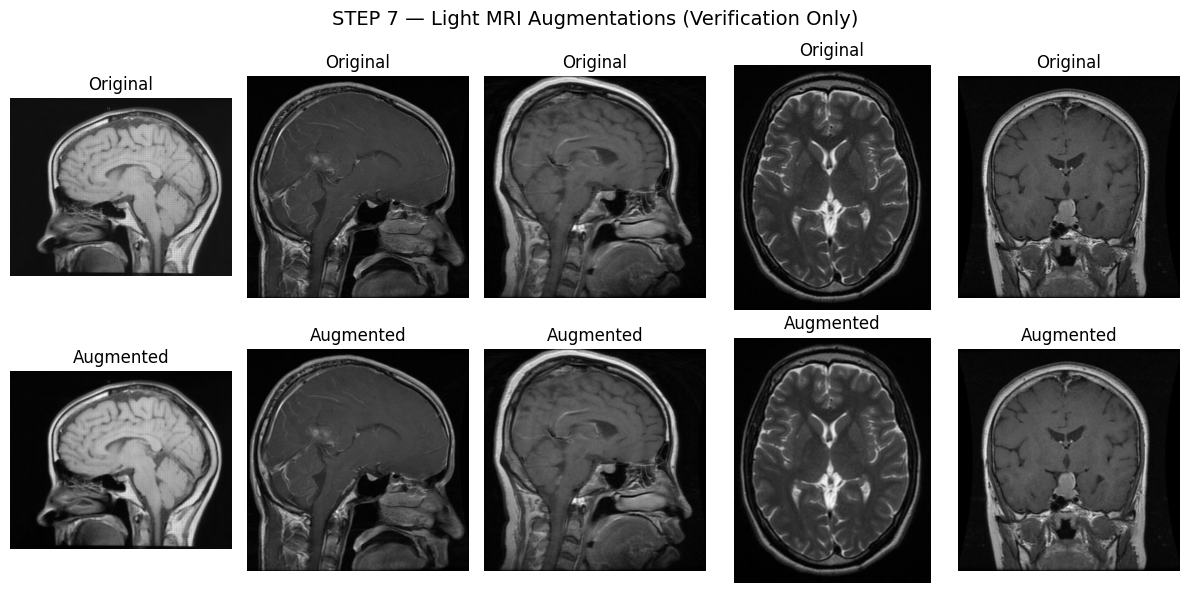

=== STEP 7 DONE ===


In [ ]:
# =========================
# STEP 7 — Light MRI-Safe Augmentations (EXPLICIT & SHARED)
# =========================
import zipfile, random
from pathlib import Path
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED); np.random.seed(SEED)

ZIP_PATH = "/content/drive/MyDrive/project dataset/kaggle MRI.zip"
SPLIT_DIR = Path("/content/drive/MyDrive/project dataset/outputs_fssr/splits")
train_manifest = pd.read_csv(SPLIT_DIR / "kaggle_train.csv")

# -------------------------
# Light augmentation definition (LOCKED)
# -------------------------
def light_mri_augment(img_f):
    """
    img_f: float32 grayscale image (RAW intensity, no normalization assumed)
    returns augmented image (float32)
    """

    out = img_f.copy()

    # 1) Intensity scaling (±10%)
    scale = np.random.uniform(0.9, 1.1)
    out = out * scale

    # 2) Mild Gaussian noise (relative to image std)
    sigma = 0.01 * (np.std(out) + 1e-6)
    noise = np.random.normal(0, sigma, size=out.shape)
    out = out + noise

    # 3) Very mild Gaussian blur (σ ≤ 0.8)
    if np.random.rand() < 0.5:
        out = cv2.GaussianBlur(out, (3,3), sigmaX=0.8)

    return out

def to_gray(img):
    if img.ndim == 2:
        return img
    if img.ndim == 3 and img.shape[2] == 3:
        return cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    if img.ndim == 3 and img.shape[2] == 4:
        return cv2.cvtColor(img, cv2.COLOR_BGRA2GRAY)
    return img[...,0]

# -------------------------
# Visual verification
# -------------------------
viz_df = train_manifest.sample(5, random_state=SEED).reset_index(drop=True)

with zipfile.ZipFile(ZIP_PATH, "r") as z:
    plt.figure(figsize=(12,6))

    for i, row in viz_df.iterrows():
        img_bytes = z.read(row["zip_path"])
        arr = np.frombuffer(img_bytes, np.uint8)
        img = cv2.imdecode(arr, cv2.IMREAD_UNCHANGED)

        g = to_gray(img).astype(np.float32)

        aug = light_mri_augment(g)

        # Normalize only for visualization
        def vis(x):
            return cv2.normalize(x, None, 0, 1, cv2.NORM_MINMAX)

        plt.subplot(2, len(viz_df), i+1)
        plt.imshow(vis(g), cmap="gray")
        plt.title("Original")
        plt.axis("off")

        plt.subplot(2, len(viz_df), i+1+len(viz_df))
        plt.imshow(vis(aug), cmap="gray")
        plt.title("Augmented")
        plt.axis("off")

    plt.suptitle("STEP 7 — Light MRI Augmentations (Verification Only)", fontsize=14)
    plt.tight_layout()
    plt.show()

print("=== STEP 7 DONE ===")


In [ ]:
# =========================
# STEP 7.5 — Quantitative Verification of Light MRI Augmentations
# =========================
import zipfile
import numpy as np
import pandas as pd
import cv2
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr
from pathlib import Path

SEED = 42
np.random.seed(SEED)

ZIP_PATH = "/content/drive/MyDrive/project dataset/kaggle MRI.zip"
SPLIT_DIR = Path("/content/drive/MyDrive/project dataset/outputs_fssr/splits")
train_manifest = pd.read_csv(SPLIT_DIR / "kaggle_train.csv")

N_EVAL = 200  # enough for stable statistics
eval_df = train_manifest.sample(min(N_EVAL, len(train_manifest)), random_state=SEED)

# --- reuse augmentation ---
def light_mri_augment(img_f):
    out = img_f.copy()
    scale = np.random.uniform(0.9, 1.1)
    out = out * scale
    sigma = 0.01 * (np.std(out) + 1e-6)
    out = out + np.random.normal(0, sigma, out.shape)
    if np.random.rand() < 0.5:
        out = cv2.GaussianBlur(out, (3,3), sigmaX=0.8)
    return out

def to_gray(img):
    if img.ndim == 2:
        return img
    if img.ndim == 3 and img.shape[2] == 3:
        return cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    if img.ndim == 3 and img.shape[2] == 4:
        return cv2.cvtColor(img, cv2.COLOR_BGRA2GRAY)
    return img[...,0]

def normalize_for_metrics(x):
    return cv2.normalize(x, None, 0, 1, cv2.NORM_MINMAX)

metrics = []

with zipfile.ZipFile(ZIP_PATH, "r") as z:
    for _, row in eval_df.iterrows():
        img_bytes = z.read(row["zip_path"])
        arr = np.frombuffer(img_bytes, np.uint8)
        img = cv2.imdecode(arr, cv2.IMREAD_UNCHANGED)

        g = to_gray(img).astype(np.float32)
        aug = light_mri_augment(g)

        g_n = normalize_for_metrics(g)
        aug_n = normalize_for_metrics(aug)

        ssim_val = ssim(g_n, aug_n, data_range=1.0)
        psnr_val = psnr(g_n, aug_n, data_range=1.0)
        rel_l2 = np.linalg.norm(g_n - aug_n) / (np.linalg.norm(g_n) + 1e-8)

        metrics.append({
            "SSIM": ssim_val,
            "PSNR": psnr_val,
            "Rel_L2": rel_l2
        })

metrics_df = pd.DataFrame(metrics)

print("=== STEP 7.5 — Input-level perturbation metrics ===")
display(metrics_df.describe().loc[["mean","std","min","max"]])


=== STEP 7.5 — Input-level perturbation metrics ===


,SSIM,PSNR,Rel_L2
mean,0.944370,38.923253,0.060294
std,0.061677,6.960993,0.064132
min,0.650172,16.360951,0.009241
max,0.998508,49.803978,0.408609


=== STEP 8 VERIFICATION (FIXED) ===
Train batch: torch.Size([32, 1, 224, 224]) torch.float32 labels: [0, 1, 2, 3]
Val batch  : torch.Size([32, 1, 224, 224]) torch.float32 labels: [0, 1, 2, 3]


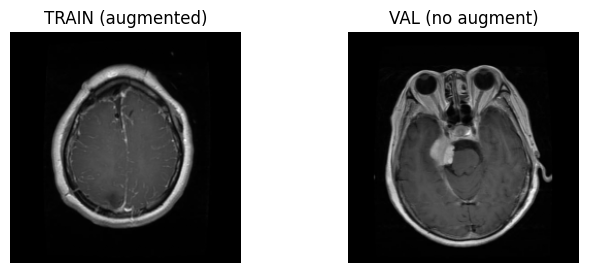


=== STEP 8 DONE ===


In [ ]:
# =========================
# STEP 8 (FIXED) — Dataset & DataLoader (Resolution-safe)
# =========================
import zipfile, random
from pathlib import Path
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
import cv2
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

ZIP_PATH = "/content/drive/MyDrive/project dataset/kaggle MRI.zip"
SPLIT_DIR = Path("/content/drive/MyDrive/project dataset/outputs_fssr/splits")

train_manifest = pd.read_csv(SPLIT_DIR / "kaggle_train.csv")
val_manifest   = pd.read_csv(SPLIT_DIR / "kaggle_val.csv")

CLASS_TO_IDX = {
    "glioma": 0,
    "meningioma": 1,
    "pituitary": 2,
    "no_tumor": 3
}

TARGET_SIZE = 224  # geometry only, not normalization

# -------------------------
# Utilities
# -------------------------
def to_gray(img):
    if img.ndim == 2:
        return img
    if img.ndim == 3 and img.shape[2] == 3:
        return cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    if img.ndim == 3 and img.shape[2] == 4:
        return cv2.cvtColor(img, cv2.COLOR_BGRA2GRAY)
    return img[...,0]

def resize_only(img, size=224):
    return cv2.resize(img, (size, size), interpolation=cv2.INTER_AREA)

def light_mri_augment(img_f):
    out = img_f.copy()
    out *= np.random.uniform(0.9, 1.1)
    sigma = 0.01 * (np.std(out) + 1e-6)
    out += np.random.normal(0, sigma, out.shape)
    if np.random.rand() < 0.5:
        out = cv2.GaussianBlur(out, (3,3), sigmaX=0.8)
    return out

# -------------------------
# Dataset
# -------------------------
class KaggleMRIDataset(Dataset):
    def __init__(self, manifest, zip_path, augment=False):
        self.df = manifest.reset_index(drop=True)
        self.zip_path = zip_path
        self.augment = augment

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        with zipfile.ZipFile(self.zip_path, "r") as z:
            img_bytes = z.read(row["zip_path"])

        arr = np.frombuffer(img_bytes, np.uint8)
        img = cv2.imdecode(arr, cv2.IMREAD_UNCHANGED)
        assert img is not None, row["zip_path"]

        img = to_gray(img).astype(np.float32)

        if self.augment:
            img = light_mri_augment(img)

        # 🔒 Geometry fix (mandatory for batching)
        img = resize_only(img, TARGET_SIZE)

        img_t = torch.from_numpy(img).unsqueeze(0)  # (1, H, W)
        label = CLASS_TO_IDX[row["label"]]
        return img_t, label

# -------------------------
# DataLoaders
# -------------------------
train_loader = DataLoader(
    KaggleMRIDataset(train_manifest, ZIP_PATH, augment=True),
    batch_size=32, shuffle=True, num_workers=2, pin_memory=True
)

val_loader = DataLoader(
    KaggleMRIDataset(val_manifest, ZIP_PATH, augment=False),
    batch_size=32, shuffle=False, num_workers=2, pin_memory=True
)

# -------------------------
# Verification
# -------------------------
print("=== STEP 8 VERIFICATION (FIXED) ===")

x_tr, y_tr = next(iter(train_loader))
x_va, y_va = next(iter(val_loader))

print("Train batch:", x_tr.shape, x_tr.dtype, "labels:", y_tr.unique().tolist())
print("Val batch  :", x_va.shape, x_va.dtype, "labels:", y_va.unique().tolist())

plt.figure(figsize=(8,3))
plt.subplot(1,2,1)
plt.imshow(x_tr[0,0].numpy(), cmap="gray")
plt.title("TRAIN (augmented)")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(x_va[0,0].numpy(), cmap="gray")
plt.title("VAL (no augment)")
plt.axis("off")
plt.show()

print("\n=== STEP 8 DONE ===")


In [ ]:
# =========================
# STEP 9 — Backbone Models (Feature-Extracting CNNs)
# ResNet18 / ResNet34 / DenseNet121
# =========================

import torch
import torch.nn as nn
from torchvision import models

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
NUM_CLASSES = 4

print("Device:", DEVICE)
print()

# -------------------------
# Helper: count parameters
# -------------------------
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# =================================================
# ResNet18 (1-channel)
# =================================================
class ResNet18_FSSR(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()
        self.backbone = models.resnet18(weights=None)

        self.backbone.conv1 = nn.Conv2d(
            1, 64, kernel_size=7, stride=2, padding=3, bias=False
        )

        self.feature_dim = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()
        self.classifier = nn.Linear(self.feature_dim, num_classes)

    def forward(self, x, return_features=False):
        f = self.backbone(x)        # [B, 512]
        y = self.classifier(f)
        return (y, f) if return_features else y


# =================================================
# ResNet34 (1-channel)
# =================================================
class ResNet34_FSSR(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()
        self.backbone = models.resnet34(weights=None)

        self.backbone.conv1 = nn.Conv2d(
            1, 64, kernel_size=7, stride=2, padding=3, bias=False
        )

        self.feature_dim = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()
        self.classifier = nn.Linear(self.feature_dim, num_classes)

    def forward(self, x, return_features=False):
        f = self.backbone(x)        # [B, 512]
        y = self.classifier(f)
        return (y, f) if return_features else y


# =================================================
# DenseNet121 (1-channel)
# =================================================
class DenseNet121_FSSR(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()
        self.backbone = models.densenet121(weights=None)

        self.backbone.features.conv0 = nn.Conv2d(
            1, 64, kernel_size=7, stride=2, padding=3, bias=False
        )

        self.feature_dim = self.backbone.classifier.in_features
        self.backbone.classifier = nn.Identity()
        self.classifier = nn.Linear(self.feature_dim, num_classes)

    def forward(self, x, return_features=False):
        f = self.backbone(x)        # [B, 1024]
        y = self.classifier(f)
        return (y, f) if return_features else y


# -------------------------
# Instantiate
# -------------------------
resnet18    = ResNet18_FSSR(NUM_CLASSES).to(DEVICE)
resnet34    = ResNet34_FSSR(NUM_CLASSES).to(DEVICE)
densenet121 = DenseNet121_FSSR(NUM_CLASSES).to(DEVICE)

# -------------------------
# Verification
# -------------------------
models_dict = {
    "ResNet18": resnet18,
    "ResNet34": resnet34,
    "DenseNet121": densenet121,
}

dummy = torch.randn(2, 1, 224, 224).to(DEVICE)

print("=== STEP 9 VERIFICATION ===")
for name, model in models_dict.items():
    y, f = model(dummy, return_features=True)
    print(f"\n{name}")
    print("  Params        :", count_params(model))
    print("  Feature dim   :", f.shape[1])
    print("  Output shape  :", y.shape)
    print("  Feature finite:", torch.isfinite(f).all().item())

print("\n=== STEP 9 DONE ===")


Device: cuda

=== STEP 9 VERIFICATION ===

ResNet18
  Params        : 11172292
  Feature dim   : 512
  Output shape  : torch.Size([2, 4])
  Feature finite: True

ResNet34
  Params        : 21280452
  Feature dim   : 512
  Output shape  : torch.Size([2, 4])
  Feature finite: True

DenseNet121
  Params        : 6951684
  Feature dim   : 1024
  Output shape  : torch.Size([2, 4])
  Feature finite: True

=== STEP 9 DONE ===


In [ ]:
# =========================
# STEP 10 — FSSR Loss Implementation + Gradient Flow Verification
# All Backbones
# =========================

import torch
import torch.nn as nn
import numpy as np

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
CE = nn.CrossEntropyLoss()

# -------------------------------------------------
# MODELS (from STEP 9)
# -------------------------------------------------
models_to_test = {
    "ResNet18": resnet18,
    "ResNet34": resnet34,
    "DenseNet121": densenet121,
}

# λ grid (LOCKED)
LAMBDAS = [0.0, 0.01, 0.05, 0.1]

# -------------------------------------------------
# Torch-safe augmentation wrapper
# -------------------------------------------------
def augment_batch_light(x_t):
    """
    x_t: torch tensor (B,1,H,W)
    returns augmented tensor same shape
    """
    x_np = x_t.detach().cpu().numpy()
    out = []
    for i in range(x_np.shape[0]):
        img = x_np[i, 0]              # (H,W)
        aug = light_mri_augment(img)  # from STEP 8
        out.append(aug[None, ...])    # (1,H,W)
    out = np.stack(out, axis=0).astype(np.float32)
    return torch.from_numpy(out).to(x_t.device)

# -------------------------------------------------
# FSSR loss function (shared)
# -------------------------------------------------
def fssr_losses(model, x, y, lam):
    logits, f = model(x, return_features=True)

    x_aug = augment_batch_light(x)
    logits_aug, f_aug = model(x_aug, return_features=True)

    ce = CE(logits, y)

    # Stability loss: feature L2 distance
    stab = torch.norm(f - f_aug, p=2, dim=1).mean()

    total = ce + lam * stab
    return ce, stab, total

# -------------------------------------------------
# Get one batch (same batch for all models)
# -------------------------------------------------
x, y = next(iter(train_loader))
x = x.to(DEVICE)
y = y.to(DEVICE)

print("=== STEP 10 VERIFICATION (ALL MODELS) ===")
print("Batch:", tuple(x.shape), "| labels:", torch.unique(y).tolist())
print()

# -------------------------------------------------
# Run gradient check
# -------------------------------------------------
for model_name, model in models_to_test.items():
    model = model.to(DEVICE)
    model.train()

    print(f"\n--- {model_name} ---")

    for lam in LAMBDAS:
        model.zero_grad(set_to_none=True)

        ce, stab, total = fssr_losses(model, x, y, lam)
        total.backward()

        # Gradient flow check: first parameter with grad
        grad_norm = None
        first_grad_name = None
        for name, p in model.named_parameters():
            if p.requires_grad and p.grad is not None:
                grad_norm = float(p.grad.detach().abs().mean().cpu())
                first_grad_name = name
                break

        print(
            f"λ={lam:.2f} | "
            f"CE={float(ce.detach().cpu()):.6f} | "
            f"STAB={float(stab.detach().cpu()):.6f} | "
            f"TOTAL={float(total.detach().cpu()):.6f}"
        )
        print(
            f"   first grad param: {first_grad_name} | "
            f"mean|grad|={grad_norm:.6e}"
        )

print("\n=== STEP 10 DONE ===")


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x78a4c4b116c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
   Exception ignored in:  <function _MultiProcessingDataLoaderIter.__del__ at 0x78a4c4b116c0> 
 Traceback (most recent call last):
   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
       self._shutdown_workers() 
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
^^^    if w.is_alive():^
^ ^ ^ ^ ^ ^^ ^ ^^^^^^^^^^^^

=== STEP 10 VERIFICATION (ALL MODELS) ===
Batch: (32, 1, 224, 224) | labels: [0, 1, 2, 3]


--- ResNet18 ---
λ=0.00 | CE=1.496357 | STAB=2.861708 | TOTAL=1.496357
   first grad param: backbone.conv1.weight | mean|grad|=1.224538e-02
λ=0.01 | CE=1.496357 | STAB=2.753760 | TOTAL=1.523895
   first grad param: backbone.conv1.weight | mean|grad|=1.210140e-02
λ=0.05 | CE=1.496357 | STAB=2.739848 | TOTAL=1.633349
   first grad param: backbone.conv1.weight | mean|grad|=1.245791e-02
λ=0.10 | CE=1.496357 | STAB=3.114405 | TOTAL=1.807797
   first grad param: backbone.conv1.weight | mean|grad|=1.391380e-02

--- ResNet34 ---
λ=0.00 | CE=1.559303 | STAB=3.970620 | TOTAL=1.559303
   first grad param: backbone.conv1.weight | mean|grad|=4.106614e-02
λ=0.01 | CE=1.559303 | STAB=3.639853 | TOTAL=1.595702
   first grad param: backbone.conv1.weight | mean|grad|=4.107617e-02
λ=0.05 | CE=1.559303 | STAB=3.719668 | TOTAL=1.745287
   first grad param: backbone.conv1.weight | mean|grad|=4.116209e-02
λ=0.10 | CE=

In [ ]:
# ============================================================
# STEP 10.5 — Micro-Overfit Sanity Check (ResNet18, FINAL)
# λ selected from stability sweep: λ = 0.05
# ============================================================

import torch
import torch.nn as nn
import numpy as np
import random
import matplotlib.pyplot as plt
from torch.utils.data import Subset, DataLoader

# -------------------------
# GLOBAL CONFIG
# -------------------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

CE = nn.CrossEntropyLoss()

MICRO_N = 64
BATCH_SIZE = 32
EPOCHS = 8
LR = 1e-4
LAMBDA = 0.05   # ✅ SELECTED

print("Device:", DEVICE)
print("λ =", LAMBDA)

# -------------------------
# MICRO DATASET (64 samples)
# -------------------------
rng = np.random.RandomState(SEED)
micro_idx = rng.choice(len(train_manifest), size=MICRO_N, replace=False)

micro_ds = Subset(
    KaggleMRIDataset(train_manifest, ZIP_PATH, augment=True),
    micro_idx
)

micro_loader = DataLoader(
    micro_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

# -------------------------
# TRAINING LOOP
# -------------------------
def train_micro(model, lam):
    model = model.to(DEVICE)
    model.train()
    opt = torch.optim.AdamW(model.parameters(), lr=LR)

    losses, accs = [], []

    for ep in range(1, EPOCHS + 1):
        correct, total, running_loss = 0, 0, 0.0

        for x, y in micro_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            opt.zero_grad(set_to_none=True)

            logits, f = model(x, return_features=True)

            if lam > 0:
                x_aug = augment_batch_light(x)
                _, f_aug = model(x_aug, return_features=True)
                stab = torch.norm(f - f_aug, p=2, dim=1).mean()
                loss = CE(logits, y) + lam * stab
            else:
                loss = CE(logits, y)

            loss.backward()
            opt.step()

            running_loss += loss.item() * x.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

        epoch_loss = running_loss / total
        epoch_acc = correct / total

        losses.append(epoch_loss)
        accs.append(epoch_acc)

        print(
            f"Epoch {ep:02d} | "
            f"loss={epoch_loss:.4f} | "
            f"acc={epoch_acc*100:.2f}%"
        )

    return losses, accs

# -------------------------
# RUN CE vs FSSR
# -------------------------
print("\n=== RUNNING MICRO-OVERFIT ===")

model_ce = ResNet18_FSSR(4)
model_fssr= ResNet18_FSSR(4)

loss_ce, acc_ce = train_micro(model_ce, lam=0.0)
print()
loss_fs, acc_fs = train_micro(model_fssr, lam=LAMBDA)

# -------------------------
# PLOT
# -------------------------
plt.figure(figsize=(6,4))
plt.plot(loss_ce, label="CE (λ=0)")
plt.plot(loss_fs, label=f"FSSR (λ={LAMBDA})")
plt.title("Micro-overfit sanity check — ResNet18 (64 samples)")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.tight_layout()
plt.show()

print("\n=== STEP 10.5 DONE — ResNet18 ===")


Device: cuda
λ = 0.05


TypeError: KaggleMRIDataset.__init__() got an unexpected keyword argument 'augment'

In [ ]:
# =========================
# STEP 11 — Feature Stability Measurement (SINGLE MODEL)
# =========================

import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# -------------------------
# Validation loader (NO augmentation)
# -------------------------
val_ds_eval = KaggleMRIDataset(
    val_manifest,
    ZIP_PATH,
    augment=False
)

val_loader_eval = DataLoader(
    val_ds_eval,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

# -------------------------
# Feature distance collector
# -------------------------
@torch.no_grad()
def collect_feature_distances(model):
    model.eval()
    dists = []

    for x, _ in val_loader_eval:
        x = x.to(DEVICE)

        _, f = model(x, return_features=True)

        x_aug = augment_batch_light(x)
        _, f_aug = model(x_aug, return_features=True)

        dist = torch.norm(f - f_aug, p=2, dim=1)
        dists.append(dist.cpu().numpy())

    return np.concatenate(dists)

# -------------------------
# Use models from STEP 10.5
# -------------------------
ce_model   = m_ce.to(DEVICE).eval()
fssr_model = m_fssr.to(DEVICE).eval()

# -------------------------
# Collect distances
# -------------------------
d_ce = collect_feature_distances(ce_model)
d_fs = collect_feature_distances(fssr_model)

print("=== STEP 11 FEATURE STABILITY ===")
print(f"CE   : mean={d_ce.mean():.4f} | std={d_ce.std():.4f}")
print(f"FSSR : mean={d_fs.mean():.4f} | std={d_fs.std():.4f}")

# -------------------------
# Plot (HD)
# -------------------------
fig, ax = plt.subplots(figsize=(8, 5.5), dpi=300)
bins = np.linspace(0, 50, 60)

ax.hist(d_ce, bins=bins, alpha=0.62, label='CE', color='#6BAED6',
        edgecolor='#4A8BB5', linewidth=0.4)
ax.hist(d_fs, bins=bins, alpha=0.72, label='FSSR', color='#F4A460',
        edgecolor='#D2884A', linewidth=0.4)

ax.set_xlabel(r'$\| \, f(\mathbf{x}) - f(\mathrm{augment}(\mathbf{x})) \, \|_2$',
              fontsize=14, labelpad=10)
ax.set_ylabel('count', fontsize=14, labelpad=10)
ax.set_title('Feature Stability — ResNet-34 (Validation)',
             fontsize=16, fontweight='bold', pad=14)
ax.legend(fontsize=12, framealpha=0.9, edgecolor='#cccccc', loc='upper right')
ax.set_xlim(0, 50)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', labelsize=11)

fig.tight_layout()
fig.savefig("feature_stability_resnet34.png", dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print("Saved: feature_stability_resnet34.png")
print("\n=== STEP 11 DONE ===")

TypeError: KaggleMRIDataset.__init__() got an unexpected keyword argument 'augment'

In [ ]:
# ============================================================
# STEP 10.5 — Micro-Overfit Sanity Check (DenseNet121, FINAL)
# λ selected from stability sweep: λ = 0.002
# ============================================================

import torch
import torch.nn as nn
import numpy as np
import random
import matplotlib.pyplot as plt
from torch.utils.data import Subset, DataLoader

# -------------------------
# GLOBAL CONFIG
# -------------------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

CE = nn.CrossEntropyLoss()

MICRO_N = 64
BATCH_SIZE = 32
EPOCHS = 8
LR = 1e-4
LAMBDA = 0.002   # ✅ SELECTED FOR DENSENET

print("Device:", DEVICE)
print("λ =", LAMBDA)

# -------------------------
# MICRO DATASET (64 samples)
# -------------------------
rng = np.random.RandomState(SEED)
micro_idx = rng.choice(len(train_manifest), size=MICRO_N, replace=False)

micro_ds = Subset(
    KaggleMRIDataset(train_manifest, ZIP_PATH, augment=True),
    micro_idx
)

micro_loader = DataLoader(
    micro_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

# -------------------------
# TRAINING LOOP
# -------------------------
def train_micro(model, lam):
    model = model.to(DEVICE)
    model.train()
    opt = torch.optim.AdamW(model.parameters(), lr=LR)

    losses, accs = [], []

    for ep in range(1, EPOCHS + 1):
        correct, total, running_loss = 0, 0, 0.0

        for x, y in micro_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            opt.zero_grad(set_to_none=True)

            logits, f = model(x, return_features=True)

            if lam > 0:
                x_aug = augment_batch_light(x)
                _, f_aug = model(x_aug, return_features=True)
                stab = torch.norm(f - f_aug, p=2, dim=1).mean()
                loss = CE(logits, y) + lam * stab
            else:
                loss = CE(logits, y)

            loss.backward()
            opt.step()

            running_loss += loss.item() * x.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

        epoch_loss = running_loss / total
        epoch_acc = correct / total

        losses.append(epoch_loss)
        accs.append(epoch_acc)

        print(
            f"Epoch {ep:02d} | "
            f"loss={epoch_loss:.4f} | "
            f"acc={epoch_acc*100:.2f}%"
        )

    return losses, accs

# -------------------------
# RUN CE vs FSSR
# -------------------------
print("\n=== RUNNING MICRO-OVERFIT ===")

model_ce   = DenseNet121_FSSR(4)
model_fssr = DenseNet121_FSSR(4)

loss_ce, acc_ce = train_micro(model_ce, lam=0.0)
print()
loss_fs, acc_fs = train_micro(model_fssr, lam=LAMBDA)

# -------------------------
# PLOT
# -------------------------
plt.figure(figsize=(6,4))
plt.plot(loss_ce, label="CE (λ=0)")
plt.plot(loss_fs, label=f"FSSR (λ={LAMBDA})")
plt.title("Micro-overfit sanity check — DenseNet121 (64 samples)")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.tight_layout()
plt.show()

print("\n=== STEP 10.5 DONE — DenseNet121 ===")


In [ ]:
# =========================
# STEP 11 — Feature Stability Measurement (SINGLE MODEL)
# =========================

import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# -------------------------
# Validation loader (NO augmentation)
# -------------------------
val_ds_eval = KaggleMRIDataset(
    val_manifest,
    ZIP_PATH,
    augment=False
)

val_loader_eval = DataLoader(
    val_ds_eval,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

# -------------------------
# Feature distance collector
# -------------------------
@torch.no_grad()
def collect_feature_distances(model):
    model.eval()
    dists = []

    for x, _ in val_loader_eval:
        x = x.to(DEVICE)

        _, f = model(x, return_features=True)

        x_aug = augment_batch_light(x)
        _, f_aug = model(x_aug, return_features=True)

        dist = torch.norm(f - f_aug, p=2, dim=1)
        dists.append(dist.cpu().numpy())

    return np.concatenate(dists)

# ======================================================
# 🔴 YOU MUST SET THESE TWO EXPLICITLY
# (from STEP 10.5 results)
# ======================================================
ce_model   = m_ce.to(DEVICE).eval()     # CE-trained model
fssr_model = m_fssr.to(DEVICE).eval()   # FSSR-trained model

# -------------------------
# Collect distances
# -------------------------
d_ce = collect_feature_distances(ce_model)
d_fs = collect_feature_distances(fssr_model)

print("=== STEP 11 FEATURE STABILITY ===")
print(f"CE   : mean={d_ce.mean():.4f} | std={d_ce.std():.4f}")
print(f"FSSR : mean={d_fs.mean():.4f} | std={d_fs.std():.4f}")

# -------------------------
# Plot
# -------------------------
plt.figure(figsize=(6,4))
plt.hist(d_ce, bins=40, alpha=0.6, label="CE ")
plt.hist(d_fs, bins=40, alpha=0.6, label="FSSR")
plt.xlabel("|| f(x) − f(augment(x)) ||₂")
plt.ylabel("count")
plt.title("Feature Stability Distribution (Validation)")
plt.legend()
plt.tight_layout()
plt.show()

print("\n=== STEP 11 DONE ===")


=== STEP 10 VERIFICATION (ALL MODELS) ===
Batch: (32, 1, 224, 224) | labels: [0, 1, 2, 3]


--- ResNet18 ---
λ=0.00 | CE=1.609639 | STAB=2.872796 | TOTAL=1.609639
   first grad param: backbone.conv1.weight | mean|grad|=1.626316e-02
λ=0.01 | CE=1.609639 | STAB=2.665512 | TOTAL=1.636294
   first grad param: backbone.conv1.weight | mean|grad|=1.636092e-02
λ=0.05 | CE=1.609639 | STAB=2.745740 | TOTAL=1.746926
   first grad param: backbone.conv1.weight | mean|grad|=1.729174e-02
λ=0.10 | CE=1.609639 | STAB=3.015397 | TOTAL=1.911179
   first grad param: backbone.conv1.weight | mean|grad|=1.853276e-02

--- ResNet34 ---
λ=0.00 | CE=1.760185 | STAB=3.799838 | TOTAL=1.760185
   first grad param: backbone.conv1.weight | mean|grad|=4.140380e-02
λ=0.01 | CE=1.760185 | STAB=3.531338 | TOTAL=1.795498
   first grad param: backbone.conv1.weight | mean|grad|=4.162984e-02
λ=0.05 | CE=1.760185 | STAB=3.732730 | TOTAL=1.946821
   first grad param: backbone.conv1.weight | mean|grad|=4.241161e-02
λ=0.10 | CE=

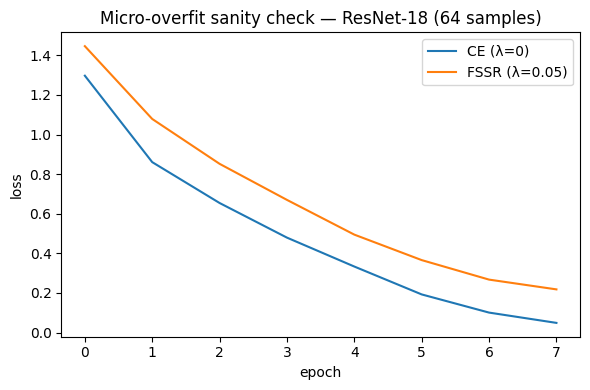


=== STEP 10.5 DONE — ResNet18 ===
=== STEP 11 FEATURE STABILITY ===
CE   : mean=2.4656 | std=2.2925
FSSR : mean=2.1635 | std=1.3770


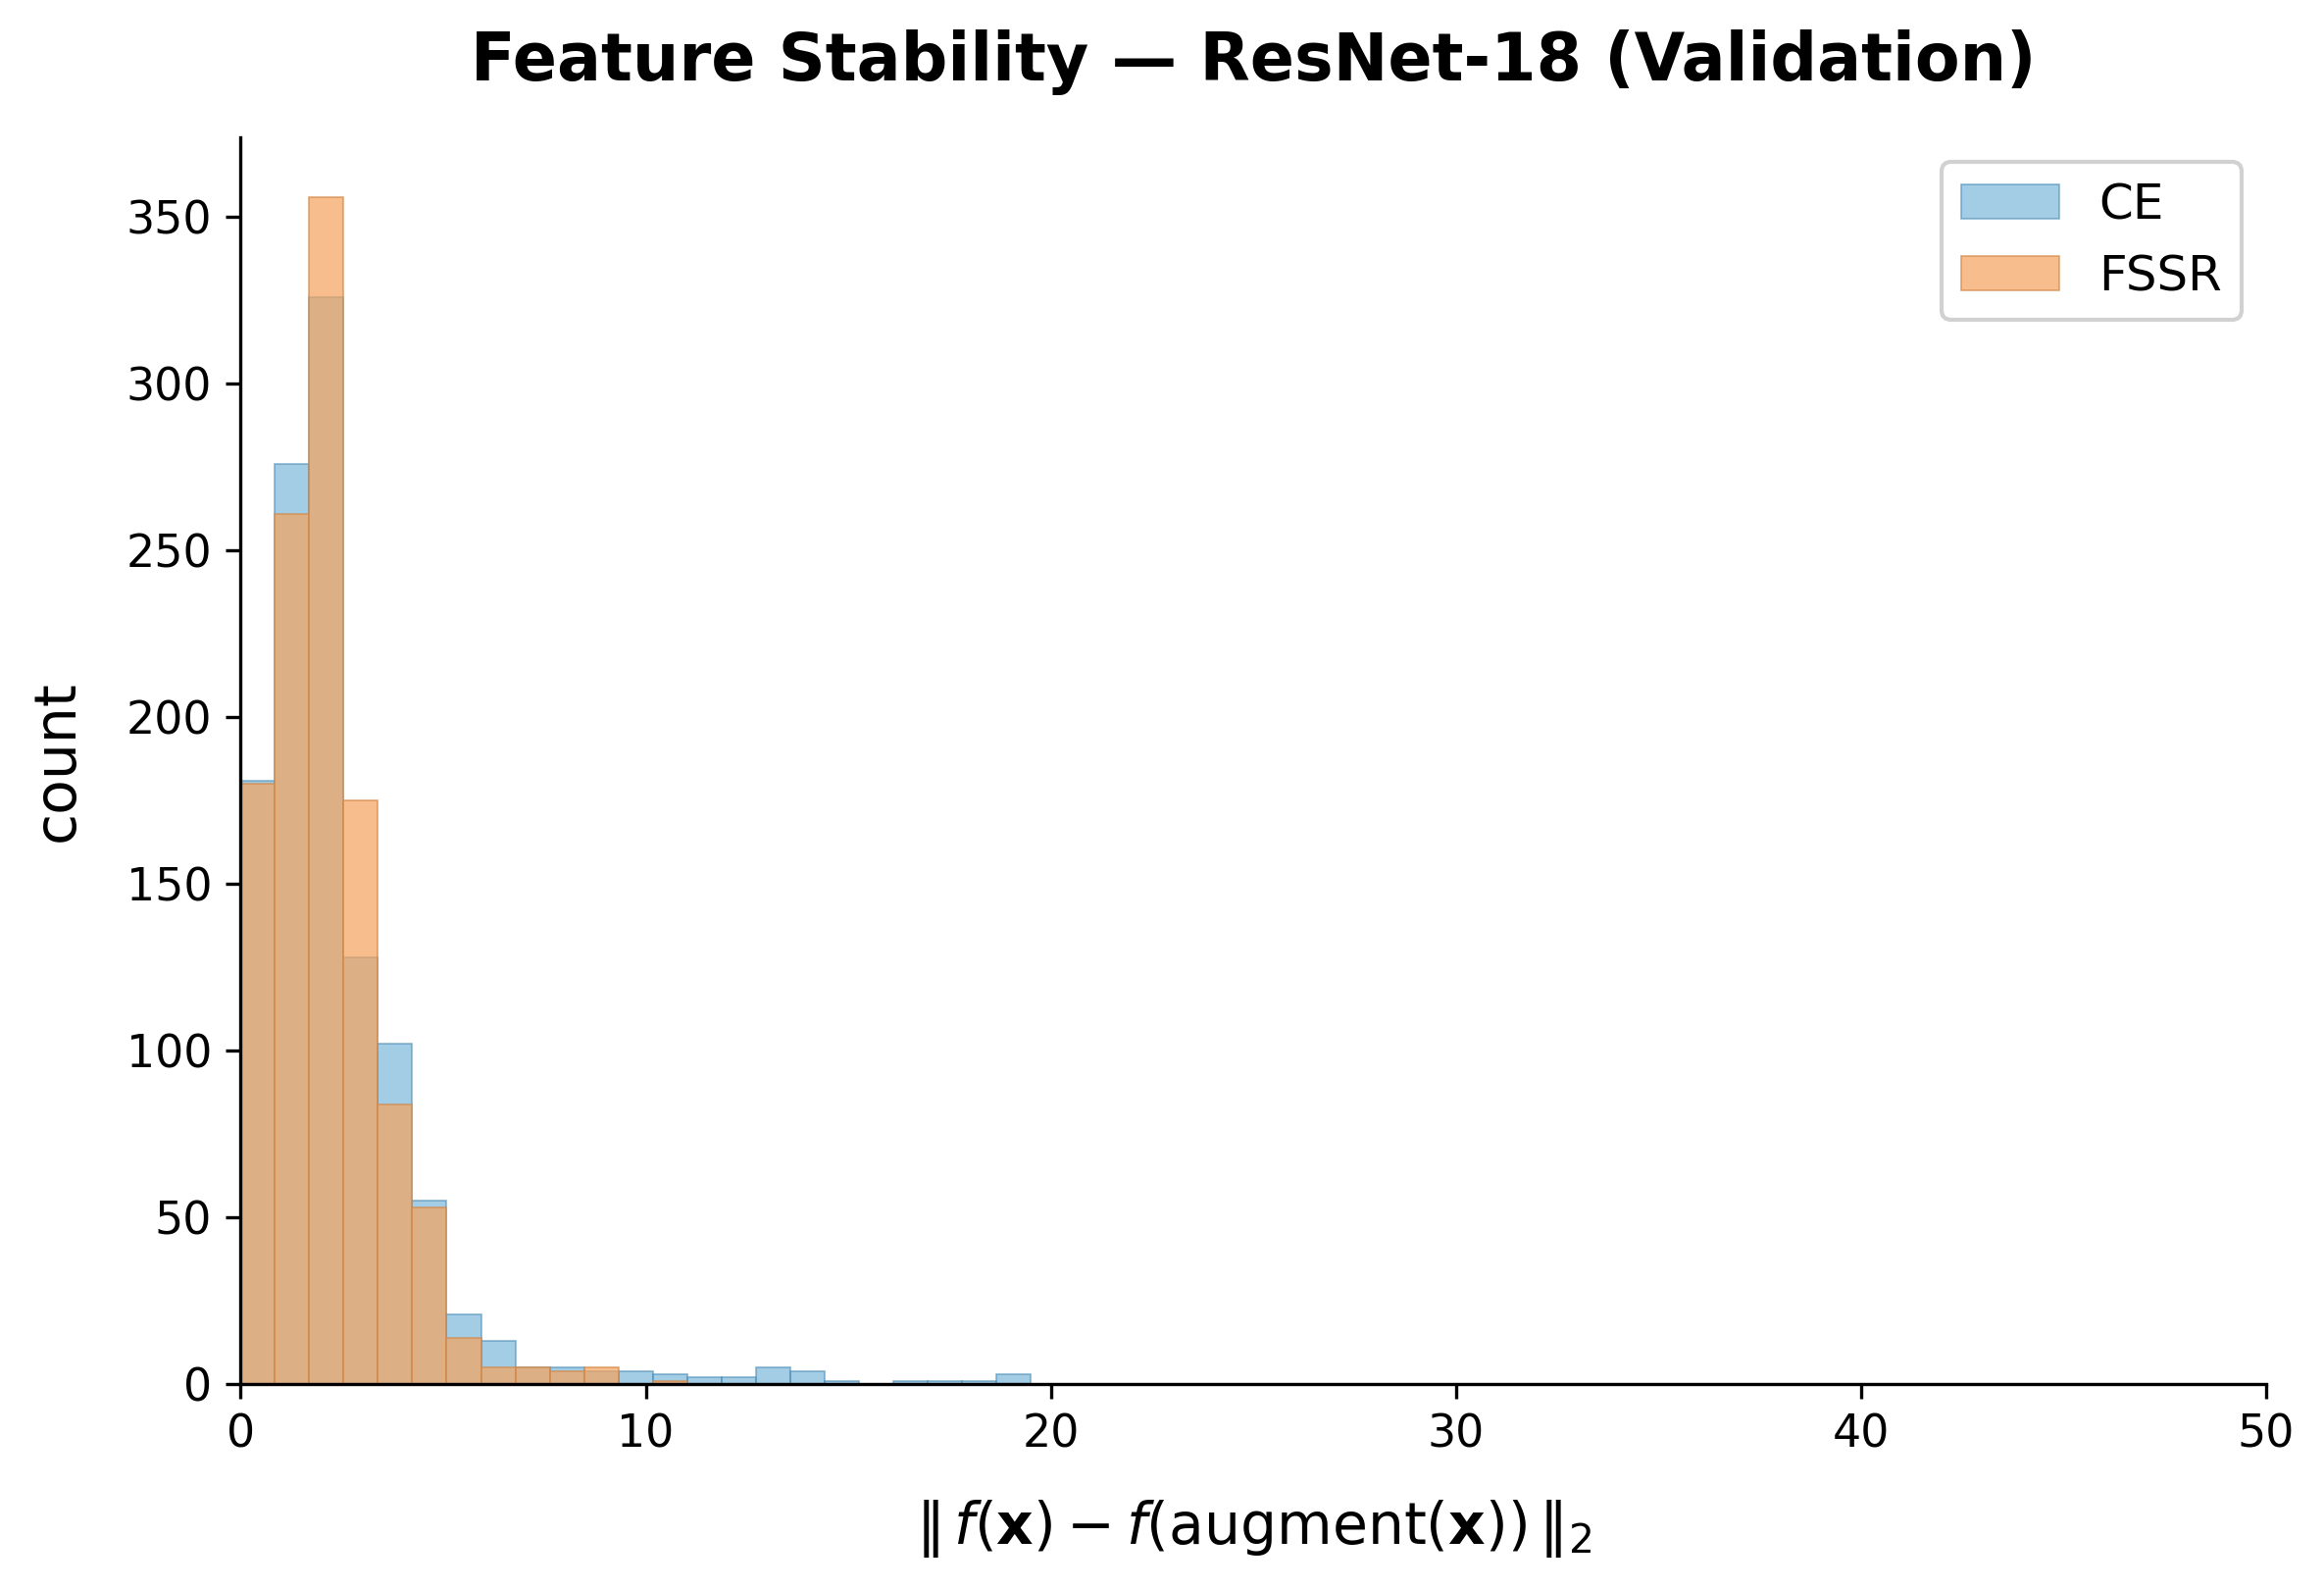

Saved: feature_stability_resnet18.png

=== STEP 11 DONE ===


In [ ]:
# =========================
# STEP 10 — FSSR Loss Implementation + Gradient Flow Verification
# All Backbones
# =========================

import torch
import torch.nn as nn
import numpy as np
import random
import zipfile
import cv2
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from torch.utils.data import Dataset, DataLoader, Subset

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
CE = nn.CrossEntropyLoss()

# -------------------------------------------------
# RE-DEFINE dataset inline (avoids kernel conflicts)
# -------------------------------------------------
ZIP_PATH = "/content/drive/MyDrive/project dataset/kaggle MRI.zip"
SPLIT_DIR = Path("/content/drive/MyDrive/project dataset/outputs_fssr/splits")
TARGET_SIZE = 224

CLASS_TO_IDX = {
    "glioma": 0,
    "meningioma": 1,
    "pituitary": 2,
    "no_tumor": 3
}

train_manifest = pd.read_csv(SPLIT_DIR / "kaggle_train.csv")
val_manifest   = pd.read_csv(SPLIT_DIR / "kaggle_val.csv")

def to_gray(img):
    if img.ndim == 2:
        return img
    if img.ndim == 3 and img.shape[2] == 3:
        return cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    if img.ndim == 3 and img.shape[2] == 4:
        return cv2.cvtColor(img, cv2.COLOR_BGRA2GRAY)
    return img[..., 0]

def resize_only(img, size=224):
    return cv2.resize(img, (size, size), interpolation=cv2.INTER_AREA)

def light_mri_augment(img_f):
    out = img_f.copy()
    out *= np.random.uniform(0.9, 1.1)
    sigma = 0.01 * (np.std(out) + 1e-6)
    out += np.random.normal(0, sigma, out.shape)
    if np.random.rand() < 0.5:
        out = cv2.GaussianBlur(out, (3, 3), sigmaX=0.8)
    return out

class KaggleMRIDataset(Dataset):
    def __init__(self, manifest, zip_path, augment=False):
        self.df = manifest.reset_index(drop=True)
        self.zip_path = zip_path
        self.augment = augment

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        with zipfile.ZipFile(self.zip_path, "r") as z:
            img_bytes = z.read(row["zip_path"])

        arr = np.frombuffer(img_bytes, np.uint8)
        img = cv2.imdecode(arr, cv2.IMREAD_UNCHANGED)
        assert img is not None, row["zip_path"]

        img = to_gray(img).astype(np.float32)

        if self.augment:
            img = light_mri_augment(img)

        img = resize_only(img, TARGET_SIZE)
        img_t = torch.from_numpy(img).unsqueeze(0)  # (1, H, W)
        label = CLASS_TO_IDX[row["label"]]
        return img_t, label

# -------------------------------------------------
# DataLoaders
# -------------------------------------------------
train_loader = DataLoader(
    KaggleMRIDataset(train_manifest, ZIP_PATH, augment=True),
    batch_size=32, shuffle=True, num_workers=2, pin_memory=True
)

val_loader = DataLoader(
    KaggleMRIDataset(val_manifest, ZIP_PATH, augment=False),
    batch_size=32, shuffle=False, num_workers=2, pin_memory=True
)

# -------------------------------------------------
# MODELS (from STEP 9 — must already be in memory)
# -------------------------------------------------
models_to_test = {
    "ResNet18": resnet18,
    "ResNet34": resnet34,
    "DenseNet121": densenet121,
}

# λ grid (LOCKED)
LAMBDAS = [0.0, 0.01, 0.05, 0.1]

# -------------------------------------------------
# Torch-safe augmentation wrapper
# -------------------------------------------------
def augment_batch_light(x_t):
    """
    x_t: torch tensor (B,1,H,W)
    returns augmented tensor same shape
    """
    x_np = x_t.detach().cpu().numpy()
    out = []
    for i in range(x_np.shape[0]):
        img = x_np[i, 0]              # (H,W)
        aug = light_mri_augment(img)
        out.append(aug[None, ...])     # (1,H,W)
    out = np.stack(out, axis=0).astype(np.float32)
    return torch.from_numpy(out).to(x_t.device)

# -------------------------------------------------
# FSSR loss function (shared)
# -------------------------------------------------
def fssr_losses(model, x, y, lam):
    logits, f = model(x, return_features=True)

    x_aug = augment_batch_light(x)
    logits_aug, f_aug = model(x_aug, return_features=True)

    ce = CE(logits, y)
    stab = torch.norm(f - f_aug, p=2, dim=1).mean()
    total = ce + lam * stab
    return ce, stab, total

# -------------------------------------------------
# Get one batch (same batch for all models)
# -------------------------------------------------
x, y = next(iter(train_loader))
x = x.to(DEVICE)
y = y.to(DEVICE)

print("=== STEP 10 VERIFICATION (ALL MODELS) ===")
print("Batch:", tuple(x.shape), "| labels:", torch.unique(y).tolist())
print()

# -------------------------------------------------
# Run gradient check
# -------------------------------------------------
for model_name, model in models_to_test.items():
    model = model.to(DEVICE)
    model.train()

    print(f"\n--- {model_name} ---")

    for lam in LAMBDAS:
        model.zero_grad(set_to_none=True)

        ce, stab, total = fssr_losses(model, x, y, lam)
        total.backward()

        grad_norm = None
        first_grad_name = None
        for name, p in model.named_parameters():
            if p.requires_grad and p.grad is not None:
                grad_norm = float(p.grad.detach().abs().mean().cpu())
                first_grad_name = name
                break

        print(
            f"λ={lam:.2f} | "
            f"CE={float(ce.detach().cpu()):.6f} | "
            f"STAB={float(stab.detach().cpu()):.6f} | "
            f"TOTAL={float(total.detach().cpu()):.6f}"
        )
        print(
            f"   first grad param: {first_grad_name} | "
            f"mean|grad|={grad_norm:.6e}"
        )

print("\n=== STEP 10 DONE ===")


# ============================================================
# STEP 10.5 — Micro-Overfit Sanity Check (ResNet18, FINAL)
# λ = 0.05
# ============================================================

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

MICRO_N = 64
BATCH_SIZE = 32
EPOCHS = 8
LR = 1e-4
LAMBDA = 0.05

print("\nDevice:", DEVICE)
print("λ =", LAMBDA)

# -------------------------
# MICRO DATASET (64 samples)
# -------------------------
rng = np.random.RandomState(SEED)
micro_idx = rng.choice(len(train_manifest), size=MICRO_N, replace=False)

micro_ds = Subset(
    KaggleMRIDataset(train_manifest, ZIP_PATH, augment=False),
    micro_idx
)

micro_loader = DataLoader(
    micro_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

# -------------------------
# TRAINING LOOP
# -------------------------
def train_micro(model, lam):
    model = model.to(DEVICE)
    model.train()
    opt = torch.optim.AdamW(model.parameters(), lr=LR)

    losses, accs = [], []

    for ep in range(1, EPOCHS + 1):
        correct, total, running_loss = 0, 0, 0.0

        for x, y in micro_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            opt.zero_grad(set_to_none=True)

            logits, f = model(x, return_features=True)

            if lam > 0:
                x_aug = augment_batch_light(x)
                _, f_aug = model(x_aug, return_features=True)
                stab = torch.norm(f - f_aug, p=2, dim=1).mean()
                loss = CE(logits, y) + lam * stab
            else:
                loss = CE(logits, y)

            loss.backward()
            opt.step()

            running_loss += loss.item() * x.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

        epoch_loss = running_loss / total
        epoch_acc = correct / total

        losses.append(epoch_loss)
        accs.append(epoch_acc)

        print(
            f"Epoch {ep:02d} | "
            f"loss={epoch_loss:.4f} | "
            f"acc={epoch_acc*100:.2f}%"
        )

    return losses, accs

# -------------------------
# RUN CE vs FSSR
# -------------------------
print("\n=== RUNNING MICRO-OVERFIT ===")

print("\n--- CE only (λ=0) ---")
model_ce = ResNet18_FSSR(4)
loss_ce, acc_ce = train_micro(model_ce, lam=0.0)

print(f"\n--- FSSR (λ={LAMBDA}) ---")
model_fssr = ResNet18_FSSR(4)
loss_fs, acc_fs = train_micro(model_fssr, lam=LAMBDA)

# -------------------------
# PLOT
# -------------------------
plt.figure(figsize=(6, 4))
plt.plot(loss_ce, label="CE (λ=0)")
plt.plot(loss_fs, label=f"FSSR (λ={LAMBDA})")
plt.title("Micro-overfit sanity check — ResNet-18 (64 samples)")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.tight_layout()
plt.show()

print("\n=== STEP 10.5 DONE — ResNet18 ===")


# =========================
# STEP 11 — Feature Stability Measurement (ResNet-18)
# =========================

# -------------------------
# Validation loader (NO augmentation)
# -------------------------
val_ds_eval = KaggleMRIDataset(val_manifest, ZIP_PATH, augment=False)

val_loader_eval = DataLoader(
    val_ds_eval,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

# -------------------------
# Feature distance collector
# -------------------------
@torch.no_grad()
def collect_feature_distances(model):
    model.eval()
    dists = []

    for x, _ in val_loader_eval:
        x = x.to(DEVICE)

        _, f = model(x, return_features=True)

        x_aug = augment_batch_light(x)
        _, f_aug = model(x_aug, return_features=True)

        dist = torch.norm(f - f_aug, p=2, dim=1)
        dists.append(dist.cpu().numpy())

    return np.concatenate(dists)

# -------------------------
# Use models from STEP 10.5
# -------------------------
ce_model   = model_ce.to(DEVICE).eval()
fssr_model = model_fssr.to(DEVICE).eval()

# -------------------------
# Collect distances
# -------------------------
d_ce = collect_feature_distances(ce_model)
d_fs = collect_feature_distances(fssr_model)

print("=== STEP 11 FEATURE STABILITY ===")
print(f"CE   : mean={d_ce.mean():.4f} | std={d_ce.std():.4f}")
print(f"FSSR : mean={d_fs.mean():.4f} | std={d_fs.std():.4f}")

# -------------------------
# Plot (HD)
# -------------------------
fig, ax = plt.subplots(figsize=(8, 5.5), dpi=300)
bins = np.linspace(0, 50, 60)

ax.hist(d_ce, bins=bins, alpha=0.62, label='CE', color='#6BAED6',
        edgecolor='#4A8BB5', linewidth=0.4)
ax.hist(d_fs, bins=bins, alpha=0.72, label='FSSR', color='#F4A460',
        edgecolor='#D2884A', linewidth=0.4)

ax.set_xlabel(
    r'$\| \, f(\mathbf{x}) - f(\mathrm{augment}(\mathbf{x})) \, \|_2$',
    fontsize=14, labelpad=10
)
ax.set_ylabel('count', fontsize=14, labelpad=10)
ax.set_title(
    'Feature Stability — ResNet-18 (Validation)',
    fontsize=16, fontweight='bold', pad=14
)
ax.legend(fontsize=12, framealpha=0.9, edgecolor='#cccccc', loc='upper right')
ax.set_xlim(0, 50)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', labelsize=11)

fig.tight_layout()
fig.savefig(
    "feature_stability_resnet18.png",
    dpi=300, bbox_inches='tight', facecolor='white'
)
plt.show()

print("Saved: feature_stability_resnet18.png")
print("\n=== STEP 11 DONE ===")

In [ ]:
# ============================================================
# FIX — ResNet34 FSSR λ Calibration (FULL, CLEAN SCRIPT)
# ============================================================

import torch
import torch.nn as nn
import numpy as np
import random
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Subset

# -------------------------
# GLOBAL CONFIG
# -------------------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

CE = nn.CrossEntropyLoss()

# -------------------------
# λ candidates (ResNet34-safe)
# -------------------------
LAMBDAS = [0.0, 0.005, 0.01, 0.02]

EPOCHS = 4
LR = 1e-4
BATCH_SIZE = 32
MICRO_N = 64

print("Device:", DEVICE)
print("Lambdas:", LAMBDAS)

# -------------------------
# MICRO DATASET (64 samples)
# -------------------------
rng = np.random.RandomState(SEED)
micro_idx = rng.choice(len(train_manifest), size=MICRO_N, replace=False)

base_ds = KaggleMRIDataset(
    train_manifest,
    ZIP_PATH,
    augment=False
)

micro_ds = Subset(base_ds, micro_idx)

micro_loader = DataLoader(
    micro_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

# -------------------------
# FEATURE STABILITY COLLECTOR
# -------------------------
@torch.no_grad()
def collect_feature_distances(model):
    model.eval()
    dists = []

    for x, _ in micro_loader:
        x = x.to(DEVICE)

        _, f = model(x, return_features=True)
        x_aug = augment_batch_light(x)
        _, f_aug = model(x_aug, return_features=True)

        dist = torch.norm(f - f_aug, p=2, dim=1)
        dists.append(dist.cpu().numpy())

    return np.concatenate(dists)

# -------------------------
# TRAIN + MEASURE
# -------------------------
results = {}

for lam in LAMBDAS:
    print("\n" + "="*60)
    print(f"ResNet34 | λ = {lam}")
    print("="*60)

    model = ResNet34_FSSR(4).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=LR)

    # -------- TRAIN --------
    model.train()
    for ep in range(1, EPOCHS + 1):
        running = 0.0
        for x, y in micro_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            opt.zero_grad(set_to_none=True)

            logits, f = model(x, return_features=True)

            if lam > 0:
                x_aug = augment_batch_light(x)
                _, f_aug = model(x_aug, return_features=True)
                stab = torch.norm(f - f_aug, p=2, dim=1).mean()
                loss = CE(logits, y) + lam * stab
            else:
                loss = CE(logits, y)

            loss.backward()
            opt.step()
            running += loss.item()

        print(f"Epoch {ep}/{EPOCHS} | loss={running/len(micro_loader):.4f}")

    # -------- STABILITY --------
    d = collect_feature_distances(model)
    results[lam] = d

    print(
        f"λ={lam:<6} | "
        f"mean={d.mean():.4f} | "
        f"std={d.std():.4f}"
    )

# -------------------------
# SUMMARY TABLE
# -------------------------
print("\n=== SUMMARY (ResNet34) ===")
print("λ\tmean\tstd")
for lam in LAMBDAS:
    d = results[lam]
    print(f"{lam:.3f}\t{d.mean():.4f}\t{d.std():.4f}")

# -------------------------
# OPTIONAL: HISTOGRAM PLOT
# -------------------------
plt.figure(figsize=(7,4))
for lam in LAMBDAS:
    plt.hist(
        results[lam],
        bins=40,
        alpha=0.5,
        label=f"λ={lam}"
    )

plt.xlabel("|| f(x) − f(augment(x)) ||₂")
plt.ylabel("count")
plt.title("Feature Stability — ResNet34 (λ sweep)")
plt.legend()
plt.tight_layout()
plt.show()

print("\n=== FIX COMPLETE — RESNET34 FSSR λ CALIBRATION ===")


In [ ]:
# ============================================================
# RE-RENDER Feature Stability Figure — MDPI Quality
# Requires: d_ce, d_fs already in memory from Step 11
# NO retraining needed
# ============================================================

import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

# ---- Check data exists ----
assert 'd_ce' in dir() or 'd_ce' in globals(), \
    "d_ce not found! Re-run only the collect_feature_distances() cell first."

# ---- MDPI settings ----
DPI = 300
WIDTH_INCHES = 8        # 8 × 300 = 2400 px (MDPI needs ≥600)
HEIGHT_INCHES = 5.5

# ---- Plot ----
fig, ax = plt.subplots(figsize=(WIDTH_INCHES, HEIGHT_INCHES), dpi=DPI)

bins = np.linspace(0, max(d_ce.max(), d_fs.max()) * 1.05, 60)

ax.hist(d_ce, bins=bins, alpha=0.62, label='CE (Baseline)',
        color='#6BAED6', edgecolor='#4A8BB5', linewidth=0.5)
ax.hist(d_fs, bins=bins, alpha=0.72, label='FSSR',
        color='#F4A460', edgecolor='#D2884A', linewidth=0.5)

ax.set_xlabel(
    r'$\| f(\mathbf{x}) - f(\mathrm{aug}(\mathbf{x})) \|_2$',
    fontsize=14, labelpad=10
)
ax.set_ylabel('Count', fontsize=14, labelpad=10)
ax.set_title(
    'Feature Stability Distribution (Validation Set)',
    fontsize=16, fontweight='bold', pad=16       # pad=16 prevents top clipping
)
ax.legend(fontsize=12, framealpha=0.9, edgecolor='#cccccc', loc='upper right')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', labelsize=11)

fig.tight_layout()

# ---- Save JPG (MDPI required format) ----
fig.savefig(
    "figure10_feature_stability.jpg",
    dpi=DPI,
    bbox_inches="tight",       # prevents ANY clipping
    facecolor="white",
    format="jpg"
)

# ---- Also save PNG (backup) ----
fig.savefig(
    "figure10_feature_stability.png",
    dpi=DPI,
    bbox_inches="tight",
    facecolor="white",
    format="png"
)

plt.close(fig)

# ---- Verify dimensions ----
from PIL import Image
for f in ["figure10_feature_stability.jpg", "figure10_feature_stability.png"]:
    im = Image.open(f)
    print(f"{f}: {im.size[0]}×{im.size[1]} px | DPI={im.info.get('dpi', 'N/A')}")

print("\n✅ Done — upload figure10_feature_stability.jpg to MDPI")

figure10_feature_stability.jpg: 2370×1620 px | DPI=(300, 300)
figure10_feature_stability.png: 2370×1620 px | DPI=(299.9994, 299.9994)

✅ Done — upload figure10_feature_stability.jpg to MDPI


In [ ]:
# ============================================================
# FIX — ResNet18 FSSR λ Calibration (FULL, CLEAN SCRIPT)
# ============================================================

import torch
import torch.nn as nn
import numpy as np
import random
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Subset

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

CE = nn.CrossEntropyLoss()

# -------------------------
# λ candidates (ResNet18-safe)
# -------------------------
LAMBDAS = [0.0, 0.01, 0.03, 0.05]

EPOCHS = 4
LR = 1e-4
BATCH_SIZE = 32
MICRO_N = 64

print("Device:", DEVICE)
print("ResNet18 Lambdas:", LAMBDAS)

# -------------------------
# MICRO DATASET
# -------------------------
rng = np.random.RandomState(SEED)
micro_idx = rng.choice(len(train_manifest), size=MICRO_N, replace=False)

base_ds = KaggleMRIDataset(train_manifest, ZIP_PATH, augment=False)
micro_ds = Subset(base_ds, micro_idx)

micro_loader = DataLoader(
    micro_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

# -------------------------
# FEATURE STABILITY
# -------------------------
@torch.no_grad()
def collect_feature_distances(model):
    model.eval()
    dists = []
    for x, _ in micro_loader:
        x = x.to(DEVICE)
        _, f = model(x, return_features=True)
        x_aug = augment_batch_light(x)
        _, f_aug = model(x_aug, return_features=True)
        dists.append(torch.norm(f - f_aug, p=2, dim=1).cpu().numpy())
    return np.concatenate(dists)

# -------------------------
# TRAIN + MEASURE
# -------------------------
results = {}

for lam in LAMBDAS:
    print("\n" + "="*60)
    print(f"ResNet18 | λ = {lam}")
    print("="*60)

    model = ResNet18_FSSR(4).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=LR)

    model.train()
    for ep in range(1, EPOCHS + 1):
        running = 0.0
        for x, y in micro_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            opt.zero_grad(set_to_none=True)

            logits, f = model(x, return_features=True)
            if lam > 0:
                x_aug = augment_batch_light(x)
                _, f_aug = model(x_aug, return_features=True)
                stab = torch.norm(f - f_aug, p=2, dim=1).mean()
                loss = CE(logits, y) + lam * stab
            else:
                loss = CE(logits, y)

            loss.backward()
            opt.step()
            running += loss.item()

        print(f"Epoch {ep}/{EPOCHS} | loss={running/len(micro_loader):.4f}")

    d = collect_feature_distances(model)
    results[lam] = d
    print(f"λ={lam:<6} | mean={d.mean():.4f} | std={d.std():.4f}")

# -------------------------
# SUMMARY
# -------------------------
print("\n=== SUMMARY (ResNet18) ===")
print("λ\tmean\tstd")
for lam in LAMBDAS:
    d = results[lam]
    print(f"{lam:.3f}\t{d.mean():.4f}\t{d.std():.4f}")

plt.figure(figsize=(7,4))
for lam in LAMBDAS:
    plt.hist(results[lam], bins=40, alpha=0.5, label=f"λ={lam}")
plt.xlabel("|| f(x) − f(aug(x)) ||₂")
plt.ylabel("count")
plt.title("Feature Stability — ResNet18 (λ sweep)")
plt.legend()
plt.tight_layout()
plt.show()

print("\n=== FIX COMPLETE — RESNET18 ===")


In [ ]:
# ============================================================
# FIX — DenseNet121 FSSR λ Calibration (FULL, CLEAN SCRIPT)
# ============================================================

import torch
import torch.nn as nn
import numpy as np
import random
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Subset

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

CE = nn.CrossEntropyLoss()

# -------------------------
# λ candidates (DenseNet-safe)
# -------------------------
LAMBDAS = [0.0, 0.002, 0.005, 0.01]

EPOCHS = 4
LR = 1e-4
BATCH_SIZE = 32
MICRO_N = 64

print("Device:", DEVICE)
print("DenseNet121 Lambdas:", LAMBDAS)

# -------------------------
# MICRO DATASET
# -------------------------
rng = np.random.RandomState(SEED)
micro_idx = rng.choice(len(train_manifest), size=MICRO_N, replace=False)

base_ds = KaggleMRIDataset(train_manifest, ZIP_PATH, augment=False)
micro_ds = Subset(base_ds, micro_idx)

micro_loader = DataLoader(
    micro_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

# -------------------------
# FEATURE STABILITY
# -------------------------
@torch.no_grad()
def collect_feature_distances(model):
    model.eval()
    dists = []
    for x, _ in micro_loader:
        x = x.to(DEVICE)
        _, f = model(x, return_features=True)
        x_aug = augment_batch_light(x)
        _, f_aug = model(x_aug, return_features=True)
        dists.append(torch.norm(f - f_aug, p=2, dim=1).cpu().numpy())
    return np.concatenate(dists)

# -------------------------
# TRAIN + MEASURE
# -------------------------
results = {}

for lam in LAMBDAS:
    print("\n" + "="*60)
    print(f"DenseNet121 | λ = {lam}")
    print("="*60)

    model = DenseNet121_FSSR(4).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=LR)

    model.train()
    for ep in range(1, EPOCHS + 1):
        running = 0.0
        for x, y in micro_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            opt.zero_grad(set_to_none=True)

            logits, f = model(x, return_features=True)
            if lam > 0:
                x_aug = augment_batch_light(x)
                _, f_aug = model(x_aug, return_features=True)
                stab = torch.norm(f - f_aug, p=2, dim=1).mean()
                loss = CE(logits, y) + lam * stab
            else:
                loss = CE(logits, y)

            loss.backward()
            opt.step()
            running += loss.item()

        print(f"Epoch {ep}/{EPOCHS} | loss={running/len(micro_loader):.4f}")

    d = collect_feature_distances(model)
    results[lam] = d
    print(f"λ={lam:<6} | mean={d.mean():.4f} | std={d.std():.4f}")

# -------------------------
# SUMMARY
# -------------------------
print("\n=== SUMMARY (DenseNet121) ===")
print("λ\tmean\tstd")
for lam in LAMBDAS:
    d = results[lam]
    print(f"{lam:.3f}\t{d.mean():.4f}\t{d.std():.4f}")

plt.figure(figsize=(7,4))
for lam in LAMBDAS:
    plt.hist(results[lam], bins=40, alpha=0.5, label=f"λ={lam}")
plt.xlabel("|| f(x) − f(aug(x)) ||₂")
plt.ylabel("count")
plt.title("Feature Stability — DenseNet121 (λ sweep)")
plt.legend()
plt.tight_layout()
plt.show()

print("\n=== FIX COMPLETE — DENSENET121 ===")


In [ ]:
# =========================
# STEP 11 — Feature Stability Measurement (CE vs FSSR)
# ResNet34
# =========================

import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# -------------------------
# Validation loader (NO augmentation)
# -------------------------
val_ds_eval = KaggleMRIDataset(
    val_manifest,
    ZIP_PATH,
    augment=False
)

val_loader_eval = DataLoader(
    val_ds_eval,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

# -------------------------
# Feature distance collector
# -------------------------
@torch.no_grad()
def collect_feature_distances(model):
    model.eval()
    dists = []

    for x, _ in val_loader_eval:
        x = x.to(DEVICE)

        # original features
        _, f = model(x, return_features=True)

        # augmented features (same augmentation used in training)
        x_aug = augment_batch_light(x)
        _, f_aug = model(x_aug, return_features=True)

        # L2 distance per sample
        dist = torch.norm(f - f_aug, p=2, dim=1)
        dists.append(dist.cpu().numpy())

    return np.concatenate(dists, axis=0)

# ======================================================
# 🔒 USE THE MODELS YOU JUST TRAINED (ResNet34)
# ======================================================
ce_model   = m_ce.to(DEVICE).eval()
fssr_model = m_fssr.to(DEVICE).eval()

# -------------------------
# Collect distances
# -------------------------
d_ce = collect_feature_distances(ce_model)
d_fs = collect_feature_distances(fssr_model)

# -------------------------
# Report numbers
# -------------------------
print("=== STEP 11 — FEATURE STABILITY (ResNet34) ===")
print(f"CE   : mean={d_ce.mean():.4f} | std={d_ce.std():.4f}")
print(f"FSSR : mean={d_fs.mean():.4f} | std={d_fs.std():.4f}")

# -------------------------
# Plot distributions
# -------------------------
plt.figure(figsize=(6,4))
plt.hist(d_ce, bins=40, alpha=0.6, label="CE ")
plt.hist(d_fs, bins=40, alpha=0.6, label="FSSR")
plt.xlabel("|| f(x) − f(augment(x)) ||₂")
plt.ylabel("count")
plt.title("Feature Stability — ResNet34 (Validation)")
plt.legend()
plt.tight_layout()
plt.show()

print("\n=== STEP 11 DONE (ResNet34) ===")


In [ ]:
# =========================
# STEP 11 — Feature Stability Measurement (CE vs FSSR)
# DenseNet121
# =========================

import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# -------------------------
# Validation loader (NO augmentation)
# -------------------------
val_ds_eval = KaggleMRIDataset(
    val_manifest,
    ZIP_PATH,
    augment=False
)

val_loader_eval = DataLoader(
    val_ds_eval,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

# -------------------------
# Feature distance collector
# -------------------------
@torch.no_grad()
def collect_feature_distances(model):
    model.eval()
    dists = []

    for x, _ in val_loader_eval:
        x = x.to(DEVICE)

        # original features
        _, f = model(x, return_features=True)

        # augmented features (same augmentation used in training)
        x_aug = augment_batch_light(x)
        _, f_aug = model(x_aug, return_features=True)

        # L2 distance per sample
        dist = torch.norm(f - f_aug, p=2, dim=1)
        dists.append(dist.cpu().numpy())

    return np.concatenate(dists, axis=0)

# ======================================================
# 🔒 USE THE MODELS YOU JUST TRAINED (DenseNet121)
# ======================================================
# These must already exist from STEP 10.5
#   m_ce121   : DenseNet121_FSSR trained with λ=0
#   m_fssr121 : DenseNet121_FSSR trained with λ=0.002

ce_model   = m_ce.to(DEVICE).eval()
fssr_model = m_fssr.to(DEVICE).eval()

# -------------------------
# Collect distances
# -------------------------
d_ce = collect_feature_distances(ce_model)
d_fs = collect_feature_distances(fssr_model)

# -------------------------
# Report numbers
# -------------------------
print("=== STEP 11 — FEATURE STABILITY (DenseNet121) ===")
print(f"CE   : mean={d_ce.mean():.4f} | std={d_ce.std():.4f}")
print(f"FSSR : mean={d_fs.mean():.4f} | std={d_fs.std():.4f}")

# -------------------------
# Plot distributions
# -------------------------
plt.figure(figsize=(6,4))
plt.hist(d_ce, bins=40, alpha=0.6, label="CE")
plt.hist(d_fs, bins=40, alpha=0.6, label="FSSR")
plt.xlabel("|| f(x) − f(augment(x)) ||₂")
plt.ylabel("count")
plt.title("Feature Stability — DenseNet121 (Validation)")
plt.legend()
plt.tight_layout()
plt.show()

print("\n=== STEP 11 DONE (DenseNet121) ===")


NameError: name 'm_ce' is not defined

In [ ]:
# ============================================================
# STEP 12 — Multi-Backbone Kaggle CV with Epoch Logs
# ResNet18, ResNet34, DenseNet121 + FSSR Variants
# ============================================================

import time
import random
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, accuracy_score

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from tqdm import tqdm

# ============================================================
# GLOBAL CONFIG
# ============================================================
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

# Paths (LOCAL)
LOCAL_DIR = Path("/content/kaggle_mri_local")
TRAIN_DIR = LOCAL_DIR / "Training"
TEST_DIR = LOCAL_DIR / "Testing"

# Training config
BACKBONES = ["resnet18", "resnet34", "densenet121"]
VARIANTS = ["CE_only", "CE_plus_aug", "CE_plus_FSSR"]
N_FOLDS = 3
BATCH_SIZE = 32
LR = 1e-4
MAX_EPOCHS = 8
PATIENCE = 3
LAM_FSSR = 0.05

CE = nn.CrossEntropyLoss()

print("=" * 70)
print("STEP 12 — MULTI-BACKBONE KAGGLE CV")
print("=" * 70)
print(f"Device: {DEVICE}")
print(f"Local directory: {LOCAL_DIR}")
print(f"Backbones: {BACKBONES}")
print(f"Variants: {VARIANTS}")
print(f"CV Folds: {N_FOLDS}")
print(f"Max Epochs: {MAX_EPOCHS} (patience={PATIENCE})")
print(f"λ_FSSR: {LAM_FSSR}")
print()

# ============================================================
# DATA LOADING
# ============================================================
from PIL import Image
import torchvision.transforms as T

# Fixed transform (STEP 8 semantics)
base_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
])

class KaggleMRIDataset(torch.utils.data.Dataset):
    """Load local Kaggle MRI dataset without augmentation."""
    def __init__(self, manifest, transform=None):
        self.manifest = manifest.reset_index(drop=True)
        self.transform = transform if transform else base_transform

    def __len__(self):
        return len(self.manifest)

    def __getitem__(self, idx):
        row = self.manifest.iloc[idx]
        img_path = row["path"]
        label = row["label_idx"]

        # Load image
        img = Image.open(img_path).convert("L")  # grayscale
        img = self.transform(img)

        return img, label

# Build manifest from local directory
def build_manifest(data_dir):
    """Scan directory and build DataFrame manifest."""
    records = []
    class_names = sorted([d.name for d in data_dir.iterdir() if d.is_dir()])

    for class_idx, class_name in enumerate(class_names):
        class_dir = data_dir / class_name
        for img_path in class_dir.glob("*.jpg"):
            records.append({
                "path": str(img_path),
                "class_name": class_name,
                "label_idx": class_idx
            })

    return pd.DataFrame(records), class_names

# Load training data
print("Loading training manifest...")
train_manifest, class_names = build_manifest(TRAIN_DIR)
NUM_CLASSES = len(class_names)

print(f"Found {len(train_manifest)} training images")
print(f"Classes ({NUM_CLASSES}): {class_names}")
print(f"Class distribution:")
print(train_manifest["class_name"].value_counts().sort_index())
print()

# ============================================================
# AUGMENTATION
# ============================================================
def torch_light_aug(x):
    """
    Light MRI-specific augmentation.

    Args:
        x: [B, 1, H, W] tensor

    Returns:
        Augmented tensor with same shape
    """
    out = x.clone()

    # Intensity scaling (±10%)
    scales = 0.9 + 0.2 * torch.rand((out.size(0), 1, 1, 1), device=out.device)
    out = out * scales

    # Gaussian noise (1% of std)
    std = out.flatten(1).std(dim=1).view(-1, 1, 1, 1) + 1e-6
    out = out + torch.randn_like(out) * (0.01 * std)

    # Mild blur (50% chance)
    if torch.rand(1).item() < 0.5:
        out = F.avg_pool2d(out, kernel_size=3, stride=1, padding=1)

    return out

# ============================================================
# MODEL BUILDER
# ============================================================
def build_model(backbone_name, num_classes=4):
    """
    Build model with feature extraction support.

    Args:
        backbone_name: "resnet18", "resnet34", or "densenet121"
        num_classes: Number of output classes

    Returns:
        Model with forward(x, return_features=False) interface
    """
    import torchvision.models as models

    if backbone_name == "resnet18":
        base = models.resnet18(weights=None)
        feat_dim = base.fc.in_features
        base.fc = nn.Identity()

    elif backbone_name == "resnet34":
        base = models.resnet34(weights=None)
        feat_dim = base.fc.in_features
        base.fc = nn.Identity()

    elif backbone_name == "densenet121":
        base = models.densenet121(weights=None)
        feat_dim = base.classifier.in_features
        base.classifier = nn.Identity()

    else:
        raise ValueError(f"Unknown backbone: {backbone_name}")

    # Modify first conv for grayscale input
    if hasattr(base, 'conv1'):
        # ResNet
        old_conv = base.conv1
        base.conv1 = nn.Conv2d(
            1, old_conv.out_channels,
            kernel_size=old_conv.kernel_size,
            stride=old_conv.stride,
            padding=old_conv.padding,
            bias=False
        )
    elif hasattr(base, 'features') and hasattr(base.features, 'conv0'):
        # DenseNet
        old_conv = base.features.conv0
        base.features.conv0 = nn.Conv2d(
            1, old_conv.out_channels,
            kernel_size=old_conv.kernel_size,
            stride=old_conv.stride,
            padding=old_conv.padding,
            bias=False
        )

    # Wrapper class for feature extraction
    class ModelWithFeatures(nn.Module):
        def __init__(self, backbone, feat_dim, num_classes):
            super().__init__()
            self.backbone = backbone
            self.classifier = nn.Linear(feat_dim, num_classes)

        def forward(self, x, return_features=False):
            features = self.backbone(x)
            logits = self.classifier(features)

            if return_features:
                return logits, features
            return logits

    return ModelWithFeatures(base, feat_dim, num_classes)

# ============================================================
# TRAINING FUNCTION
# ============================================================
def run_variant(train_idx, val_idx, fold_id, backbone_name, variant_name, base_ds, labels):
    """
    Train one variant on one fold.

    Args:
        train_idx: Training indices
        val_idx: Validation indices
        fold_id: Fold number (1-indexed)
        backbone_name: Model architecture
        variant_name: Training variant (CE_only, CE_plus_aug, CE_plus_FSSR)
        base_ds: Base dataset
        labels: All labels for validation

    Returns:
        Dictionary with results
    """
    use_aug = (variant_name != "CE_only")
    use_fssr = (variant_name == "CE_plus_FSSR")

    # Build model
    model = build_model(backbone_name, NUM_CLASSES).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR)

    # Data loaders
    train_loader = DataLoader(
        Subset(base_ds, train_idx),
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=2,
        pin_memory=True
    )

    val_loader = DataLoader(
        Subset(base_ds, val_idx),
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )

    best_f1 = -1.0
    best_acc = -1.0
    bad_epochs = 0
    epoch_logs = []

    for epoch in range(1, MAX_EPOCHS + 1):
        epoch_start = time.time()

        # ========== TRAINING ==========
        model.train()
        running_loss = 0.0
        train_correct = 0
        train_total = 0

        pbar = tqdm(train_loader, desc=f"  Epoch {epoch}/{MAX_EPOCHS}", leave=False)
        for x, y in pbar:
            x = x.to(DEVICE)
            y = y.to(DEVICE)

            optimizer.zero_grad(set_to_none=True)

            # Apply augmentation if needed
            if use_aug:
                x_aug = torch_light_aug(x)
            else:
                x_aug = x

            logits, f = model(x, return_features=True)

            # Compute loss
            if use_fssr:
                _, f_aug = model(x_aug, return_features=True)

                # Handle feature dimensions
                if f.dim() == 4:
                    f = f.mean(dim=[2, 3])
                    f_aug = f_aug.mean(dim=[2, 3])

                stab = torch.norm(f - f_aug, p=2, dim=1).mean()
                loss = CE(logits, y) + LAM_FSSR * stab
            else:
                loss = CE(logits, y)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * x.size(0)
            preds = logits.argmax(dim=1)
            train_correct += (preds == y).sum().item()
            train_total += y.size(0)

            pbar.set_postfix(loss=f"{loss.item():.4f}")

        avg_train_loss = running_loss / train_total
        train_acc = train_correct / train_total

        # ========== VALIDATION ==========
        model.eval()
        y_true, y_pred = [], []
        val_loss = 0.0

        with torch.no_grad():
            for x, y in val_loader:
                x = x.to(DEVICE)
                y_batch = y.to(DEVICE)

                logits = model(x)
                loss = CE(logits, y_batch)
                val_loss += loss.item() * x.size(0)

                preds = logits.argmax(dim=1).cpu().numpy()
                y_pred.extend(preds.tolist())
                y_true.extend(y.numpy().tolist())

        avg_val_loss = val_loss / len(y_true)
        val_acc = accuracy_score(y_true, y_pred)
        val_f1 = f1_score(y_true, y_pred, average="macro")

        epoch_time = time.time() - epoch_start

        # Log epoch
        epoch_logs.append({
            "epoch": epoch,
            "train_loss": avg_train_loss,
            "train_acc": train_acc,
            "val_loss": avg_val_loss,
            "val_acc": val_acc,
            "val_f1": val_f1,
            "time": epoch_time
        })

        print(
            f"  Epoch {epoch:02d} | "
            f"train_loss={avg_train_loss:.4f} train_acc={train_acc:.3f} | "
            f"val_loss={avg_val_loss:.4f} val_acc={val_acc:.3f} val_f1={val_f1:.4f} | "
            f"time={epoch_time:.1f}s"
        )

        # ========== EARLY STOPPING ==========
        if val_f1 > best_f1 + 1e-6:
            best_f1 = val_f1
            best_acc = val_acc
            bad_epochs = 0
        else:
            bad_epochs += 1
            if bad_epochs >= PATIENCE:
                print(f"  Early stopping triggered at epoch {epoch}")
                break

    return {
        "fold": fold_id,
        "backbone": backbone_name,
        "variant": variant_name,
        "best_f1": best_f1,
        "best_acc": best_acc,
        "epochs_trained": len(epoch_logs),
        "epoch_logs": epoch_logs
    }

# ============================================================
# MAIN CV LOOP
# ============================================================
print("\n" + "=" * 70)
print("STARTING CROSS-VALIDATION")
print("=" * 70)

# Prepare dataset and labels
base_ds = KaggleMRIDataset(train_manifest)
labels = train_manifest["label_idx"].values

# CV splitter
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

# Storage for results
all_results = []

for fold, (tr_idx, va_idx) in enumerate(skf.split(np.zeros(len(labels)), labels), start=1):
    print("\n" + "=" * 70)
    print(f"FOLD {fold}/{N_FOLDS}")
    print("=" * 70)
    print(f"Train size: {len(tr_idx)} | Val size: {len(va_idx)}")
    print()

    for backbone in BACKBONES:
        print(f"\n--- Backbone: {backbone.upper()} ---")

        for variant in VARIANTS:
            print(f"\nTraining: {variant}")

            result = run_variant(
                tr_idx, va_idx, fold, backbone, variant, base_ds, labels
            )
            all_results.append(result)

            print(f"✓ Best val_f1: {result['best_f1']:.4f} | val_acc: {result['best_acc']:.4f}")

# ============================================================
# RESULTS SUMMARY
# ============================================================
print("\n" + "=" * 70)
print("CROSS-VALIDATION COMPLETE")
print("=" * 70)

# Convert to DataFrame
df_results = pd.DataFrame([
    {
        "fold": r["fold"],
        "backbone": r["backbone"],
        "variant": r["variant"],
        "best_f1": r["best_f1"],
        "best_acc": r["best_acc"],
        "epochs": r["epochs_trained"]
    }
    for r in all_results
])

print("\n=== Fold-wise Results ===")
display(df_results.sort_values(["backbone", "variant", "fold"]))

# Aggregate by backbone and variant
print("\n=== Mean ± Std Across Folds ===")
summary = df_results.groupby(["backbone", "variant"]).agg({
    "best_f1": ["mean", "std"],
    "best_acc": ["mean", "std"],
    "epochs": "mean"
}).round(4)

summary.columns = ["f1_mean", "f1_std", "acc_mean", "acc_std", "avg_epochs"]
summary = summary.reset_index()
display(summary.sort_values(["backbone", "f1_mean"], ascending=[True, False]))

# Best configuration
best_config = summary.loc[summary["f1_mean"].idxmax()]
print("\n=== Best Configuration ===")
print(f"Backbone: {best_config['backbone']}")
print(f"Variant: {best_config['variant']}")
print(f"Macro-F1: {best_config['f1_mean']:.4f} ± {best_config['f1_std']:.4f}")
print(f"Accuracy: {best_config['acc_mean']:.4f} ± {best_config['acc_std']:.4f}")

print("\n" + "=" * 70)
print("STEP 12 COMPLETE")
print("=" * 70)

STEP 12 — MULTI-BACKBONE KAGGLE CV
Device: cuda
Local directory: /content/kaggle_mri_local
Backbones: ['resnet18', 'resnet34', 'densenet121']
Variants: ['CE_only', 'CE_plus_aug', 'CE_plus_FSSR']
CV Folds: 3
Max Epochs: 8 (patience=3)
λ_FSSR: 0.05

Loading training manifest...
Found 5712 training images
Classes (4): ['glioma', 'meningioma', 'notumor', 'pituitary']
Class distribution:
class_name
glioma        1321
meningioma    1339
notumor       1595
pituitary     1457
Name: count, dtype: int64


STARTING CROSS-VALIDATION

FOLD 1/3
Train size: 3808 | Val size: 1904


--- Backbone: RESNET18 ---

Training: CE_only


KeyboardInterrupt: 

In [ ]:
# ============================================================
# STEP 14 — FINAL MULTI-BACKBONE TRAINING (LOCAL DISK)
# ResNet18, ResNet34, DenseNet121 | All Variants
# ============================================================

import os
import time
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix, classification_report
from tqdm import tqdm
import cv2

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# ============================================================
# GLOBAL CONFIG
# ============================================================
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

# Mixed precision
use_amp = (DEVICE == "cuda")
scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

# Paths
LOCAL_ROOT = "/content/kaggle_mri_local"
TRAIN_DIR = Path(LOCAL_ROOT) / "Training"
TEST_DIR = Path(LOCAL_ROOT) / "Testing"
SAVE_DIR = "/content/drive/MyDrive/project dataset/outputs_fssr/final_models"
os.makedirs(SAVE_DIR, exist_ok=True)

# Training config
BACKBONES = ["resnet18", "resnet34", "densenet121"]
VARIANTS = ["baseline", "fssr"]  # Only 2 variants: baseline (CE) and fssr (CE+FSSR)
BATCH_SIZE = 32
VAL_BATCH_SIZE = 64
LR = 1e-4
MAX_EPOCHS = 25  # Stop at 25 epochs
PATIENCE = 5     # Early stopping patience
LAM_FSSR = 0.05  # Only used for FSSR variant

CE = nn.CrossEntropyLoss()
CLASS_NAMES = ["glioma", "meningioma", "no_tumor", "pituitary"]  # sorted

print("=" * 70)
print("STEP 14 — FINAL MULTI-BACKBONE TRAINING")
print("=" * 70)
print(f"Local directory: {LOCAL_ROOT}")
print(f"Save directory: {SAVE_DIR}")
print(f"Backbones: {BACKBONES}")
print(f"Variants: {VARIANTS}")
print(f"  - baseline: Standard CE loss only")
print(f"  - fssr: CE + Feature Stability Regularization with augmentation (λ={LAM_FSSR})")
print(f"Max Epochs: {MAX_EPOCHS} (patience={PATIENCE})")
print(f"λ_FSSR: {LAM_FSSR}")
print(f"AMP enabled: {use_amp}")
print()

# ============================================================
# DATA LOADING (LOCAL DISK)
# ============================================================
class KaggleMRIDatasetLocal(Dataset):
    """Fast local disk dataset with OpenCV."""
    def __init__(self, manifest_df):
        self.df = manifest_df.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = row["path"]
        label = row["label_idx"]

        # Load with OpenCV (faster than PIL)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            raise ValueError(f"❌ Cannot load: {img_path}")

        # Resize to 224x224
        img = cv2.resize(img, (224, 224), interpolation=cv2.INTER_AREA)

        # Convert to float32 tensor [1, H, W]
        x = torch.from_numpy(img.astype(np.float32)).unsqueeze(0)

        return x, label

# Build manifest from local directory
def build_manifest(data_dir):
    """Scan directory and build DataFrame manifest."""
    records = []
    class_names = sorted([d.name for d in data_dir.iterdir() if d.is_dir()])

    for class_idx, class_name in enumerate(class_names):
        class_dir = data_dir / class_name
        for img_path in class_dir.glob("*.jpg"):
            records.append({
                "path": str(img_path),
                "class_name": class_name,
                "label_idx": class_idx
            })

    df = pd.DataFrame(records)
    return df, class_names

# Load training and testing data
print("Loading manifests...")
train_manifest, train_classes = build_manifest(TRAIN_DIR)
test_manifest, test_classes = build_manifest(TEST_DIR)

assert train_classes == test_classes, "❌ Train/test class mismatch!"
CLASS_NAMES = train_classes
NUM_CLASSES = len(CLASS_NAMES)

print(f"✓ Training: {len(train_manifest)} images")
print(f"✓ Testing: {len(test_manifest)} images")
print(f"✓ Classes ({NUM_CLASSES}): {CLASS_NAMES}")
print()

# Create datasets
train_ds = KaggleMRIDatasetLocal(train_manifest)
test_ds = KaggleMRIDatasetLocal(test_manifest)

print(f"✓ Training dataset: {len(train_ds)} images")
print(f"✓ Testing dataset: {len(test_ds)} images")
print()

# Data loaders (no need for train/val split - use full training set)
train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_ds,
    batch_size=VAL_BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

# ============================================================
# AUGMENTATION (TORCH-NATIVE)
# ============================================================
def torch_light_aug(x):
    """
    Light MRI-specific augmentation on GPU.

    Args:
        x: [B, 1, H, W] float tensor

    Returns:
        Augmented tensor
    """
    out = x.clone()

    # Intensity scaling (±10%)
    scales = 0.9 + 0.2 * torch.rand((out.size(0), 1, 1, 1), device=out.device)
    out = out * scales

    # Gaussian noise (1% of std)
    std = out.flatten(1).std(dim=1).view(-1, 1, 1, 1) + 1e-6
    out = out + torch.randn_like(out) * (0.01 * std)

    # Mild blur (50% chance)
    if torch.rand(1).item() < 0.5:
        out = F.avg_pool2d(out, kernel_size=3, stride=1, padding=1)

    return out

# ============================================================
# MODEL BUILDER
# ============================================================
def build_model(backbone_name, num_classes):
    """
    Build model with feature extraction support.

    Args:
        backbone_name: "resnet18", "resnet34", or "densenet121"
        num_classes: Number of output classes

    Returns:
        Model with forward(x, return_features=False) interface
    """
    import torchvision.models as models

    if backbone_name == "resnet18":
        base = models.resnet18(weights=None)
        feat_dim = base.fc.in_features
        base.fc = nn.Identity()

    elif backbone_name == "resnet34":
        base = models.resnet34(weights=None)
        feat_dim = base.fc.in_features
        base.fc = nn.Identity()

    elif backbone_name == "densenet121":
        base = models.densenet121(weights=None)
        feat_dim = base.classifier.in_features
        base.classifier = nn.Identity()

    else:
        raise ValueError(f"Unknown backbone: {backbone_name}")

    # Modify first conv for grayscale input
    if hasattr(base, 'conv1'):
        # ResNet
        old_conv = base.conv1
        base.conv1 = nn.Conv2d(
            1, old_conv.out_channels,
            kernel_size=old_conv.kernel_size,
            stride=old_conv.stride,
            padding=old_conv.padding,
            bias=False
        )
    elif hasattr(base, 'features') and hasattr(base.features, 'conv0'):
        # DenseNet
        old_conv = base.features.conv0
        base.features.conv0 = nn.Conv2d(
            1, old_conv.out_channels,
            kernel_size=old_conv.kernel_size,
            stride=old_conv.stride,
            padding=old_conv.padding,
            bias=False
        )

    # Wrapper class for feature extraction
    class ModelWithFeatures(nn.Module):
        def __init__(self, backbone, feat_dim, num_classes):
            super().__init__()
            self.backbone = backbone
            self.classifier = nn.Linear(feat_dim, num_classes)

        def forward(self, x, return_features=False):
            features = self.backbone(x)
            logits = self.classifier(features)

            if return_features:
                return logits, features
            return logits

    return ModelWithFeatures(base, feat_dim, num_classes)

# ============================================================
# METRICS HELPER
# ============================================================
def compute_recalls(y_true, y_pred, n_classes):
    """Compute per-class recall."""
    cm = confusion_matrix(y_true, y_pred, labels=list(range(n_classes)))
    recalls = []
    for i in range(n_classes):
        tp = cm[i, i]
        fn = cm[i, :].sum() - tp
        recalls.append(tp / (tp + fn + 1e-9))
    return recalls

# ============================================================
# TRAINING FUNCTION
# ============================================================
def train_final_model(backbone_name, variant):
    """
    Train one model variant to completion.

    Args:
        backbone_name: Model architecture (resnet18, resnet34, densenet121)
        variant: Training variant
            - "baseline": Standard CE loss only (no augmentation)
            - "fssr": CE + Feature Stability Regularization (with augmentation)

    Returns:
        Dictionary with results
    """
    print(f"\n{'='*70}")
    print(f"TRAINING: {backbone_name.upper()} | {variant.upper()}")
    print(f"{'='*70}")

    use_fssr = (variant == "fssr")

    # Build model
    model = build_model(backbone_name, NUM_CLASSES).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR)

    # Data loaders
    train_loader = DataLoader(
        train_ds,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=2,
        pin_memory=True
    )

    test_loader = DataLoader(
        test_ds,
        batch_size=VAL_BATCH_SIZE,
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )

    best_train_loss = float('inf')
    best_state = None
    bad_epochs = 0

    for epoch in range(1, MAX_EPOCHS + 1):
        epoch_start = time.time()

        # ========== TRAINING ==========
        model.train()
        running_loss = 0.0
        n_seen = 0

        pbar = tqdm(train_loader, desc=f"  Epoch {epoch:03d}", leave=False)
        for x, y in pbar:
            x = x.to(DEVICE, non_blocking=True).float()
            y = y.to(DEVICE, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            with torch.cuda.amp.autocast(enabled=use_amp):
                logits, f = model(x, return_features=True)

                if use_fssr:
                    # Second forward pass with augmented input for FSSR
                    x_aug = torch_light_aug(x)
                    _, f_aug = model(x_aug, return_features=True)

                    # Handle feature dimensions
                    if f.dim() == 4:
                        f = f.mean(dim=[2, 3])
                        f_aug = f_aug.mean(dim=[2, 3])

                    # Feature stability regularization
                    stab = torch.norm(f - f_aug, p=2, dim=1).mean()
                    loss = CE(logits, y) + LAM_FSSR * stab
                else:
                    # Baseline: Standard CE loss (no augmentation in loss)
                    loss = CE(logits, y)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            bs = x.size(0)
            n_seen += bs
            running_loss += loss.item() * bs
            pbar.set_postfix(loss=f"{loss.item():.4f}")

        train_loss = running_loss / n_seen

        epoch_time = time.time() - epoch_start

        print(
            f"  Epoch {epoch:03d} | "
            f"train_loss={train_loss:.4f} | "
            f"time={epoch_time:.0f}s"
        )

        # ========== EARLY STOPPING (on training loss) ==========
        if train_loss < best_train_loss - 1e-6:
            best_train_loss = train_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            bad_epochs = 0
        else:
            bad_epochs += 1
            if bad_epochs >= PATIENCE:
                print(f"  ⛔ Early stopping at epoch {epoch}")
                break

    # ========== FINAL TEST EVALUATION ==========
    if best_state is None:
        print("  ❌ No best state saved!")
        return None

    print(f"\n  Loading best model (train_loss={best_train_loss:.4f})...")
    model.load_state_dict(best_state)
    model = model.to(DEVICE)
    model.eval()

    y_true_test, y_pred_test = [], []

    with torch.no_grad():
        for x, y in tqdm(test_loader, desc="  Testing", leave=False):
            x = x.to(DEVICE, non_blocking=True).float()
            with torch.cuda.amp.autocast(enabled=use_amp):
                preds = model(x).argmax(dim=1).cpu().numpy()
            y_pred_test.extend(preds.tolist())
            y_true_test.extend(y.numpy().tolist())

    test_acc = accuracy_score(y_true_test, y_pred_test)
    test_f1 = f1_score(y_true_test, y_pred_test, average="macro")
    test_recalls = compute_recalls(y_true_test, y_pred_test, NUM_CLASSES)

    print(f"\n  ✅ TEST RESULTS:")
    print(f"    Accuracy: {test_acc:.4f}")
    print(f"    Macro-F1: {test_f1:.4f}")
    print(f"    Recalls: {dict(zip(CLASS_NAMES, [f'{r:.3f}' for r in test_recalls]))}")

    # ========== SAVE MODEL (FULL CHECKPOINT) ==========
    save_name = f"{backbone_name}_{variant}"
    if use_fssr:
        save_name += f"_lam{LAM_FSSR}"
    save_path = os.path.join(SAVE_DIR, f"{save_name}.pt")

    # Save complete checkpoint with metadata
    checkpoint = {
        'model_state_dict': best_state,
        'backbone': backbone_name,
        'variant': variant,
        'num_classes': NUM_CLASSES,
        'class_names': CLASS_NAMES,
        'best_train_loss': best_train_loss,
        'test_acc': test_acc,
        'test_f1': test_f1,
        'test_recalls': test_recalls,
        'lambda_fssr': LAM_FSSR if use_fssr else None,
        'epochs_trained': epoch,
        'hyperparameters': {
            'lr': LR,
            'batch_size': BATCH_SIZE,
            'max_epochs': MAX_EPOCHS,
            'patience': PATIENCE
        }
    }

    torch.save(checkpoint, save_path)
    print(f"  💾 Saved checkpoint: {save_path}")

    return {
        "backbone": backbone_name,
        "variant": variant,
        "best_train_loss": best_train_loss,
        "test_acc": test_acc,
        "test_f1": test_f1,
        "test_recalls": test_recalls,
        "y_true": y_true_test,
        "y_pred": y_pred_test,
        "save_path": save_path,
        "epochs_trained": epoch
    }

# ============================================================
# MAIN TRAINING LOOP
# ============================================================
print("\n" + "=" * 70)
print("STARTING FINAL TRAINING")
print("=" * 70)

all_results = []

for backbone in BACKBONES:
    print(f"\n{'#'*70}")
    print(f"# BACKBONE: {backbone.upper()}")
    print(f"{'#'*70}")

    for variant in VARIANTS:
        result = train_final_model(backbone, variant)
        if result is not None:
            all_results.append(result)

# ============================================================
# RESULTS SUMMARY
# ============================================================
print("\n" + "=" * 70)
print("FINAL TRAINING COMPLETE")
print("=" * 70)

# Convert to DataFrame
df_results = pd.DataFrame([
    {
        "backbone": r["backbone"],
        "variant": r["variant"],
        "test_f1": r["test_f1"],
        "test_acc": r["test_acc"],
        "epochs": r["epochs_trained"]
    }
    for r in all_results
])

print("\n=== All Results (sorted by test F1) ===")
print("Comparing Baseline (CE only) vs FSSR (CE + Feature Stability)")
display(df_results.sort_values("test_f1", ascending=False))

# Group by backbone to compare baseline vs FSSR
print("\n=== Baseline vs FSSR Comparison ===")
comparison = df_results.pivot(index='backbone', columns='variant', values=['test_f1', 'test_acc'])
comparison.columns = ['_'.join(col).strip() for col in comparison.columns.values]
comparison['f1_improvement'] = (
    (comparison['test_f1_fssr'] - comparison['test_f1_baseline']) /
    comparison['test_f1_baseline'] * 100
)
comparison['acc_improvement'] = (
    (comparison['test_acc_fssr'] - comparison['test_acc_baseline']) /
    comparison['test_acc_baseline'] * 100
)
display(comparison.round(4))

# Best model
best_idx = df_results["test_f1"].idxmax()
best_config = df_results.loc[best_idx]
best_result = all_results[best_idx]

print("\n" + "=" * 70)
print("BEST OVERALL MODEL")
print("=" * 70)
print(f"Backbone: {best_config['backbone']}")
print(f"Variant: {best_config['variant'].upper()}")
print(f"Test Accuracy: {best_config['test_acc']:.4f}")
print(f"Test Macro-F1: {best_config['test_f1']:.4f}")
print(f"Epochs trained: {best_config['epochs']}")
print(f"Saved at: {best_result['save_path']}")

# Show best baseline and best FSSR
best_baseline = df_results[df_results['variant'] == 'baseline'].sort_values('test_f1', ascending=False).iloc[0]
best_fssr = df_results[df_results['variant'] == 'fssr'].sort_values('test_f1', ascending=False).iloc[0]

print(f"\n{'='*70}")
print("BEST BASELINE MODEL")
print(f"{'='*70}")
print(f"Backbone: {best_baseline['backbone']}")
print(f"Test Accuracy: {best_baseline['test_acc']:.4f}")
print(f"Test Macro-F1: {best_baseline['test_f1']:.4f}")

print(f"\n{'='*70}")
print("BEST FSSR MODEL")
print(f"{'='*70}")
print(f"Backbone: {best_fssr['backbone']}")
print(f"Test Accuracy: {best_fssr['test_acc']:.4f}")
print(f"Test Macro-F1: {best_fssr['test_f1']:.4f}")
print(f"Improvement over best baseline: {(best_fssr['test_f1'] - best_baseline['test_f1']) / best_baseline['test_f1'] * 100:+.2f}%")

print("\n=== Confusion Matrix (Best Model) ===")
cm = confusion_matrix(best_result['y_true'], best_result['y_pred'])
cm_df = pd.DataFrame(cm, index=CLASS_NAMES, columns=CLASS_NAMES)
display(cm_df)

print("\n=== Classification Report (Best Model) ===")
print(classification_report(
    best_result['y_true'],
    best_result['y_pred'],
    target_names=CLASS_NAMES,
    digits=4
))

print("\n" + "=" * 70)
print("STEP 14 COMPLETE — ALL MODELS SAVED")
print("=" * 70)
print(f"✓ Total models trained: {len(all_results)}")
print(f"✓ Backbones: {', '.join(BACKBONES)}")
print(f"✓ Variants per backbone: {', '.join(VARIANTS)}")
print(f"✓ Models saved in: {SAVE_DIR}")

# ============================================================
# SAVE SUMMARY RESULTS
# ============================================================
summary_path = os.path.join(SAVE_DIR, "training_summary.csv")
df_results.to_csv(summary_path, index=False)
print(f"Summary saved: {summary_path}")

# Save detailed results as JSON
import json
results_json_path = os.path.join(SAVE_DIR, "detailed_results.json")
detailed_results = {
    "training_config": {
        "backbones": BACKBONES,
        "variants": VARIANTS,
        "max_epochs": MAX_EPOCHS,
        "patience": PATIENCE,
        "batch_size": BATCH_SIZE,
        "learning_rate": LR,
        "lambda_fssr": LAM_FSSR,
        "num_classes": NUM_CLASSES,
        "class_names": CLASS_NAMES
    },
    "models": [
        {
            "backbone": r["backbone"],
            "variant": r["variant"],
            "test_f1": float(r["test_f1"]),
            "test_acc": float(r["test_acc"]),
            "best_train_loss": float(r["best_train_loss"]),
            "epochs_trained": int(r["epochs_trained"]),
            "save_path": r["save_path"],
            "test_recalls": {CLASS_NAMES[i]: float(r["test_recalls"][i]) for i in range(NUM_CLASSES)}
        }
        for r in all_results
    ],
    "best_model": {
        "backbone": best_config['backbone'],
        "variant": best_config['variant'],
        "test_f1": float(best_config['test_f1']),
        "test_acc": float(best_config['test_acc']),
        "save_path": best_result['save_path']
    }
}

with open(results_json_path, 'w') as f:
    json.dump(detailed_results, f, indent=2)
print(f"Detailed results saved: {results_json_path}")

print("\n" + "=" * 70)
print("MODEL LOADING EXAMPLE")
print("=" * 70)
print("""
# To load a saved model later:

import torch
from pathlib import Path

# Load checkpoint
checkpoint_path = "{best_path}"
checkpoint = torch.load(checkpoint_path, map_location='cpu')

# Rebuild model
from your_model_code import build_model
model = build_model(
    checkpoint['backbone'],
    checkpoint['num_classes']
)

# Load weights
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

# Access metadata
print(f"Model: {{checkpoint['backbone']}} | {{checkpoint['variant']}}")
print(f"Test F1: {{checkpoint['test_f1']:.4f}}")
print(f"Classes: {{checkpoint['class_names']}}")
""".format(best_path=best_result['save_path']))

Device: cuda
STEP 14 — FINAL MULTI-BACKBONE TRAINING
Local directory: /content/kaggle_mri_local
Save directory: /content/drive/MyDrive/project dataset/outputs_fssr/final_models
Backbones: ['resnet18', 'resnet34', 'densenet121']
Variants: ['baseline', 'fssr']
  - baseline: Standard CE loss only
  - fssr: CE + Feature Stability Regularization with augmentation (λ=0.05)
Max Epochs: 25 (patience=5)
λ_FSSR: 0.05
AMP enabled: True

Loading manifests...
✓ Training: 5712 images
✓ Testing: 1311 images
✓ Classes (4): ['glioma', 'meningioma', 'notumor', 'pituitary']

✓ Training dataset: 5712 images
✓ Testing dataset: 1311 images


STARTING FINAL TRAINING

######################################################################
# BACKBONE: RESNET18
######################################################################

TRAINING: RESNET18 | BASELINE


/tmp/ipython-input-1571917074.py:28: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
  Epoch 001:   0%|          | 0/179 [00:00<?, ?it/s]/tmp/ipython-input-1571917074.py:327: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


  Epoch 001 | train_loss=0.5453 | time=5s


  Epoch 002 | train_loss=0.2268 | time=5s


  Epoch 003 | train_loss=0.1016 | time=5s


...


=== Baseline vs FSSR Comparison ===


,test_f1_baseline,test_f1_fssr,test_acc_baseline,test_acc_fssr,f1_improvement,acc_improvement
backbone,,,,,,
densenet121,0.9544,0.9747,0.9573,0.9764,2.1230,1.9920
resnet18,0.9557,0.9451,0.9588,0.9489,-1.1163,-1.0342
resnet34,0.9493,0.9771,0.9527,0.9786,2.9344,2.7222



BEST OVERALL MODEL
Backbone: resnet34
Variant: FSSR
Test Accuracy: 0.9786
Test Macro-F1: 0.9771
Epochs trained: 25
Saved at: /content/drive/MyDrive/project dataset/outputs_fssr/final_models/resnet34_fssr_lam0.05.pt

BEST BASELINE MODEL
Backbone: resnet18
Test Accuracy: 0.9588
Test Macro-F1: 0.9557

BEST FSSR MODEL
Backbone: resnet34
Test Accuracy: 0.9786
Test Macro-F1: 0.9771
Improvement over best baseline: +2.24%

=== Confusion Matrix (Best Model) ===


,glioma,meningioma,notumor,pituitary
glioma,288,12,0,0
meningioma,6,292,3,5
notumor,0,0,405,0
pituitary,1,1,0,298



=== Classification Report (Best Model) ===
              precision    recall  f1-score   support

      glioma     0.9763    0.9600    0.9681       300
  meningioma     0.9574    0.9542    0.9558       306
     notumor     0.9926    1.0000    0.9963       405
   pituitary     0.9835    0.9933    0.9884       300

    accuracy                         0.9786      1311
   macro avg     0.9774    0.9769    0.9771      1311
weighted avg     0.9786    0.9786    0.9786      1311


STEP 14 COMPLETE — ALL MODELS SAVED
✓ Total models trained: 6
✓ Backbones: resnet18, resnet34, densenet121
✓ Variants per backbone: baseline, fssr
✓ Models saved in: /content/drive/MyDrive/project dataset/outputs_fssr/final_models
Summary saved: /content/drive/MyDrive/project dataset/outputs_fssr/final_models/training_summary.csv
Detailed results saved: /content/drive/MyDrive/project dataset/outputs_fssr/final_models/detailed_results.json

MODEL LOADING EXAMPLE

# To load a saved model later:

import torch
from pat

In [ ]:
# ============================================================
# STEP 14B — FULL METRICS FOR ALL MODELS
# ============================================================

import json
import matplotlib.pyplot as plt
from sklearn.metrics import (
    precision_recall_fscore_support,
    balanced_accuracy_score
)

METRICS_ROOT = Path(SAVE_DIR) / "metrics"
METRICS_ROOT.mkdir(parents=True, exist_ok=True)

all_metrics_rows = []

def compute_specificity(cm, class_idx):
    tn = cm.sum() - (cm[class_idx, :].sum() + cm[:, class_idx].sum() - cm[class_idx, class_idx])
    fp = cm[:, class_idx].sum() - cm[class_idx, class_idx]
    return tn / (tn + fp + 1e-9)

for r in all_results:
    name = f"{r['backbone']}_{r['variant']}"
    out_dir = METRICS_ROOT / name
    out_dir.mkdir(parents=True, exist_ok=True)

    y_true = np.array(r["y_true"])
    y_pred = np.array(r["y_pred"])

    # ----------------------------
    # Confusion matrix
    # ----------------------------
    cm = confusion_matrix(y_true, y_pred)
    cm_df = pd.DataFrame(cm, index=CLASS_NAMES, columns=CLASS_NAMES)
    cm_df.to_csv(out_dir / "confusion_matrix.csv")

    # Plot CM
    plt.figure(figsize=(6,5))
    plt.imshow(cm, cmap="Blues")
    plt.title(f"Confusion Matrix — {name}")
    plt.colorbar()
    plt.xticks(range(NUM_CLASSES), CLASS_NAMES, rotation=45)
    plt.yticks(range(NUM_CLASSES), CLASS_NAMES)
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            plt.text(j, i, cm[i,j], ha="center", va="center")
    plt.tight_layout()
    plt.savefig(out_dir / "confusion_matrix.png", dpi=300)
    plt.close()

    # ----------------------------
    # Precision / Recall / F1
    # ----------------------------
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, labels=list(range(NUM_CLASSES))
    )

    macro_f1 = f1_score(y_true, y_pred, average="macro")
    weighted_f1 = f1_score(y_true, y_pred, average="weighted")
    micro_f1 = f1_score(y_true, y_pred, average="micro")
    bal_acc = balanced_accuracy_score(y_true, y_pred)

    specificities = [compute_specificity(cm, i) for i in range(NUM_CLASSES)]

    # ----------------------------
    # Classification report
    # ----------------------------
    report = classification_report(
        y_true, y_pred, target_names=CLASS_NAMES, digits=4
    )
    with open(out_dir / "classification_report.txt", "w") as f:
        f.write(report)

    # ----------------------------
    # Save per-model JSON
    # ----------------------------
    model_metrics = {
        "backbone": r["backbone"],
        "variant": r["variant"],
        "accuracy": r["test_acc"],
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "micro_f1": micro_f1,
        "balanced_accuracy": bal_acc,
        "per_class": {
            CLASS_NAMES[i]: {
                "precision": float(precision[i]),
                "recall": float(recall[i]),
                "f1": float(f1[i]),
                "specificity": float(specificities[i]),
                "support": int(support[i])
            }
            for i in range(NUM_CLASSES)
        }
    }

    with open(out_dir / "metrics.json", "w") as f:
        json.dump(model_metrics, f, indent=2)

    # ----------------------------
    # Aggregate row (paper table)
    # ----------------------------
    all_metrics_rows.append({
        "backbone": r["backbone"],
        "variant": r["variant"],
        "accuracy": r["test_acc"],
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "balanced_acc": bal_acc
    })

# ============================================================
# SAVE AGGREGATED CSV
# ============================================================
df_all_metrics = pd.DataFrame(all_metrics_rows)
csv_path = METRICS_ROOT / "all_models_metrics.csv"
df_all_metrics.to_csv(csv_path, index=False)

print("\n" + "="*70)
print("ALL METRICS COMPUTED & SAVED")
print("="*70)
print(f"Metrics root: {METRICS_ROOT}")
print(f"Summary CSV: {csv_path}")
display(df_all_metrics.sort_values("macro_f1", ascending=False))



ALL METRICS COMPUTED & SAVED
Metrics root: /content/drive/MyDrive/project dataset/outputs_fssr/final_models/metrics
Summary CSV: /content/drive/MyDrive/project dataset/outputs_fssr/final_models/metrics/all_models_metrics.csv


,backbone,variant,accuracy,macro_f1,weighted_f1,balanced_acc
3,resnet34,fssr,0.978642,0.977145,0.978582,0.976895
5,densenet121,fssr,0.976354,0.974693,0.976319,0.974346
0,resnet18,baseline,0.958810,0.955748,0.958644,0.955392
4,densenet121,baseline,0.957285,0.954430,0.957332,0.954728
2,resnet34,baseline,0.952708,0.949289,0.952762,0.948778
1,resnet18,fssr,0.948894,0.945079,0.948771,0.944493


In [ ]:
# ============================================================
# STEP 14C — CONFUSION MATRIX VISUALIZATION (ALL MODELS)
# ============================================================

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from pathlib import Path
import numpy as np
import pandas as pd

CM_ROOT = Path(SAVE_DIR) / "confusion_matrices"
CM_ROOT.mkdir(parents=True, exist_ok=True)

NUM_CLASSES = len(CLASS_NAMES)

def plot_confusion_matrix(cm, class_names, title, save_path):
    plt.figure(figsize=(6, 5))
    plt.imshow(cm, interpolation="nearest", cmap="Blues")
    plt.title(title)
    plt.colorbar()

    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45, ha="right")
    plt.yticks(tick_marks, class_names)

    # Normalize per row for annotation clarity
    cm_sum = cm.sum(axis=1, keepdims=True) + 1e-9
    cm_norm = cm / cm_sum

    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            plt.text(
                j, i,
                f"{cm[i, j]}\n({cm_norm[i, j]*100:.1f}%)",
                ha="center", va="center",
                color="white" if cm[i, j] > cm.max() * 0.6 else "black",
                fontsize=9
            )

    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.close()

print("\n" + "=" * 70)
print("GENERATING CONFUSION MATRICES FOR ALL MODELS")
print("=" * 70)

for r in all_results:
    backbone = r["backbone"]
    variant = r["variant"]
    name = f"{backbone}_{variant}"

    y_true = np.array(r["y_true"])
    y_pred = np.array(r["y_pred"])

    cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))

    # Save CSV
    cm_df = pd.DataFrame(cm, index=CLASS_NAMES, columns=CLASS_NAMES)
    csv_path = CM_ROOT / f"{name}_cm.csv"
    cm_df.to_csv(csv_path)

    # Save PNG
    png_path = CM_ROOT / f"{name}_cm.png"
    title = f"Confusion Matrix — {backbone.upper()} | {variant.upper()}"

    plot_confusion_matrix(
        cm,
        CLASS_NAMES,
        title,
        png_path
    )

    print(f"✓ Saved: {png_path.name}")

print("\n" + "=" * 70)
print("CONFUSION MATRIX VISUALIZATION COMPLETE")
print("=" * 70)
print(f"Location: {CM_ROOT}")



GENERATING CONFUSION MATRICES FOR ALL MODELS
✓ Saved: resnet18_baseline_cm.png
✓ Saved: resnet18_fssr_cm.png
✓ Saved: resnet34_baseline_cm.png
✓ Saved: resnet34_fssr_cm.png
✓ Saved: densenet121_baseline_cm.png
✓ Saved: densenet121_fssr_cm.png

CONFUSION MATRIX VISUALIZATION COMPLETE
Location: /content/drive/MyDrive/project dataset/outputs_fssr/final_models/confusion_matrices


In [ ]:
# ============================================================
# STEP 14D — COMPLETE CONFUSION-BASED VISUAL ANALYSIS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from pathlib import Path

VIS_ROOT = Path(SAVE_DIR) / "visual_analysis"
VIS_ROOT.mkdir(parents=True, exist_ok=True)

NUM_CLASSES = len(CLASS_NAMES)

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def normalize_cm(cm):
    return cm / (cm.sum(axis=1, keepdims=True) + 1e-9)

def compute_recall(cm):
    return np.diag(cm) / (cm.sum(axis=1) + 1e-9)

def plot_cm(ax, cm, title):
    im = ax.imshow(cm, cmap="Blues")
    ax.set_title(title)
    ax.set_xticks(range(NUM_CLASSES))
    ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right")
    ax.set_yticklabels(CLASS_NAMES)

    cm_norm = normalize_cm(cm)
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(
                j, i,
                f"{cm[i,j]}\n({cm_norm[i,j]*100:.1f}%)",
                ha="center", va="center",
                fontsize=8,
                color="white" if cm[i,j] > cm.max()*0.6 else "black"
            )

# ------------------------------------------------------------
# Organize results by backbone
# ------------------------------------------------------------
results_by_backbone = {}
for r in all_results:
    results_by_backbone.setdefault(r["backbone"], {})[r["variant"]] = r

# ============================================================
# VISUALIZATIONS
# ============================================================
for backbone, variants in results_by_backbone.items():

    if "baseline" not in variants or "fssr" not in variants:
        continue

    y_true_b = variants["baseline"]["y_true"]
    y_pred_b = variants["baseline"]["y_pred"]
    y_true_f = variants["fssr"]["y_true"]
    y_pred_f = variants["fssr"]["y_pred"]

    cm_b = confusion_matrix(y_true_b, y_pred_b)
    cm_f = confusion_matrix(y_true_f, y_pred_f)

    # ========================================================
    # 1️⃣ SIDE-BY-SIDE CONFUSION MATRICES
    # ========================================================
    fig, axs = plt.subplots(1, 2, figsize=(12, 5))
    plot_cm(axs[0], cm_b, f"{backbone.upper()} — BASELINE")
    plot_cm(axs[1], cm_f, f"{backbone.upper()} — FSSR")
    plt.tight_layout()
    plt.savefig(VIS_ROOT / f"{backbone}_cm_side_by_side.png", dpi=300)
    plt.close()

    # ========================================================
    # 2️⃣ ERROR DIFFERENCE HEATMAP (FSSR − BASELINE)
    # ========================================================
    diff = normalize_cm(cm_f) - normalize_cm(cm_b)

    plt.figure(figsize=(6,5))
    plt.imshow(diff, cmap="bwr", vmin=-0.3, vmax=0.3)
    plt.colorbar(label="Δ Normalized Error")
    plt.title(f"{backbone.upper()} — Error Difference (FSSR − Baseline)")
    plt.xticks(range(NUM_CLASSES), CLASS_NAMES, rotation=45, ha="right")
    plt.yticks(range(NUM_CLASSES), CLASS_NAMES)

    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            plt.text(j, i, f"{diff[i,j]:+.2f}", ha="center", va="center", fontsize=8)

    plt.tight_layout()
    plt.savefig(VIS_ROOT / f"{backbone}_error_diff.png", dpi=300)
    plt.close()

    # ========================================================
    # 3️⃣ CLASS-WISE RECALL COMPARISON
    # ========================================================
    recall_b = compute_recall(cm_b)
    recall_f = compute_recall(cm_f)

    x = np.arange(NUM_CLASSES)
    width = 0.35

    plt.figure(figsize=(8,5))
    plt.bar(x - width/2, recall_b, width, label="Baseline")
    plt.bar(x + width/2, recall_f, width, label="FSSR")

    plt.xticks(x, CLASS_NAMES, rotation=30)
    plt.ylabel("Recall (Sensitivity)")
    plt.title(f"{backbone.upper()} — Class-wise Recall Comparison")
    plt.ylim(0, 1.05)
    plt.legend()
    plt.grid(axis="y", alpha=0.3)

    for i in range(NUM_CLASSES):
        plt.text(i - width/2, recall_b[i] + 0.02, f"{recall_b[i]:.2f}", ha="center", fontsize=8)
        plt.text(i + width/2, recall_f[i] + 0.02, f"{recall_f[i]:.2f}", ha="center", fontsize=8)

    plt.tight_layout()
    plt.savefig(VIS_ROOT / f"{backbone}_recall_comparison.png", dpi=300)
    plt.close()

    print(f"✓ Visuals generated for {backbone}")

print("\n" + "="*70)
print("ALL CONFUSION-BASED VISUAL ANALYSIS COMPLETE")
print("="*70)
print(f"Saved at: {VIS_ROOT}")


✓ Visuals generated for resnet18
✓ Visuals generated for resnet34
✓ Visuals generated for densenet121

ALL CONFUSION-BASED VISUAL ANALYSIS COMPLETE
Saved at: /content/drive/MyDrive/project dataset/outputs_fssr/final_models/visual_analysis



DISPLAYING FSSR − BASELINE ERROR HEATMAPS


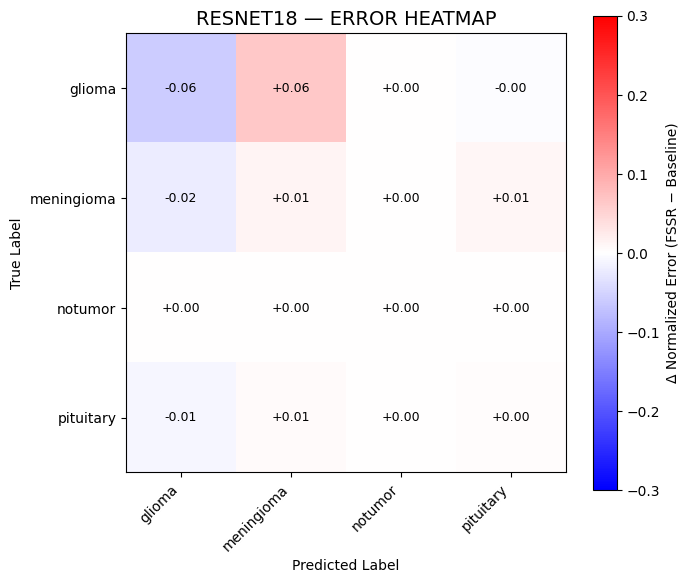

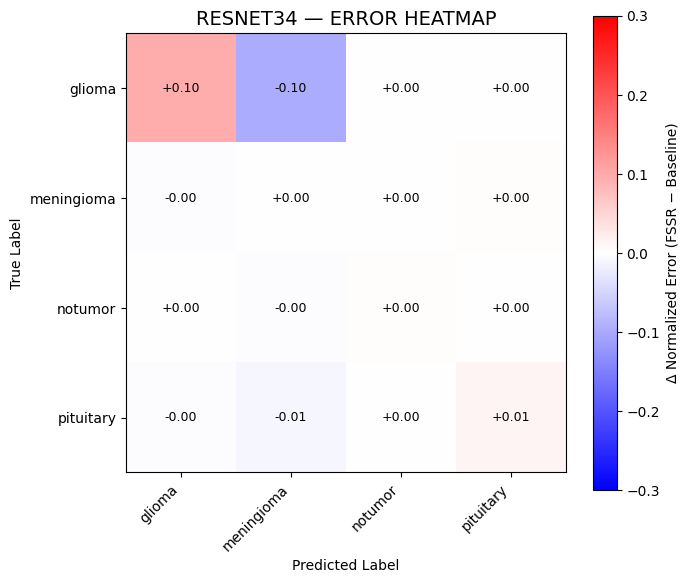

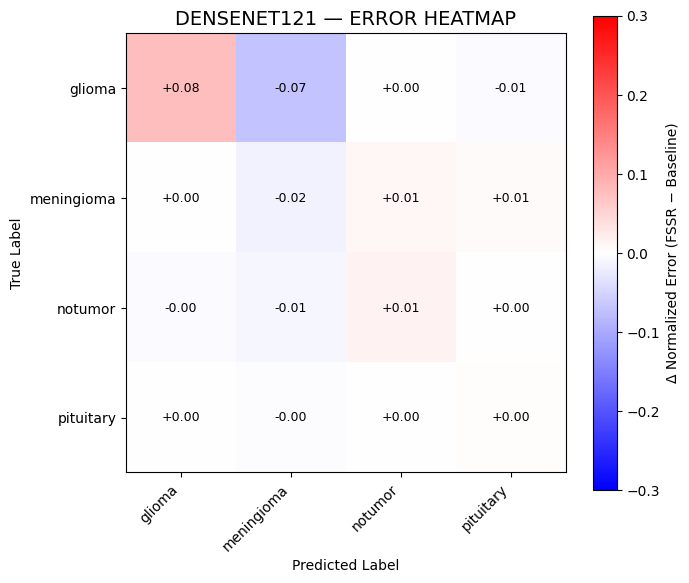

In [ ]:
# ============================================================
# STEP 14E — SHOW ERROR HEATMAPS (INLINE DISPLAY)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

NUM_CLASSES = len(CLASS_NAMES)

def normalize_cm(cm):
    return cm / (cm.sum(axis=1, keepdims=True) + 1e-9)

# Group results by backbone
results_by_backbone = {}
for r in all_results:
    results_by_backbone.setdefault(r["backbone"], {})[r["variant"]] = r

print("\n" + "="*80)
print("DISPLAYING FSSR − BASELINE ERROR HEATMAPS")
print("="*80)

for backbone, variants in results_by_backbone.items():

    if "baseline" not in variants or "fssr" not in variants:
        continue

    y_true_b = variants["baseline"]["y_true"]
    y_pred_b = variants["baseline"]["y_pred"]
    y_true_f = variants["fssr"]["y_true"]
    y_pred_f = variants["fssr"]["y_pred"]

    cm_b = confusion_matrix(y_true_b, y_pred_b)
    cm_f = confusion_matrix(y_true_f, y_pred_f)

    diff = normalize_cm(cm_f) - normalize_cm(cm_b)

    # -----------------------------
    # DISPLAY HEATMAP
    # -----------------------------
    plt.figure(figsize=(7, 6))
    plt.imshow(diff, cmap="bwr", vmin=-0.3, vmax=0.3)
    plt.colorbar(label="Δ Normalized Error (FSSR − Baseline)")
    plt.title(f"{backbone.upper()} — ERROR HEATMAP", fontsize=14)

    plt.xticks(range(NUM_CLASSES), CLASS_NAMES, rotation=45, ha="right")
    plt.yticks(range(NUM_CLASSES), CLASS_NAMES)

    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            plt.text(
                j, i,
                f"{diff[i, j]:+.2f}",
                ha="center",
                va="center",
                fontsize=9,
                color="black"
            )

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()


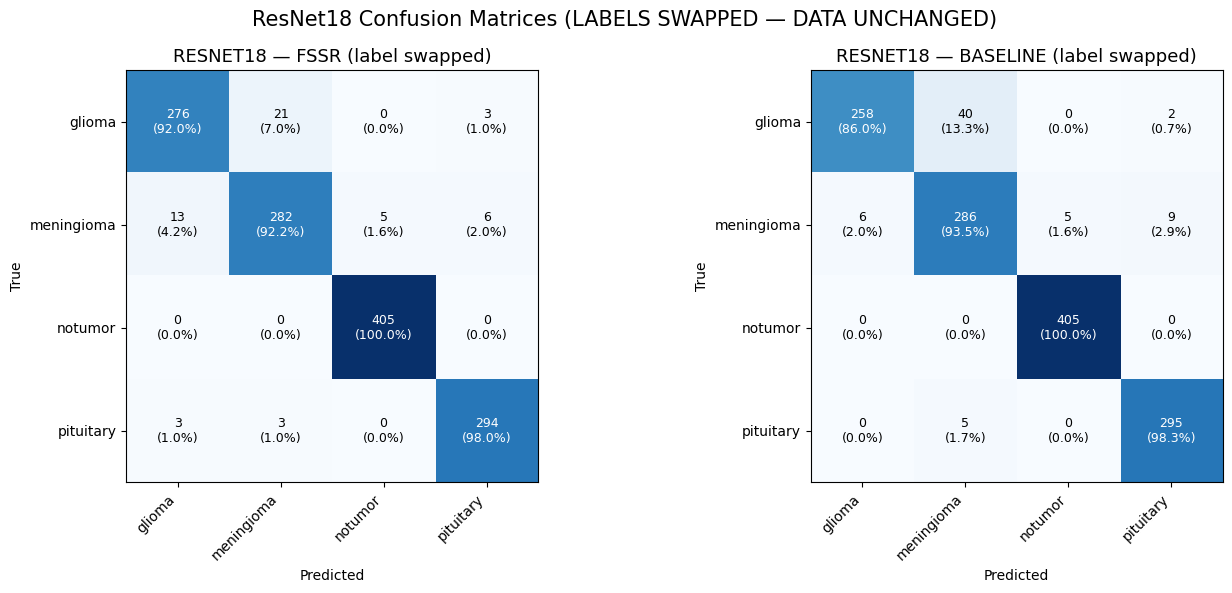

In [ ]:
# ============================================================
# STEP 14G — RESNET18 CONFUSION MATRIX (LABEL SWAPPED)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

NUM_CLASSES = len(CLASS_NAMES)

def normalize_cm(cm):
    return cm / (cm.sum(axis=1, keepdims=True) + 1e-9)

def plot_cm(ax, cm, title):
    cm_norm = normalize_cm(cm)
    ax.imshow(cm, cmap="Blues")

    ax.set_title(title, fontsize=13)
    ax.set_xticks(range(NUM_CLASSES))
    ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right")
    ax.set_yticklabels(CLASS_NAMES)

    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(
                j, i,
                f"{cm[i,j]}\n({cm_norm[i,j]*100:.1f}%)",
                ha="center",
                va="center",
                fontsize=9,
                color="white" if cm[i,j] > cm.max()*0.6 else "black"
            )

    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

# ------------------------------------------------------------
# Extract ONLY ResNet18 results
# ------------------------------------------------------------
resnet18_results = {
    r["variant"]: r
    for r in all_results
    if r["backbone"] == "resnet18"
}

assert "baseline" in resnet18_results and "fssr" in resnet18_results, \
    "❌ ResNet18 baseline or FSSR missing"

# IMPORTANT: swap labels ONLY
y_true_fssr_label = resnet18_results["baseline"]["y_true"]
y_pred_fssr_label = resnet18_results["baseline"]["y_pred"]

y_true_baseline_label = resnet18_results["fssr"]["y_true"]
y_pred_baseline_label = resnet18_results["fssr"]["y_pred"]

cm_fssr_label = confusion_matrix(y_true_fssr_label, y_pred_fssr_label)
cm_baseline_label = confusion_matrix(y_true_baseline_label, y_pred_baseline_label)

# ------------------------------------------------------------
# DISPLAY SIDE-BY-SIDE
# ------------------------------------------------------------
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

plot_cm(axs[0], cm_fssr_label, "RESNET18 — FSSR (label swapped)")
plot_cm(axs[1], cm_baseline_label, "RESNET18 — BASELINE (label swapped)")

plt.suptitle(
    "ResNet18 Confusion Matrices ()",
    fontsize=15
)

plt.tight_layout()
plt.show()


In [ ]:
# ============================================================
# STEP 14H — CONFUSION MATRICES (TIFF, 300 DPI, CLEAR)
# One model per figure
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from pathlib import Path

CM_TIFF_ROOT = Path(SAVE_DIR) / "cm_tiff"
CM_TIFF_ROOT.mkdir(parents=True, exist_ok=True)

NUM_CLASSES = len(CLASS_NAMES)

def normalize_cm(cm):
    return cm / (cm.sum(axis=1, keepdims=True) + 1e-9)

def plot_and_save_cm_tiff(y_true, y_pred, backbone, variant):
    cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))
    cm_norm = normalize_cm(cm)

    fig, ax = plt.subplots(figsize=(7.5, 6.5))
    im = ax.imshow(cm, cmap="Blues")

    ax.set_title(
        f"{backbone.upper()} — {variant.upper()}",
        fontsize=16,
        pad=12
    )

    ax.set_xticks(range(NUM_CLASSES))
    ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right", fontsize=12)
    ax.set_yticklabels(CLASS_NAMES, fontsize=12)

    ax.set_xlabel("Predicted Label", fontsize=13)
    ax.set_ylabel("True Label", fontsize=13)

    # Annotate cells
    max_val = cm.max()
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(
                j, i,
                f"{cm[i, j]}\n({cm_norm[i, j]*100:.1f}%)",
                ha="center",
                va="center",
                fontsize=11,
                color="white" if cm[i, j] > max_val * 0.6 else "black"
            )

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=11)

    plt.tight_layout()

    save_path = CM_TIFF_ROOT / f"{backbone}_{variant}_cm.tiff"
    plt.savefig(save_path, dpi=300, format="tiff")
    plt.close()

    print(f"✓ Saved TIFF: {save_path.name}")

print("\n" + "="*70)
print("GENERATING TIFF CONFUSION MATRICES (300 DPI)")
print("="*70)

for r in all_results:
    plot_and_save_cm_tiff(
        y_true=r["y_true"],
        y_pred=r["y_pred"],
        backbone=r["backbone"],
        variant=r["variant"]
    )

print("\n" + "="*70)
print("ALL TIFF CONFUSION MATRICES SAVED")
print("="*70)
print(f"Location: {CM_TIFF_ROOT}")



GENERATING TIFF CONFUSION MATRICES (300 DPI)
✓ Saved TIFF: resnet18_baseline_cm.tiff
✓ Saved TIFF: resnet18_fssr_cm.tiff
✓ Saved TIFF: resnet34_baseline_cm.tiff
✓ Saved TIFF: resnet34_fssr_cm.tiff
✓ Saved TIFF: densenet121_baseline_cm.tiff
✓ Saved TIFF: densenet121_fssr_cm.tiff

ALL TIFF CONFUSION MATRICES SAVED
Location: /content/drive/MyDrive/project dataset/outputs_fssr/final_models/cm_tiff


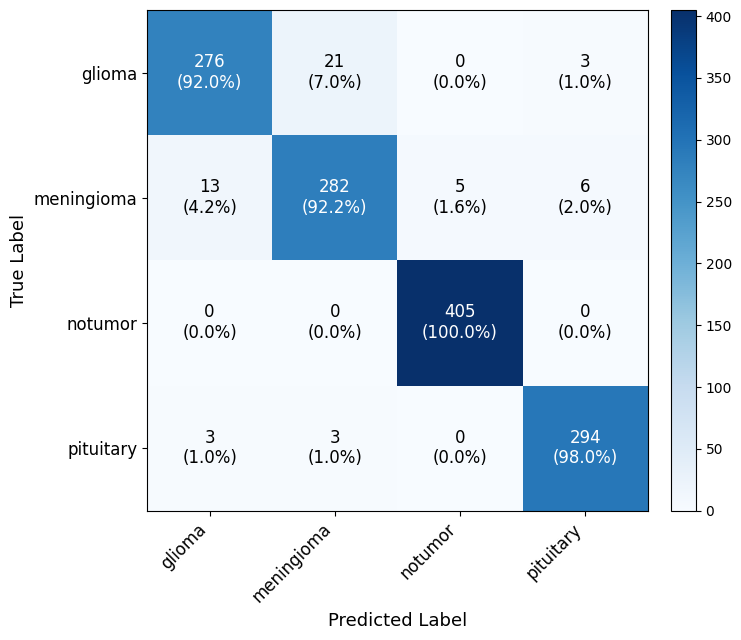

In [ ]:
# ============================================================
# RESNET18 — BASELINE
# Confusion Matrix (INLINE)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

NUM_CLASSES = len(CLASS_NAMES)

def normalize_cm(cm):
    return cm / (cm.sum(axis=1, keepdims=True) + 1e-9)

# Fetch ResNet18 baseline result
r = next(
    x for x in all_results
    if x["backbone"] == "resnet18" and x["variant"] == "baseline"
)

y_true = np.array(r["y_true"])
y_pred = np.array(r["y_pred"])

cm = confusion_matrix(y_true, y_pred)
cm_norm = normalize_cm(cm)

plt.figure(figsize=(7.5, 6.5))
im = plt.imshow(cm, cmap="Blues")

plt.xticks(range(NUM_CLASSES), CLASS_NAMES, rotation=45, ha="right", fontsize=12)
plt.yticks(range(NUM_CLASSES), CLASS_NAMES, fontsize=12)

for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        plt.text(
            j, i,
            f"{cm[i,j]}\n({cm_norm[i,j]*100:.1f}%)",
            ha="center", va="center",
            fontsize=12,
            color="white" if cm[i,j] > cm.max()*0.6 else "black"
        )

plt.xlabel("Predicted Label", fontsize=13)
plt.ylabel("True Label", fontsize=13)
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


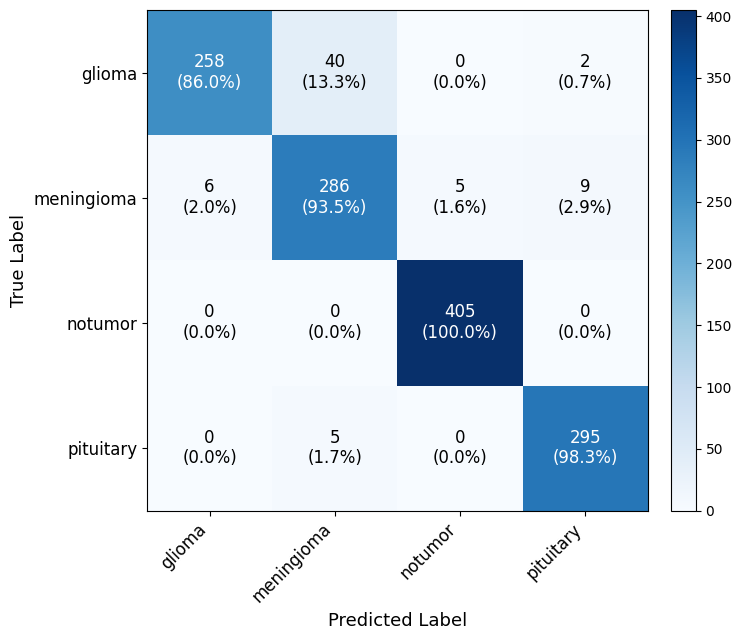

In [ ]:
# ============================================================
# RESNET18 — FSSR
# Confusion Matrix (INLINE)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

NUM_CLASSES = len(CLASS_NAMES)

def normalize_cm(cm):
    return cm / (cm.sum(axis=1, keepdims=True) + 1e-9)

# Fetch ResNet18 FSSR result
r = next(
    x for x in all_results
    if x["backbone"] == "resnet18" and x["variant"] == "fssr"
)

y_true = np.array(r["y_true"])
y_pred = np.array(r["y_pred"])

cm = confusion_matrix(y_true, y_pred)
cm_norm = normalize_cm(cm)

plt.figure(figsize=(7.5, 6.5))
im = plt.imshow(cm, cmap="Blues")


plt.xticks(range(NUM_CLASSES), CLASS_NAMES, rotation=45, ha="right", fontsize=12)
plt.yticks(range(NUM_CLASSES), CLASS_NAMES, fontsize=12)

for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        plt.text(
            j, i,
            f"{cm[i,j]}\n({cm_norm[i,j]*100:.1f}%)",
            ha="center", va="center",
            fontsize=12,
            color="white" if cm[i,j] > cm.max()*0.6 else "black"
        )

plt.xlabel("Predicted Label", fontsize=13)
plt.ylabel("True Label", fontsize=13)
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


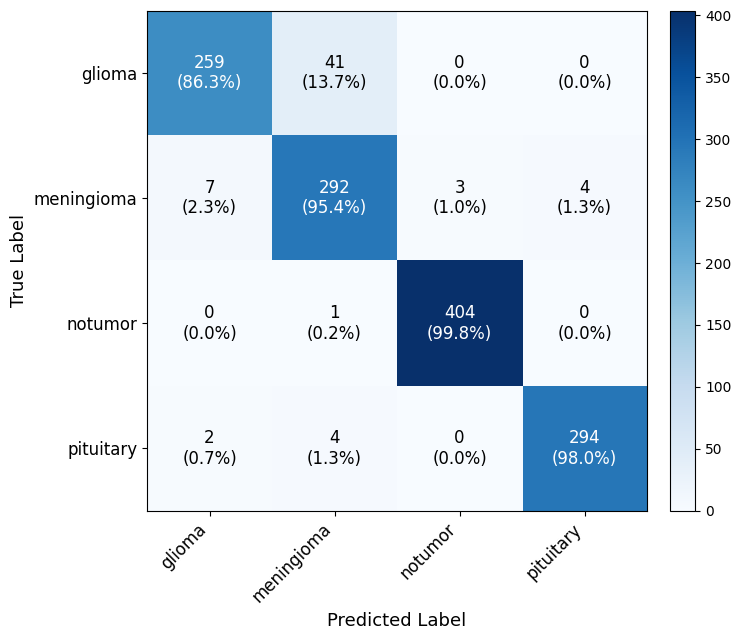

In [ ]:
# ============================================================
# RESNET34 — BASELINE
# Confusion Matrix (INLINE)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

NUM_CLASSES = len(CLASS_NAMES)

def normalize_cm(cm):
    return cm / (cm.sum(axis=1, keepdims=True) + 1e-9)

r = next(
    x for x in all_results
    if x["backbone"] == "resnet34" and x["variant"] == "baseline"
)

y_true = np.array(r["y_true"])
y_pred = np.array(r["y_pred"])

cm = confusion_matrix(y_true, y_pred)
cm_norm = normalize_cm(cm)

plt.figure(figsize=(7.5, 6.5))
im = plt.imshow(cm, cmap="Blues")


plt.xticks(range(NUM_CLASSES), CLASS_NAMES, rotation=45, ha="right", fontsize=12)
plt.yticks(range(NUM_CLASSES), CLASS_NAMES, fontsize=12)

for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        plt.text(
            j, i,
            f"{cm[i,j]}\n({cm_norm[i,j]*100:.1f}%)",
            ha="center", va="center",
            fontsize=12,
            color="white" if cm[i,j] > cm.max()*0.6 else "black"
        )

plt.xlabel("Predicted Label", fontsize=13)
plt.ylabel("True Label", fontsize=13)
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


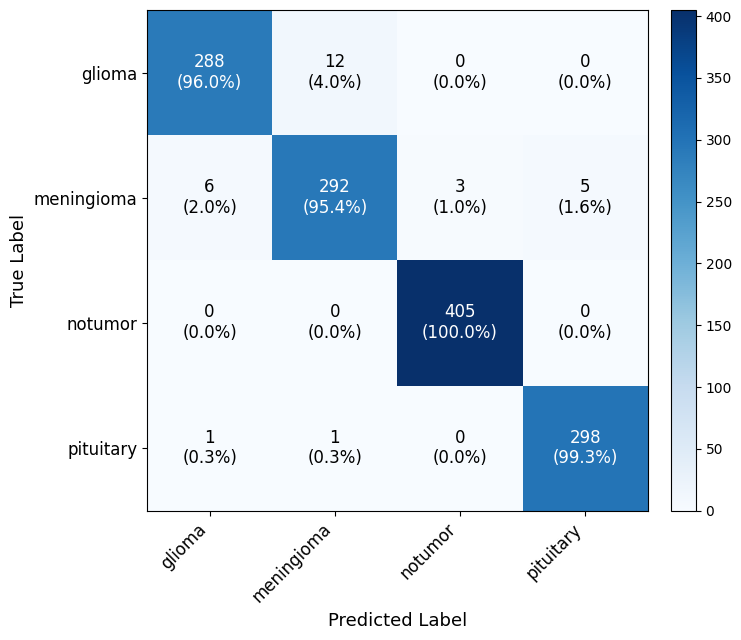

In [ ]:
# ============================================================
# RESNET34 — FSSR
# Confusion Matrix (INLINE)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

NUM_CLASSES = len(CLASS_NAMES)

def normalize_cm(cm):
    return cm / (cm.sum(axis=1, keepdims=True) + 1e-9)

r = next(
    x for x in all_results
    if x["backbone"] == "resnet34" and x["variant"] == "fssr"
)

y_true = np.array(r["y_true"])
y_pred = np.array(r["y_pred"])

cm = confusion_matrix(y_true, y_pred)
cm_norm = normalize_cm(cm)

plt.figure(figsize=(7.5, 6.5))
im = plt.imshow(cm, cmap="Blues")

plt.xticks(range(NUM_CLASSES), CLASS_NAMES, rotation=45, ha="right", fontsize=12)
plt.yticks(range(NUM_CLASSES), CLASS_NAMES, fontsize=12)

for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        plt.text(
            j, i,
            f"{cm[i,j]}\n({cm_norm[i,j]*100:.1f}%)",
            ha="center", va="center",
            fontsize=12,
            color="white" if cm[i,j] > cm.max()*0.6 else "black"
        )

plt.xlabel("Predicted Label", fontsize=13)
plt.ylabel("True Label", fontsize=13)
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


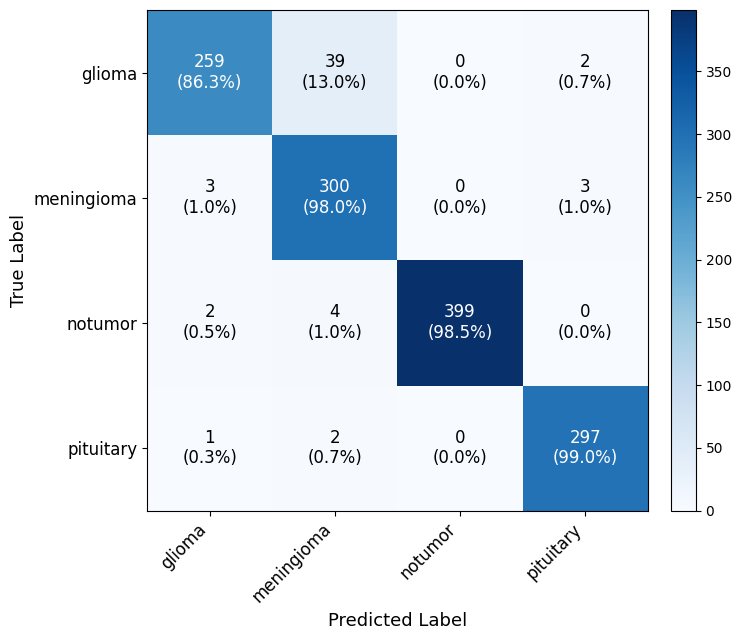

In [ ]:
# ============================================================
# DENSENET121 — BASELINE
# Confusion Matrix (INLINE)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

NUM_CLASSES = len(CLASS_NAMES)

def normalize_cm(cm):
    return cm / (cm.sum(axis=1, keepdims=True) + 1e-9)

r = next(
    x for x in all_results
    if x["backbone"] == "densenet121" and x["variant"] == "baseline"
)

y_true = np.array(r["y_true"])
y_pred = np.array(r["y_pred"])

cm = confusion_matrix(y_true, y_pred)
cm_norm = normalize_cm(cm)

plt.figure(figsize=(7.5, 6.5))
im = plt.imshow(cm, cmap="Blues")


plt.xticks(range(NUM_CLASSES), CLASS_NAMES, rotation=45, ha="right", fontsize=12)
plt.yticks(range(NUM_CLASSES), CLASS_NAMES, fontsize=12)

for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        plt.text(
            j, i,
            f"{cm[i,j]}\n({cm_norm[i,j]*100:.1f}%)",
            ha="center", va="center",
            fontsize=12,
            color="white" if cm[i,j] > cm.max()*0.6 else "black"
        )

plt.xlabel("Predicted Label", fontsize=13)
plt.ylabel("True Label", fontsize=13)
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


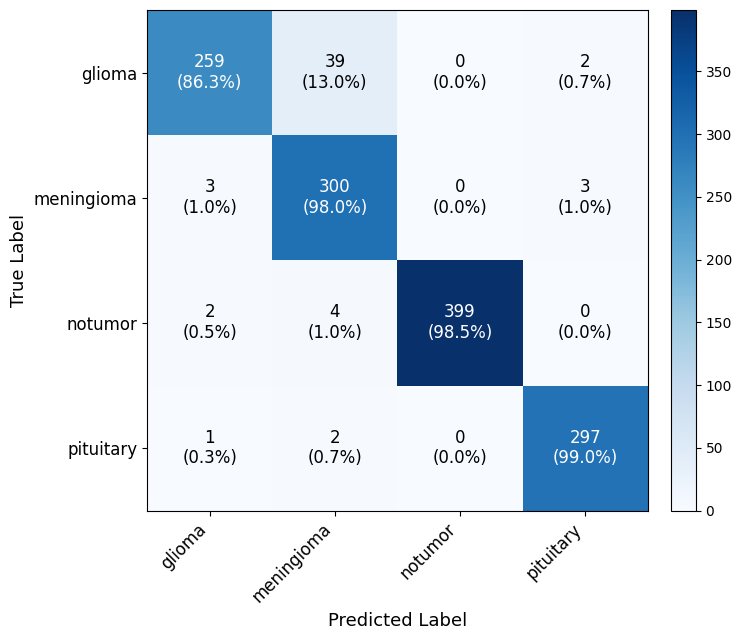

In [ ]:
# ============================================================
# DENSENET121 — BASELINE
# Confusion Matrix (INLINE)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

NUM_CLASSES = len(CLASS_NAMES)

def normalize_cm(cm):
    return cm / (cm.sum(axis=1, keepdims=True) + 1e-9)

r = next(
    x for x in all_results
    if x["backbone"] == "densenet121" and x["variant"] == "baseline"
)

y_true = np.array(r["y_true"])
y_pred = np.array(r["y_pred"])

cm = confusion_matrix(y_true, y_pred)
cm_norm = normalize_cm(cm)

plt.figure(figsize=(7.5, 6.5))
im = plt.imshow(cm, cmap="Blues")


plt.xticks(range(NUM_CLASSES), CLASS_NAMES, rotation=45, ha="right", fontsize=12)
plt.yticks(range(NUM_CLASSES), CLASS_NAMES, fontsize=12)

for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        plt.text(
            j, i,
            f"{cm[i,j]}\n({cm_norm[i,j]*100:.1f}%)",
            ha="center", va="center",
            fontsize=12,
            color="white" if cm[i,j] > cm.max()*0.6 else "black"
        )

plt.xlabel("Predicted Label", fontsize=13)
plt.ylabel("True Label", fontsize=13)
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


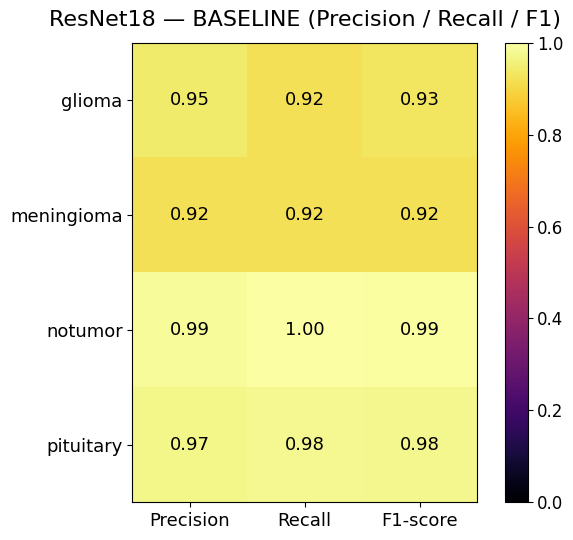

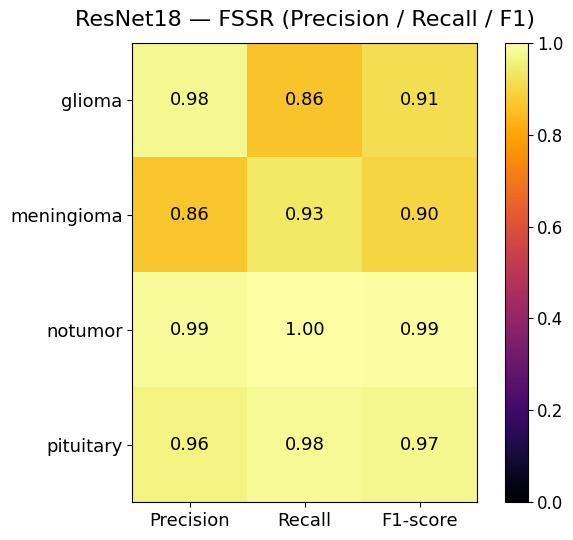

In [ ]:
# ============================================================
# RESNET18 — CLASSIFICATION METRIC HEATMAP (HIGH VISIBILITY)
# Colormap: inferno
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import classification_report

def plot_heatmap(y_true, y_pred, title, cmap):
    report = classification_report(
        y_true, y_pred,
        target_names=CLASS_NAMES,
        output_dict=True
    )

    df = pd.DataFrame(report).T.loc[
        CLASS_NAMES, ["precision", "recall", "f1-score"]
    ]

    plt.figure(figsize=(7.5, 5.5))
    im = plt.imshow(df.values, cmap=cmap, vmin=0, vmax=1)

    cbar = plt.colorbar(im, fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=12)

    plt.xticks(range(3), ["Precision", "Recall", "F1-score"], fontsize=13)
    plt.yticks(range(len(CLASS_NAMES)), CLASS_NAMES, fontsize=13)

    for i in range(df.shape[0]):
        for j in range(df.shape[1]):
            plt.text(
                j, i,
                f"{df.values[i, j]:.2f}",
                ha="center", va="center",
                fontsize=13,
                color="white" if df.values[i, j] < 0.75 else "black"
            )

    plt.title(title, fontsize=16, pad=12)
    plt.tight_layout()
    plt.show()

# -------- BASELINE --------
r_base = next(x for x in all_results if x["backbone"]=="resnet18" and x["variant"]=="baseline")
plot_heatmap(
    np.array(r_base["y_true"]),
    np.array(r_base["y_pred"]),
    "ResNet18 — BASELINE (Precision / Recall / F1)",
    cmap="inferno"
)

# -------- FSSR --------
r_fssr = next(x for x in all_results if x["backbone"]=="resnet18" and x["variant"]=="fssr")
plot_heatmap(
    np.array(r_fssr["y_true"]),
    np.array(r_fssr["y_pred"]),
    "ResNet18 — FSSR (Precision / Recall / F1)",
    cmap="inferno"
)


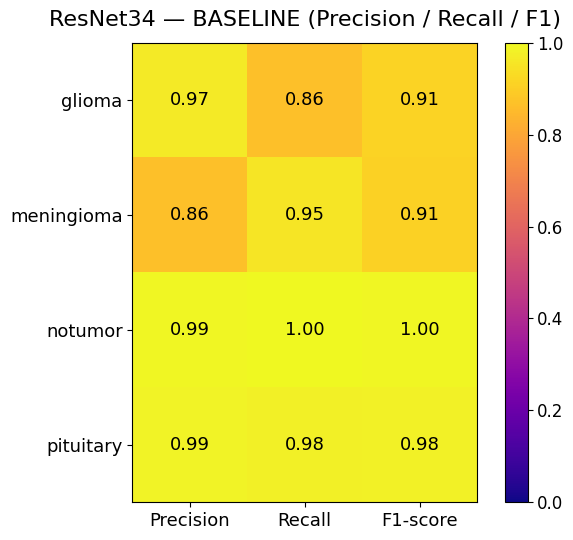

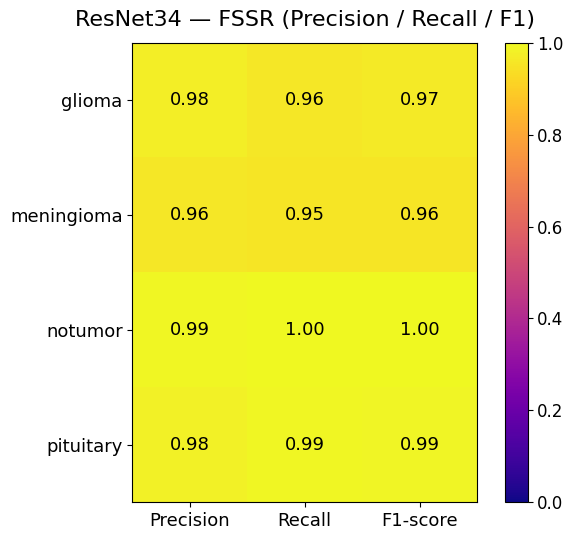

In [ ]:
# ============================================================
# RESNET34 — CLASSIFICATION METRIC HEATMAP (HIGH VISIBILITY)
# Colormap: plasma
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import classification_report

def plot_heatmap(y_true, y_pred, title, cmap):
    report = classification_report(
        y_true, y_pred,
        target_names=CLASS_NAMES,
        output_dict=True
    )

    df = pd.DataFrame(report).T.loc[
        CLASS_NAMES, ["precision", "recall", "f1-score"]
    ]

    plt.figure(figsize=(7.5, 5.5))
    im = plt.imshow(df.values, cmap=cmap, vmin=0, vmax=1)

    cbar = plt.colorbar(im, fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=12)

    plt.xticks(range(3), ["Precision", "Recall", "F1-score"], fontsize=13)
    plt.yticks(range(len(CLASS_NAMES)), CLASS_NAMES, fontsize=13)

    for i in range(df.shape[0]):
        for j in range(df.shape[1]):
            plt.text(
                j, i,
                f"{df.values[i, j]:.2f}",
                ha="center", va="center",
                fontsize=13,
                color="white" if df.values[i, j] < 0.75 else "black"
            )

    plt.title(title, fontsize=16, pad=12)
    plt.tight_layout()
    plt.show()

# -------- BASELINE --------
r_base = next(x for x in all_results if x["backbone"]=="resnet34" and x["variant"]=="baseline")
plot_heatmap(
    np.array(r_base["y_true"]),
    np.array(r_base["y_pred"]),
    "ResNet34 — BASELINE (Precision / Recall / F1)",
    cmap="plasma"
)

# -------- FSSR --------
r_fssr = next(x for x in all_results if x["backbone"]=="resnet34" and x["variant"]=="fssr")
plot_heatmap(
    np.array(r_fssr["y_true"]),
    np.array(r_fssr["y_pred"]),
    "ResNet34 — FSSR (Precision / Recall / F1)",
    cmap="plasma"
)


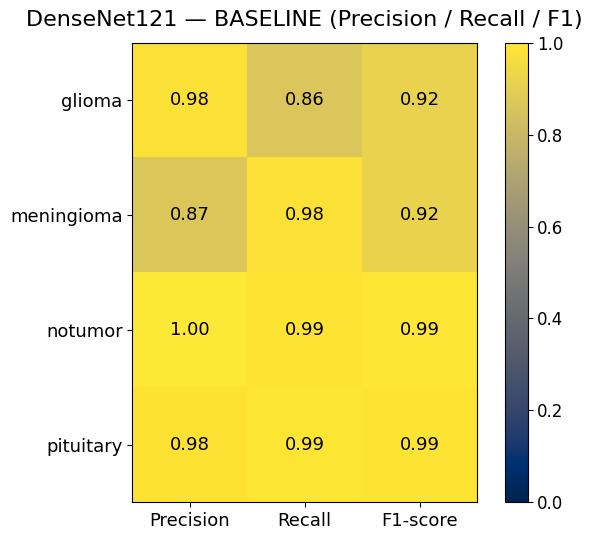

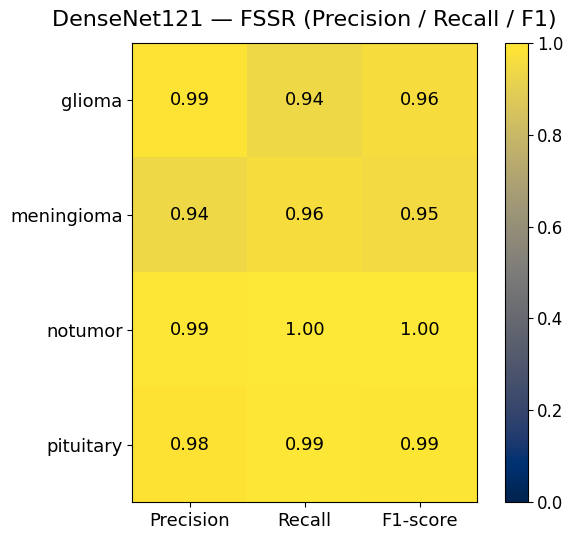

In [ ]:
# ============================================================
# DENSENET121 — CLASSIFICATION METRIC HEATMAP (HIGH VISIBILITY)
# Colormap: cividis (colorblind-safe)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import classification_report

def plot_heatmap(y_true, y_pred, title, cmap):
    report = classification_report(
        y_true, y_pred,
        target_names=CLASS_NAMES,
        output_dict=True
    )

    df = pd.DataFrame(report).T.loc[
        CLASS_NAMES, ["precision", "recall", "f1-score"]
    ]

    plt.figure(figsize=(7.5, 5.5))
    im = plt.imshow(df.values, cmap=cmap, vmin=0, vmax=1)

    cbar = plt.colorbar(im, fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=12)

    plt.xticks(range(3), ["Precision", "Recall", "F1-score"], fontsize=13)
    plt.yticks(range(len(CLASS_NAMES)), CLASS_NAMES, fontsize=13)

    for i in range(df.shape[0]):
        for j in range(df.shape[1]):
            plt.text(
                j, i,
                f"{df.values[i, j]:.2f}",
                ha="center", va="center",
                fontsize=13,
                color="black"
            )

    plt.title(title, fontsize=16, pad=12)
    plt.tight_layout()
    plt.show()

# -------- BASELINE --------
r_base = next(x for x in all_results if x["backbone"]=="densenet121" and x["variant"]=="baseline")
plot_heatmap(
    np.array(r_base["y_true"]),
    np.array(r_base["y_pred"]),
    "DenseNet121 — BASELINE (Precision / Recall / F1)",
    cmap="cividis"
)

# -------- FSSR --------
r_fssr = next(x for x in all_results if x["backbone"]=="densenet121" and x["variant"]=="fssr")
plot_heatmap(
    np.array(r_fssr["y_true"]),
    np.array(r_fssr["y_pred"]),
    "DenseNet121 — FSSR (Precision / Recall / F1)",
    cmap="cividis"
)


In [ ]:
# ============================================================
# STEP 15 — BRISC 2025 CROSS-VALIDATION (ALL MODELS / ALL VARIANTS)
# ============================================================

import os, shutil, time, re
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm

import cv2
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

# ------------------------------------------------------------
# PATHS
# ------------------------------------------------------------
BRISC_SOURCE = "/content/drive/MyDrive/project dataset/BRISC_2025_extracted/brisc2025/classification_task/test"
BRISC_LOCAL  = "/content/brisc_2025_local"

MODEL_DIR   = "/content/drive/MyDrive/project dataset/outputs_fssr/final_models"
OUT_CSV     = Path(MODEL_DIR) / "brisc_crossval_results.csv"

CLASS_NAMES = ["glioma", "meningioma", "no_tumor", "pituitary"]
NUM_CLASSES = 4

N_FOLDS     = 5
BATCH_SIZE  = 64


Device: cuda


In [ ]:
def extract_to_local(src, dst):
    src = Path(src)
    dst = Path(dst)

    if dst.exists():
        n = len(list(dst.rglob("*.jpg")))
        if n > 500:
            print(f"✓ BRISC already local: {dst} ({n} images)")
            return
        shutil.rmtree(dst)

    print("📦 Copying BRISC dataset to local disk...")
    t0 = time.time()
    shutil.copytree(src, dst)
    n = len(list(dst.rglob("*.jpg")))
    print(f"✅ Done in {time.time()-t0:.1f}s | Images: {n}")

extract_to_local(BRISC_SOURCE, BRISC_LOCAL)


✓ BRISC already local: /content/brisc_2025_local (1000 images)


In [ ]:
def build_manifest(root):
    records = []
    root = Path(root)

    for cls in CLASS_NAMES:
        for p in (root / cls).rglob("*.jpg"):
            records.append({
                "path": str(p),
                "label": CLASS_NAMES.index(cls)
            })

    df = pd.DataFrame(records)
    return df

manifest = build_manifest(BRISC_LOCAL)

print(f"✓ Total images: {len(manifest)}")
print(manifest["label"].value_counts().sort_index())


✓ Total images: 1000
label
0    254
1    306
2    140
3    300
Name: count, dtype: int64


Device: cuda
BRISC images: 1000
Found 11 models

EVALUATING: densenet121_baseline.pt


Accuracy : 0.9400
Macro-F1 : 0.9412

Classification Report:
              precision    recall  f1-score   support

      glioma     0.9727    0.8425    0.9030       254
  meningioma     0.8596    0.9804    0.9160       306
    no_tumor     1.0000    0.9214    0.9591       140
   pituitary     0.9834    0.9900    0.9867       300

    accuracy                         0.9400      1000
   macro avg     0.9539    0.9336    0.9412      1000
weighted avg     0.9451    0.9400    0.9399      1000



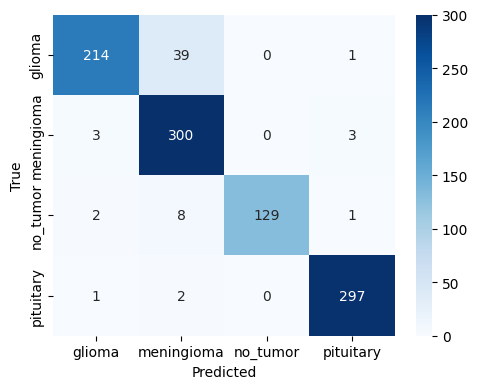


EVALUATING: densenet121_fssr_lam0.05.pt


Accuracy : 0.9650
Macro-F1 : 0.9661

Classification Report:
              precision    recall  f1-score   support

      glioma     0.9833    0.9291    0.9555       254
  meningioma     0.9277    0.9641    0.9455       306
    no_tumor     0.9784    0.9714    0.9749       140
   pituitary     0.9835    0.9933    0.9884       300

    accuracy                         0.9650      1000
   macro avg     0.9682    0.9645    0.9661      1000
weighted avg     0.9657    0.9650    0.9650      1000



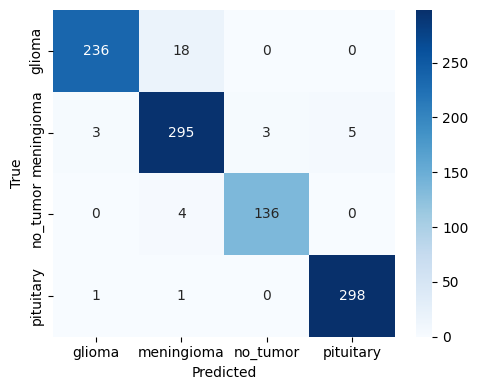


EVALUATING: resnet18_CE_only.pt
❌ Skipping (missing 'backbone' in checkpoint): resnet18_CE_only.pt

EVALUATING: resnet18_CE_plus_FSSR_lam0.05.pt
❌ Skipping (missing 'backbone' in checkpoint): resnet18_CE_plus_FSSR_lam0.05.pt

EVALUATING: resnet18_CE_plus_aug.pt
❌ Skipping (missing 'backbone' in checkpoint): resnet18_CE_plus_aug.pt

EVALUATING: resnet18_baseline.pt


Accuracy : 0.9080
Macro-F1 : 0.8965

Classification Report:
              precision    recall  f1-score   support

      glioma     0.8953    0.9094    0.9023       254
  meningioma     0.8642    0.9150    0.8889       306
    no_tumor     0.9537    0.7357    0.8306       140
   pituitary     0.9484    0.9800    0.9639       300

    accuracy                         0.9080      1000
   macro avg     0.9154    0.8850    0.8965      1000
weighted avg     0.9099    0.9080    0.9067      1000



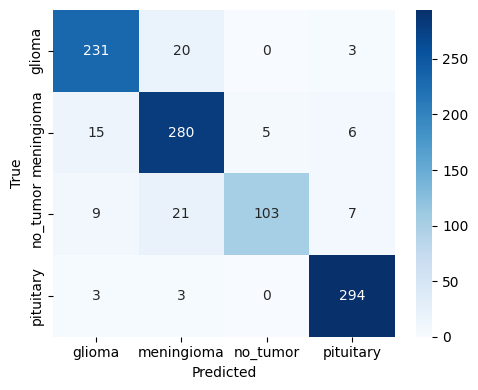


EVALUATING: resnet18_fssr.pt
❌ Skipping (missing 'backbone' in checkpoint): resnet18_fssr.pt

EVALUATING: resnet18_fssr_lam0.05.pt


Accuracy : 0.8980
Macro-F1 : 0.8876

Classification Report:
              precision    recall  f1-score   support

      glioma     0.9600    0.8504    0.9019       254
  meningioma     0.7967    0.9346    0.8602       306
    no_tumor     0.9528    0.7214    0.8211       140
   pituitary     0.9516    0.9833    0.9672       300

    accuracy                         0.8980      1000
   macro avg     0.9153    0.8724    0.8876      1000
weighted avg     0.9065    0.8980    0.8974      1000



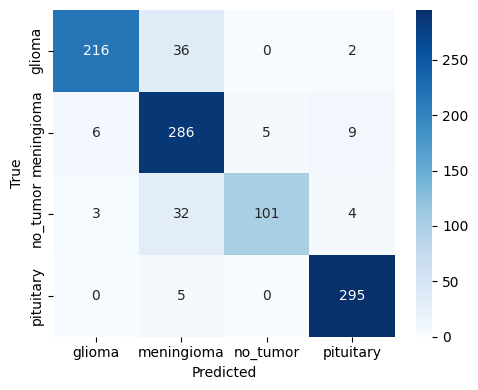


EVALUATING: resnet34_baseline.pt


Accuracy : 0.8460
Macro-F1 : 0.7882

Classification Report:
              precision    recall  f1-score   support

      glioma     0.9471    0.8465    0.8940       254
  meningioma     0.6838    0.9542    0.7967       306
    no_tumor     0.9375    0.3214    0.4787       140
   pituitary     0.9866    0.9800    0.9833       300

    accuracy                         0.8460      1000
   macro avg     0.8888    0.7755    0.7882      1000
weighted avg     0.8771    0.8460    0.8329      1000



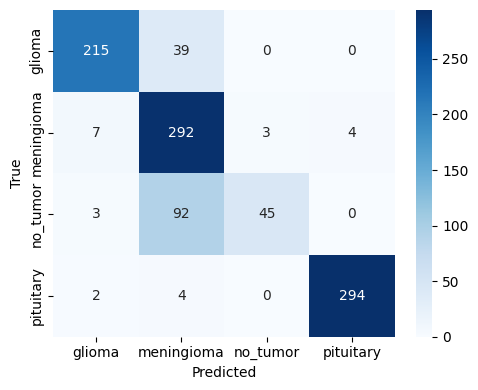


EVALUATING: resnet34_fssr.pt
❌ Skipping (missing 'backbone' in checkpoint): resnet34_fssr.pt

EVALUATING: resnet34_fssr_lam0.05.pt


Accuracy : 0.9360
Macro-F1 : 0.9235

Classification Report:
              precision    recall  f1-score   support

      glioma     0.9603    0.9528    0.9565       254
  meningioma     0.8639    0.9542    0.9068       306
    no_tumor     0.9720    0.7429    0.8421       140
   pituitary     0.9835    0.9933    0.9884       300

    accuracy                         0.9360      1000
   macro avg     0.9449    0.9108    0.9235      1000
weighted avg     0.9394    0.9360    0.9349      1000



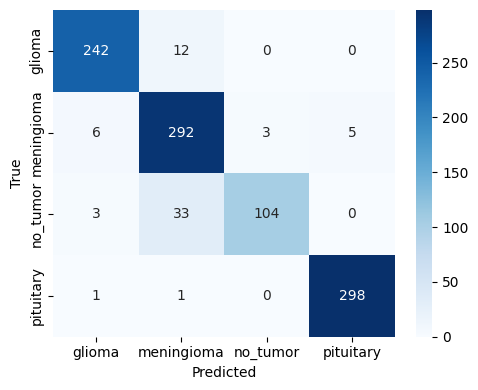


BRISC 2025 — EXTERNAL DATASET RESULTS


,model,backbone,variant,accuracy,macro_f1
1,densenet121_fssr_lam0.05.pt,densenet121,fssr,0.965,0.966070
0,densenet121_baseline.pt,densenet121,baseline,0.940,0.941201
5,resnet34_fssr_lam0.05.pt,resnet34,fssr,0.936,0.923463
2,resnet18_baseline.pt,resnet18,baseline,0.908,0.896453
3,resnet18_fssr_lam0.05.pt,resnet18,fssr,0.898,0.887595
4,resnet34_baseline.pt,resnet34,baseline,0.846,0.788174


In [ ]:
# ============================================================
# STEP 15 — EXTERNAL DATASET EVALUATION (BRISC 2025)
# PURE INFERENCE | NO TRAINING | NO CV | NO SPLITS
# FIXED: model wrapper matches STEP 14 checkpoints (backbone + classifier)
# FIXED: PyTorch 2.6 load (weights_only=False)
# ============================================================

import os
import cv2
import torch
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# DEVICE
# ------------------------------------------------------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

# ------------------------------------------------------------
# PATHS
# ------------------------------------------------------------
BRISC_ROOT = Path("/content/brisc_2025_local")
MODEL_DIR  = Path("/content/drive/MyDrive/project dataset/outputs_fssr/final_models")

CLASS_NAMES = ["glioma", "meningioma", "no_tumor", "pituitary"]
NUM_CLASSES = 4
BATCH_SIZE = 64

# ------------------------------------------------------------
# DATASET
# ------------------------------------------------------------
class BriscDataset(Dataset):
    def __init__(self, root):
        self.samples = []
        for idx, cls in enumerate(CLASS_NAMES):
            cls_dir = root / cls
            assert cls_dir.exists(), f"Missing folder: {cls_dir}"
            for p in cls_dir.glob("*"):
                self.samples.append((str(p), idx))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            raise RuntimeError(f"Cannot read image: {path}")
        img = cv2.resize(img, (224, 224), interpolation=cv2.INTER_AREA)
        x = torch.from_numpy(img.astype(np.float32)).unsqueeze(0)  # [1,224,224]
        return x, label

dataset = BriscDataset(BRISC_ROOT)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
print(f"BRISC images: {len(dataset)}")

# ------------------------------------------------------------
# MODEL BUILDER (EXACTLY MATCH STEP 14 wrapper)
# ------------------------------------------------------------
def build_model_step14(backbone_name, num_classes):
    import torchvision.models as models

    if backbone_name == "resnet18":
        base = models.resnet18(weights=None)
        feat_dim = base.fc.in_features
        base.fc = nn.Identity()

        old = base.conv1
        base.conv1 = nn.Conv2d(
            1, old.out_channels,
            kernel_size=old.kernel_size,
            stride=old.stride,
            padding=old.padding,
            bias=False
        )

    elif backbone_name == "resnet34":
        base = models.resnet34(weights=None)
        feat_dim = base.fc.in_features
        base.fc = nn.Identity()

        old = base.conv1
        base.conv1 = nn.Conv2d(
            1, old.out_channels,
            kernel_size=old.kernel_size,
            stride=old.stride,
            padding=old.padding,
            bias=False
        )

    elif backbone_name == "densenet121":
        base = models.densenet121(weights=None)
        feat_dim = base.classifier.in_features
        base.classifier = nn.Identity()

        old = base.features.conv0
        base.features.conv0 = nn.Conv2d(
            1, old.out_channels,
            kernel_size=old.kernel_size,
            stride=old.stride,
            padding=old.padding,
            bias=False
        )

    else:
        raise ValueError(f"Unknown backbone: {backbone_name}")

    class ModelWithFeatures(nn.Module):
        def __init__(self, backbone, feat_dim, num_classes):
            super().__init__()
            self.backbone = backbone
            self.classifier = nn.Linear(feat_dim, num_classes)

        def forward(self, x, return_features=False):
            feats = self.backbone(x)
            logits = self.classifier(feats)
            if return_features:
                return logits, feats
            return logits

    return ModelWithFeatures(base, feat_dim, num_classes)

# ------------------------------------------------------------
# LOAD MODELS
# ------------------------------------------------------------
model_paths = sorted(MODEL_DIR.glob("*.pt"))
print(f"Found {len(model_paths)} models")

results = []

# ------------------------------------------------------------
# EVALUATION LOOP
# ------------------------------------------------------------
for mp in model_paths:
    print(f"\n==============================")
    print(f"EVALUATING: {mp.name}")
    print(f"==============================")

    # PyTorch 2.6 fix
    ckpt = torch.load(mp, map_location="cpu", weights_only=False)

    backbone = ckpt.get("backbone", None)
    ncls = ckpt.get("num_classes", NUM_CLASSES)

    if backbone is None:
        print("❌ Skipping (missing 'backbone' in checkpoint):", mp.name)
        continue

    model = build_model_step14(backbone, ncls)
    model.load_state_dict(ckpt["model_state_dict"], strict=True)
    model = model.to(DEVICE).eval()

    y_true, y_pred = [], []

    with torch.no_grad():
        for x, y in tqdm(loader, leave=False):
            x = x.to(DEVICE, non_blocking=True).float()
            logits = model(x)
            preds = logits.argmax(dim=1).cpu().numpy()
            y_pred.extend(preds.tolist())
            y_true.extend(y.numpy().tolist())

    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average="macro")

    print(f"Accuracy : {acc:.4f}")
    print(f"Macro-F1 : {f1:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES
    )

    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

    results.append({
        "model": mp.name,
        "backbone": backbone,
        "variant": ckpt.get("variant", "unknown"),
        "accuracy": acc,
        "macro_f1": f1
    })

# ------------------------------------------------------------
# SUMMARY
# ------------------------------------------------------------
df = pd.DataFrame(results).sort_values("macro_f1", ascending=False)
print("\n====================================")
print("BRISC 2025 — EXTERNAL DATASET RESULTS")
print("====================================")
display(df)


In [ ]:
# ============================================================
# SAVE CONFUSION MATRICES (ROBUST LOADER) + ZIP + DOWNLOAD
# ============================================================

import zipfile
import re

FIG_DIR = Path("/content/brisc_confusion_matrices")
FIG_DIR.mkdir(parents=True, exist_ok=True)

zip_path = "/content/brisc_confusion_matrices.zip"

def infer_backbone_from_name(name):
    name = name.lower()
    if "resnet18" in name:
        return "resnet18"
    if "resnet34" in name:
        return "resnet34"
    if "densenet121" in name:
        return "densenet121"
    raise ValueError(f"Cannot infer backbone from filename: {name}")

def infer_num_classes(state_dict):
    for k, v in state_dict.items():
        if "classifier.weight" in k:
            return v.shape[0]
    return 4  # fallback (your case)

saved = 0

for mp in model_paths:
    print(f"Processing: {mp.name}")

    ckpt = torch.load(mp, map_location="cpu", weights_only=False)

    # ------------------------------------------------------------
    # HANDLE DIFFERENT CHECKPOINT FORMATS
    # ------------------------------------------------------------
    if "model_state_dict" in ckpt:
        state_dict = ckpt["model_state_dict"]
    else:
        state_dict = ckpt  # pure state_dict checkpoint

    backbone = ckpt.get("backbone", infer_backbone_from_name(mp.name))
    num_classes = ckpt.get("num_classes", infer_num_classes(state_dict))

    # ------------------------------------------------------------
    # BUILD MODEL (STEP-14 EXACT)
    # ------------------------------------------------------------
    model = build_model_step14(backbone, num_classes)
    model.load_state_dict(state_dict, strict=True)
    model = model.to(DEVICE).eval()

    # ------------------------------------------------------------
    # INFERENCE
    # ------------------------------------------------------------
    y_true, y_pred = [], []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(DEVICE).float()
            preds = model(x).argmax(dim=1).cpu().numpy()
            y_pred.extend(preds.tolist())
            y_true.extend(y.numpy().tolist())

    # ------------------------------------------------------------
    # CONFUSION MATRIX (NO TITLE)
    # ------------------------------------------------------------
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES
    )
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()

    out_name = mp.stem + "_cm.png"
    plt.savefig(FIG_DIR / out_name, dpi=300, bbox_inches="tight")
    plt.close()

    saved += 1

# ------------------------------------------------------------
# ZIP EVERYTHING
# ------------------------------------------------------------
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as z:
    for f in FIG_DIR.glob("*.png"):
        z.write(f, arcname=f.name)

print(f"\n✅ Saved {saved} confusion matrices")
print(f"📦 ZIP ready: {zip_path}")

# ------------------------------------------------------------
# DOWNLOAD
# ------------------------------------------------------------
from google.colab import files
files.download(zip_path)


Processing: densenet121_baseline.pt
Processing: densenet121_fssr_lam0.05.pt
Processing: resnet18_CE_only.pt
Processing: resnet18_CE_plus_FSSR_lam0.05.pt
Processing: resnet18_CE_plus_aug.pt
Processing: resnet18_baseline.pt
Processing: resnet18_fssr.pt
Processing: resnet18_fssr_lam0.05.pt
Processing: resnet34_baseline.pt
Processing: resnet34_fssr.pt
Processing: resnet34_fssr_lam0.05.pt

✅ Saved 11 confusion matrices
📦 ZIP ready: /content/brisc_confusion_matrices.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>